In [9]:
import math

class Value:
	data: float
	op: str
	grad: float
	prev: set['Value']

	def __init__(self, data: float, prev = (), op = ''):
		self.data = data
		self.prev = set(prev)
		self.grad = 0
		self.op=op
		self._backwards = lambda: None


	def __repr__(self):
		return f"Value: {self.data} (grad: {self.grad}, op: {self.op})"
	
	def __add__(self, o: 'Value') -> 'Value':
		val = self.data + o.data
		result = Value(val, prev=(self, o), op='+')
		def _backwards():
			self.grad += 1 * result.grad
			o.grad += 1 * result.grad
		result._backwards = _backwards
		return result
	
	def __sub__(self, o: 'Value') -> 'Value':
		val = self.data - o.data
		result = Value(val, prev=(self, o), op='-')
		def _backwards():
			self.grad += 1 * result.grad
			o.grad += -1 * result.grad
		result._backwards = _backwards
		return result
	
	def __mul__(self, o: 'Value') -> 'Value':
		val = self.data * o.data
		result = Value(val, prev=(self, o), op='*')
		def _backwards():
			self.grad += o.data * result.grad
			o.grad += self.data * result.grad
		result._backwards = _backwards
		return result
	
	def __pow__(self, o: int) -> 'Value':
		val = self.data ** o
		result = Value(val, prev=(self,), op=f"**{o}")
		def _backwards():
			self.grad += result.grad * o * self.data**(o-1)
		result._backwards = _backwards
		return result
	
	def activate(self) -> 'Value':
		val = math.tanh(self.data)
		result = Value(val, prev=(self,), op=f"tanh()")
		def _backwards():
			self.grad += result.grad * (1 - val * val)

		result._backwards = _backwards
		return result
	
	def backwards(self) -> None:
		topsort = []
		visited = set()
		def build_top(v: Value):
			if v not in visited:
				visited.add(v)
				for child in v.prev:
					build_top(child)
				topsort.append(v)
		build_top(self)
		self.grad = 1
		for v in reversed(topsort):
			v._backwards()


Value(2).backwards()





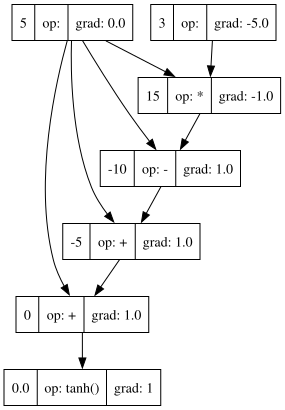

In [10]:
from graphviz import Digraph

def graph_value(v: Value) -> Digraph:
	graph = Digraph()
	def value_id(_v: Value) -> str:
		return str(id(_v))

	visited = set()
	nodes = [v]
	index = 0
	while index<len(nodes):
		at = nodes[index]
		graph.node(value_id(at), f"{at.data} | op: {at.op} | grad: {at.grad}", shape="record")
		for cameFrom in at.prev:
			graph.edge(value_id(cameFrom), value_id(at))
			if cameFrom in visited:
				continue
			visited.add(cameFrom)
			nodes.append(cameFrom)
		
		index+=1;
	return graph


a = Value(5)
b = Value(3)
c = a - b * a + a + a
d = c.activate()
d.backwards()

graph_value(d)


In [11]:
import random

class Neuron:
	def __init__(self, nin, nonlin = True):
		self.b=Value(0)
		self.w=[Value(random.uniform(-1, 1)) for _ in range(nin)]
		self.nonlin = nonlin

	def __call__(self, x):
		preact = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
		if self.nonlin:
			return preact.activate()
		return preact

	def parameters(self):
		return self.w+[self.b]
	
	def __repr__(self):
		return f"{'Sigmoid' if self.nonlin else 'Linear'}Neuron({len(self.w)})"
	
class Layer:
	def __init__(self, nin, nout, nonlin = True):
		self.neurons = [Neuron(nin, nonlin=nonlin) for _ in range(nout)]

	def __call__(self, x):
		outputs = [n(x) for n in self.neurons]
		return outputs
	
	def parameters(self):
		return [p for n in self.neurons for p in n.parameters()]
	
	def __repr__(self):
		return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"
	
	def zerograd(self):
		for p in self.parameters():
			p.grad=0
	
class MLP:
	def __init__(self, sizes: list[int]):
		self.layers = [Layer(sizes[i], sizes[i+1], nonlin = i<len(sizes)-2) for i in range(len(sizes)-1)]

	def __repr__(self):
		return f"MLP of [{', '.join(str(l) for l in self.layers)}]"
	
	def __call__(self, x: list[Value]) -> list[Value]:
		for l in self.layers:
			x=l(x)
		return x
	
	def parameters(self):
		return [p for l in self.layers for p in l.parameters()]
	
	def zerograd(self):
		for p in self.parameters():
			p.grad=0

MLP([3, 5, 1])
	

MLP of [Layer of [SigmoidNeuron(3), SigmoidNeuron(3), SigmoidNeuron(3), SigmoidNeuron(3), SigmoidNeuron(3)], Layer of [LinearNeuron(5)]]

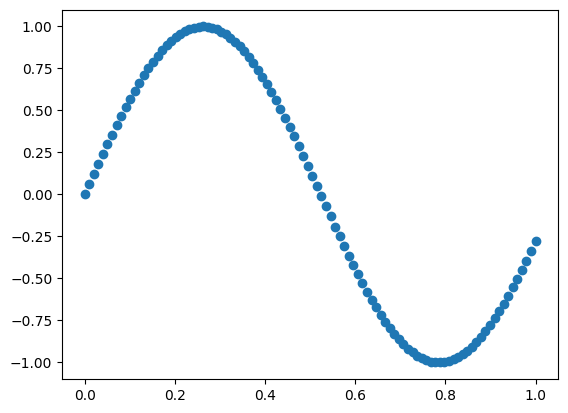

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def funToPredict(a: Value) -> Value:
	return Value(math.sin(6*a.data), op="ANSWER")


xs = np.linspace(0, 1, 100)
ys = np.array([funToPredict(Value(x)).data for x in xs])
plt.scatter(xs, ys)
plt.show()





In [13]:
mlp = MLP([1, 5, 5, 5, 1]);
# mlp = Layer(1, 1, nonlin=False)
len(mlp.parameters())

76

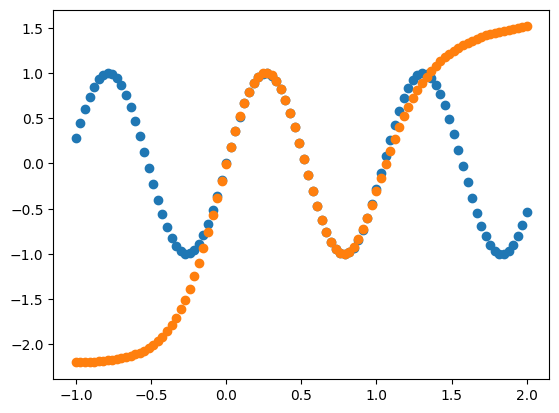

In [18]:
xs = np.linspace(-1, 2, 100)
predicted_ys=np.array([mlp([Value(x)])[0].data for x in xs])
ys = np.array([funToPredict(Value(x)).data for x in xs])
plt.scatter(xs, ys)
plt.scatter(xs, predicted_ys)
# plt.ylim(-5, 5)
plt.show()

Epoch 0 of 10000 (0.0%), Loss was 23.925837586125418


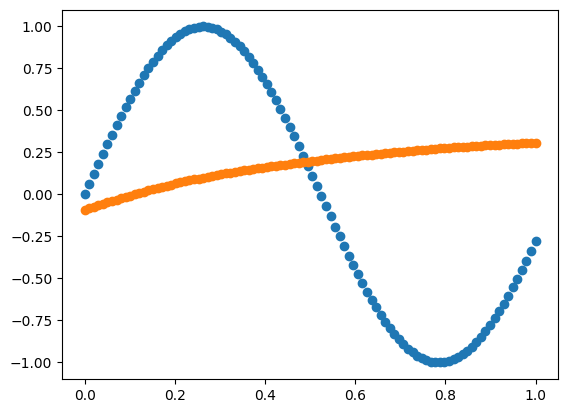

Epoch 1 of 10000 (0.01%), Loss was 19.718920993173374
Epoch 2 of 10000 (0.02%), Loss was 22.745900038079938
Epoch 3 of 10000 (0.03%), Loss was 17.406527973584325
Epoch 4 of 10000 (0.04%), Loss was 15.592540096622024
Epoch 5 of 10000 (0.05%), Loss was 15.665755000303582
Epoch 6 of 10000 (0.06%), Loss was 16.668487031137104
Epoch 7 of 10000 (0.07%), Loss was 16.347368068522847
Epoch 8 of 10000 (0.08%), Loss was 14.945746792350022
Epoch 9 of 10000 (0.09%), Loss was 13.531444166066985
Epoch 10 of 10000 (0.1%), Loss was 11.597729324015305
Epoch 11 of 10000 (0.11%), Loss was 10.310870337189577
Epoch 12 of 10000 (0.12%), Loss was 13.359077841656797
Epoch 13 of 10000 (0.13%), Loss was 12.743799809869374
Epoch 14 of 10000 (0.14%), Loss was 12.737307248420207
Epoch 15 of 10000 (0.15%), Loss was 10.624957854578707
Epoch 16 of 10000 (0.16%), Loss was 10.451242393126083
Epoch 17 of 10000 (0.17%), Loss was 7.070444471194287
Epoch 18 of 10000 (0.18%), Loss was 11.0807101626408
Epoch 19 of 10000 (0.19

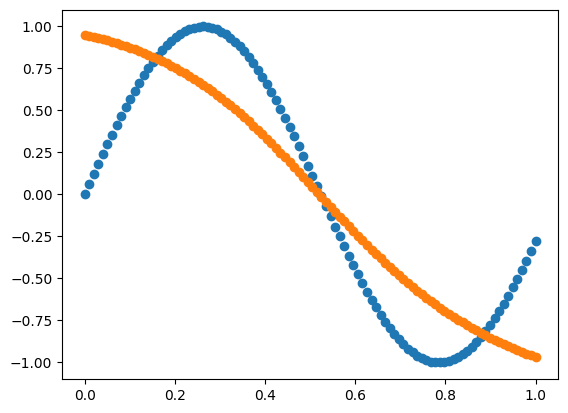

Epoch 101 of 10000 (1.01%), Loss was 3.5472959946606744
Epoch 102 of 10000 (1.02%), Loss was 3.42112592058147
Epoch 103 of 10000 (1.03%), Loss was 4.961093981889852
Epoch 104 of 10000 (1.04%), Loss was 2.7739010669201734
Epoch 105 of 10000 (1.05%), Loss was 4.266128323146632
Epoch 106 of 10000 (1.06%), Loss was 5.019965170947146
Epoch 107 of 10000 (1.07%), Loss was 4.184098053546283
Epoch 108 of 10000 (1.08%), Loss was 2.020548040944838
Epoch 109 of 10000 (1.09%), Loss was 3.160218958479424
Epoch 110 of 10000 (1.1%), Loss was 4.403566085821819
Epoch 111 of 10000 (1.11%), Loss was 3.1876226912380083
Epoch 112 of 10000 (1.12%), Loss was 4.103993681764422
Epoch 113 of 10000 (1.13%), Loss was 4.541740439713707
Epoch 114 of 10000 (1.14%), Loss was 2.9333218808727786
Epoch 115 of 10000 (1.15%), Loss was 3.2300096420198066
Epoch 116 of 10000 (1.16%), Loss was 3.5628957272103823
Epoch 117 of 10000 (1.17%), Loss was 3.8108829456963544
Epoch 118 of 10000 (1.18%), Loss was 3.9062350219010655
Epoc

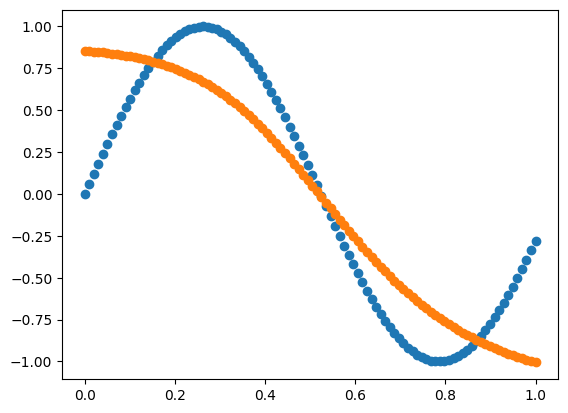

Epoch 201 of 10000 (2.01%), Loss was 2.993280739577771
Epoch 202 of 10000 (2.02%), Loss was 3.3244228818419934
Epoch 203 of 10000 (2.03%), Loss was 2.5804721362716534
Epoch 204 of 10000 (2.04%), Loss was 2.257317719970067
Epoch 205 of 10000 (2.05%), Loss was 2.1264321591000734
Epoch 206 of 10000 (2.06%), Loss was 2.3954979299759716
Epoch 207 of 10000 (2.07%), Loss was 2.8634738277338165
Epoch 208 of 10000 (2.08%), Loss was 3.4009860744889275
Epoch 209 of 10000 (2.09%), Loss was 2.8290793575076343
Epoch 210 of 10000 (2.1%), Loss was 4.004180702994682
Epoch 211 of 10000 (2.11%), Loss was 1.891028503022543
Epoch 212 of 10000 (2.12%), Loss was 3.20524554158554
Epoch 213 of 10000 (2.13%), Loss was 3.406184501702118
Epoch 214 of 10000 (2.14%), Loss was 2.635049501747896
Epoch 215 of 10000 (2.15%), Loss was 3.392238638852359
Epoch 216 of 10000 (2.16%), Loss was 4.124585830595499
Epoch 217 of 10000 (2.17%), Loss was 3.832919030487819
Epoch 218 of 10000 (2.18%), Loss was 3.015185497312651
Epoch

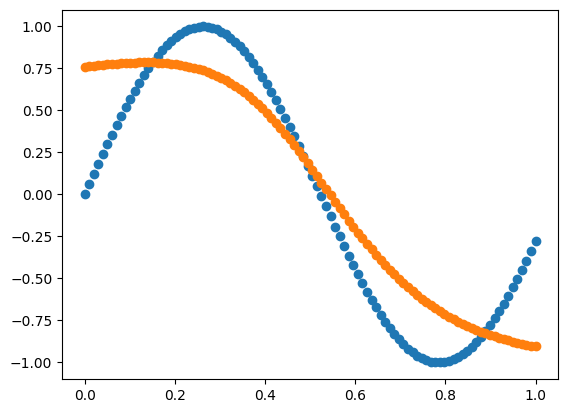

Epoch 301 of 10000 (3.01%), Loss was 2.040686329108655
Epoch 302 of 10000 (3.02%), Loss was 1.923596809238153
Epoch 303 of 10000 (3.03%), Loss was 1.5632896630034294
Epoch 304 of 10000 (3.04%), Loss was 2.3650713432645727
Epoch 305 of 10000 (3.05%), Loss was 2.1130614754356003
Epoch 306 of 10000 (3.06%), Loss was 1.9890689066249194
Epoch 307 of 10000 (3.07%), Loss was 1.7389505064604294
Epoch 308 of 10000 (3.08%), Loss was 2.253866632302643
Epoch 309 of 10000 (3.09%), Loss was 2.1626066563975614
Epoch 310 of 10000 (3.1%), Loss was 1.765579712043038
Epoch 311 of 10000 (3.11%), Loss was 2.154725853408868
Epoch 312 of 10000 (3.12%), Loss was 2.474867699725055
Epoch 313 of 10000 (3.13%), Loss was 2.462044143481522
Epoch 314 of 10000 (3.14%), Loss was 2.158961934339717
Epoch 315 of 10000 (3.15%), Loss was 2.4382229258500328
Epoch 316 of 10000 (3.16%), Loss was 1.7734937251802427
Epoch 317 of 10000 (3.17%), Loss was 3.2308644521306165
Epoch 318 of 10000 (3.18%), Loss was 2.3591692693088033
E

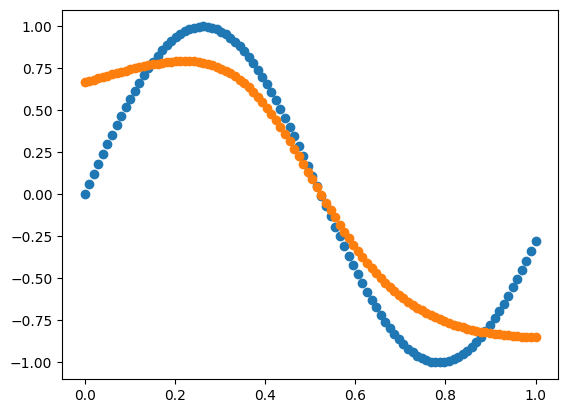

Epoch 401 of 10000 (4.01%), Loss was 2.0032472232559453
Epoch 402 of 10000 (4.02%), Loss was 1.4595114034148904
Epoch 403 of 10000 (4.03%), Loss was 1.3827387298142213
Epoch 404 of 10000 (4.04%), Loss was 2.7345089532197204
Epoch 405 of 10000 (4.05%), Loss was 1.3002862784177531
Epoch 406 of 10000 (4.06%), Loss was 1.9271607504316157
Epoch 407 of 10000 (4.07%), Loss was 1.3971491815069685
Epoch 408 of 10000 (4.08%), Loss was 1.7725286309067514
Epoch 409 of 10000 (4.09%), Loss was 1.9978848431009681
Epoch 410 of 10000 (4.1%), Loss was 1.7352897647215755
Epoch 411 of 10000 (4.11%), Loss was 1.7521095920724552
Epoch 412 of 10000 (4.12%), Loss was 1.5051762045929182
Epoch 413 of 10000 (4.13%), Loss was 1.3163765943471366
Epoch 414 of 10000 (4.14%), Loss was 1.5906317049785244
Epoch 415 of 10000 (4.15%), Loss was 1.4465859868792708
Epoch 416 of 10000 (4.16%), Loss was 1.760723054368839
Epoch 417 of 10000 (4.17%), Loss was 2.1146420885018555
Epoch 418 of 10000 (4.18%), Loss was 1.18672142003

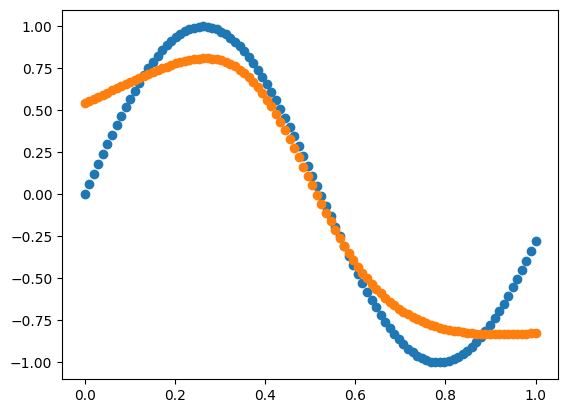

Epoch 501 of 10000 (5.01%), Loss was 0.8027748506270582
Epoch 502 of 10000 (5.02%), Loss was 0.6474447562106302
Epoch 503 of 10000 (5.03%), Loss was 1.487037193811704
Epoch 504 of 10000 (5.04%), Loss was 0.6957755564507856
Epoch 505 of 10000 (5.05%), Loss was 1.0349997063125096
Epoch 506 of 10000 (5.06%), Loss was 1.8125923962197825
Epoch 507 of 10000 (5.07%), Loss was 0.8362388185649235
Epoch 508 of 10000 (5.08%), Loss was 1.3725795500726468
Epoch 509 of 10000 (5.09%), Loss was 1.2009908101932487
Epoch 510 of 10000 (5.1%), Loss was 0.8544443090158148
Epoch 511 of 10000 (5.11%), Loss was 0.7607650385897157
Epoch 512 of 10000 (5.12%), Loss was 1.4336331693870845
Epoch 513 of 10000 (5.13%), Loss was 0.801855145870132
Epoch 514 of 10000 (5.14%), Loss was 1.2051510917745971
Epoch 515 of 10000 (5.15%), Loss was 0.9755829051173527
Epoch 516 of 10000 (5.16%), Loss was 1.5718393502193397
Epoch 517 of 10000 (5.17%), Loss was 0.6898877670847497
Epoch 518 of 10000 (5.18%), Loss was 1.643179366677

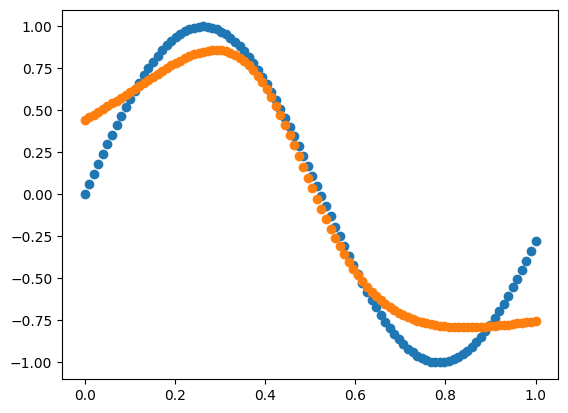

Epoch 601 of 10000 (6.01%), Loss was 0.696513568789623
Epoch 602 of 10000 (6.02%), Loss was 0.7803941846768456
Epoch 603 of 10000 (6.03%), Loss was 0.5941197730072847
Epoch 604 of 10000 (6.04%), Loss was 0.6633789613740315
Epoch 605 of 10000 (6.05%), Loss was 0.6303381733110817
Epoch 606 of 10000 (6.06%), Loss was 1.427489677230943
Epoch 607 of 10000 (6.07%), Loss was 0.817824844270713
Epoch 608 of 10000 (6.08%), Loss was 0.9192787713275143
Epoch 609 of 10000 (6.09%), Loss was 0.6610486348878698
Epoch 610 of 10000 (6.1%), Loss was 0.541908157498576
Epoch 611 of 10000 (6.11%), Loss was 0.6257330999520357
Epoch 612 of 10000 (6.12%), Loss was 0.727834903088626
Epoch 613 of 10000 (6.13%), Loss was 1.0300539165307063
Epoch 614 of 10000 (6.14%), Loss was 0.6505532678786451
Epoch 615 of 10000 (6.15%), Loss was 0.7994227553249501
Epoch 616 of 10000 (6.16%), Loss was 0.6849691969057187
Epoch 617 of 10000 (6.17%), Loss was 0.6682176861179979
Epoch 618 of 10000 (6.18%), Loss was 0.496191714430329

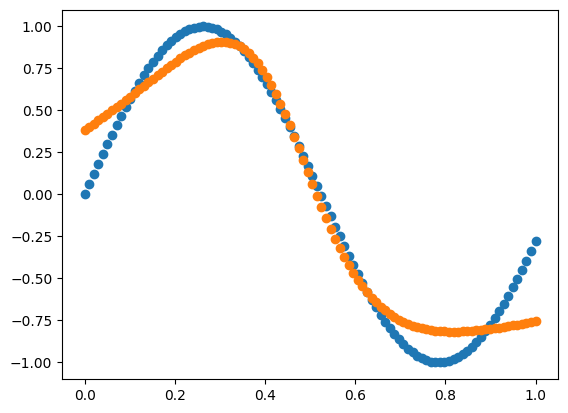

Epoch 701 of 10000 (7.01%), Loss was 0.6027796675089494
Epoch 702 of 10000 (7.02%), Loss was 0.6696246388663483
Epoch 703 of 10000 (7.03%), Loss was 0.9332924842799155
Epoch 704 of 10000 (7.04%), Loss was 0.5031507389500394
Epoch 705 of 10000 (7.05%), Loss was 0.5671171674308222
Epoch 706 of 10000 (7.06%), Loss was 0.40194495851002277
Epoch 707 of 10000 (7.07%), Loss was 0.7342473611539706
Epoch 708 of 10000 (7.08%), Loss was 0.7366971329574847
Epoch 709 of 10000 (7.09%), Loss was 0.6749439397061631
Epoch 710 of 10000 (7.1%), Loss was 0.3533530511204146
Epoch 711 of 10000 (7.11%), Loss was 0.6567359549099975
Epoch 712 of 10000 (7.12%), Loss was 0.5033907844399538
Epoch 713 of 10000 (7.13%), Loss was 0.3436681041011348
Epoch 714 of 10000 (7.14%), Loss was 0.3544773778974807
Epoch 715 of 10000 (7.15%), Loss was 0.8558461363388041
Epoch 716 of 10000 (7.16%), Loss was 0.6746541761593972
Epoch 717 of 10000 (7.17%), Loss was 1.0710164127874906
Epoch 718 of 10000 (7.18%), Loss was 0.702780514

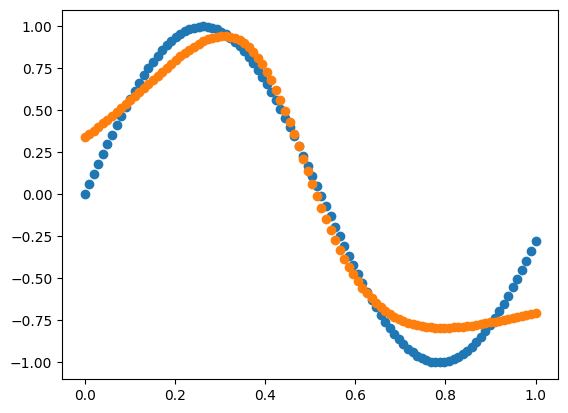

Epoch 801 of 10000 (8.01%), Loss was 0.6364776130280667
Epoch 802 of 10000 (8.02%), Loss was 0.5527880267603421
Epoch 803 of 10000 (8.03%), Loss was 0.7792626759666001
Epoch 804 of 10000 (8.04%), Loss was 0.4744591478297474
Epoch 805 of 10000 (8.05%), Loss was 0.3675727984558652
Epoch 806 of 10000 (8.06%), Loss was 0.4437097121603745
Epoch 807 of 10000 (8.07%), Loss was 0.9689072083769397
Epoch 808 of 10000 (8.08%), Loss was 0.4261472249870147
Epoch 809 of 10000 (8.09%), Loss was 0.31426620241773984
Epoch 810 of 10000 (8.1%), Loss was 0.38964414467524916
Epoch 811 of 10000 (8.11%), Loss was 0.3557081011671764
Epoch 812 of 10000 (8.12%), Loss was 0.48082947465442544
Epoch 813 of 10000 (8.13%), Loss was 0.6276165559254872
Epoch 814 of 10000 (8.14%), Loss was 0.3220304011638722
Epoch 815 of 10000 (8.15%), Loss was 0.5019989632211225
Epoch 816 of 10000 (8.16%), Loss was 0.39809529275647504
Epoch 817 of 10000 (8.17%), Loss was 0.2775344347968278
Epoch 818 of 10000 (8.18%), Loss was 0.407918

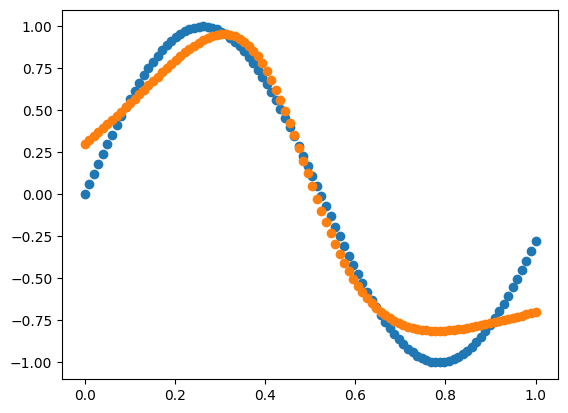

Epoch 901 of 10000 (9.01%), Loss was 0.29373087859686564
Epoch 902 of 10000 (9.02%), Loss was 0.6796507346036302
Epoch 903 of 10000 (9.03%), Loss was 0.5329574720094717
Epoch 904 of 10000 (9.04%), Loss was 0.6596274955662826
Epoch 905 of 10000 (9.05%), Loss was 0.44518701181672626
Epoch 906 of 10000 (9.06%), Loss was 0.4932145503086715
Epoch 907 of 10000 (9.07%), Loss was 0.5583053691364087
Epoch 908 of 10000 (9.08%), Loss was 0.32839856390501626
Epoch 909 of 10000 (9.09%), Loss was 0.41146205652971035
Epoch 910 of 10000 (9.1%), Loss was 0.35783895628221835
Epoch 911 of 10000 (9.11%), Loss was 0.7017716188846409
Epoch 912 of 10000 (9.12%), Loss was 0.6252832560620201
Epoch 913 of 10000 (9.13%), Loss was 0.3681656000796385
Epoch 914 of 10000 (9.14%), Loss was 0.6647267924766441
Epoch 915 of 10000 (9.15%), Loss was 0.4937262222776488
Epoch 916 of 10000 (9.16%), Loss was 0.3736988729953234
Epoch 917 of 10000 (9.17%), Loss was 0.467938313394513
Epoch 918 of 10000 (9.18%), Loss was 0.445148

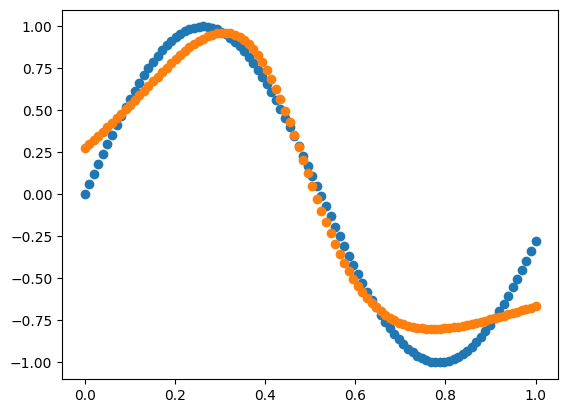

Epoch 1001 of 10000 (10.01%), Loss was 0.3753639339307205
Epoch 1002 of 10000 (10.02%), Loss was 0.48516420620479117
Epoch 1003 of 10000 (10.03%), Loss was 0.24435894829999452
Epoch 1004 of 10000 (10.04%), Loss was 0.33948380776207343
Epoch 1005 of 10000 (10.05%), Loss was 0.4673705507041837
Epoch 1006 of 10000 (10.06%), Loss was 0.3937580921871269
Epoch 1007 of 10000 (10.07%), Loss was 0.3847922861279955
Epoch 1008 of 10000 (10.08%), Loss was 0.40014739211651607
Epoch 1009 of 10000 (10.09%), Loss was 0.3735527845330271
Epoch 1010 of 10000 (10.1%), Loss was 0.5372392926463132
Epoch 1011 of 10000 (10.11%), Loss was 0.5020011635266045
Epoch 1012 of 10000 (10.12%), Loss was 0.30755801816284495
Epoch 1013 of 10000 (10.13%), Loss was 0.5600281705543232
Epoch 1014 of 10000 (10.14%), Loss was 0.5238076801678893
Epoch 1015 of 10000 (10.15%), Loss was 0.3895929306927001
Epoch 1016 of 10000 (10.16%), Loss was 0.3536799989977904
Epoch 1017 of 10000 (10.17%), Loss was 0.4936805869123005
Epoch 1018

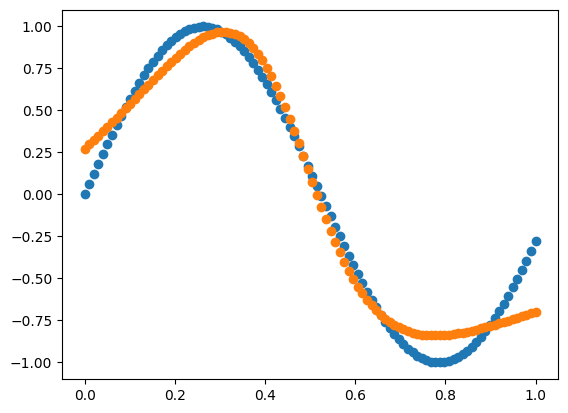

Epoch 1101 of 10000 (11.01%), Loss was 0.3953919196210541
Epoch 1102 of 10000 (11.02%), Loss was 0.294648446975164
Epoch 1103 of 10000 (11.03%), Loss was 0.34147717916598064
Epoch 1104 of 10000 (11.04%), Loss was 0.23959700637732256
Epoch 1105 of 10000 (11.05%), Loss was 0.6863519647792609
Epoch 1106 of 10000 (11.06%), Loss was 0.2327152764254343
Epoch 1107 of 10000 (11.07%), Loss was 0.45655843650759986
Epoch 1108 of 10000 (11.08%), Loss was 0.5793734115503666
Epoch 1109 of 10000 (11.09%), Loss was 0.24788748009753475
Epoch 1110 of 10000 (11.1%), Loss was 0.46031503519599964
Epoch 1111 of 10000 (11.11%), Loss was 0.3841657253836471
Epoch 1112 of 10000 (11.12%), Loss was 0.5153502095675184
Epoch 1113 of 10000 (11.13%), Loss was 0.24805269702076063
Epoch 1114 of 10000 (11.14%), Loss was 0.5869283312651508
Epoch 1115 of 10000 (11.15%), Loss was 0.4521874974323016
Epoch 1116 of 10000 (11.16%), Loss was 0.5910171449610879
Epoch 1117 of 10000 (11.17%), Loss was 0.42355420018515844
Epoch 111

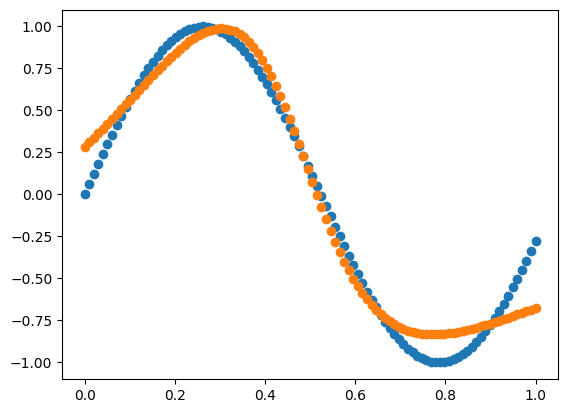

Epoch 1201 of 10000 (12.01%), Loss was 0.4587893978550978
Epoch 1202 of 10000 (12.02%), Loss was 0.21605314710405096
Epoch 1203 of 10000 (12.03%), Loss was 0.28272356695692186
Epoch 1204 of 10000 (12.04%), Loss was 0.5074208923147101
Epoch 1205 of 10000 (12.05%), Loss was 0.3729566714989514
Epoch 1206 of 10000 (12.06%), Loss was 0.683441869762075
Epoch 1207 of 10000 (12.07%), Loss was 0.39247916324104615
Epoch 1208 of 10000 (12.08%), Loss was 0.36020231305979084
Epoch 1209 of 10000 (12.09%), Loss was 0.425634227341058
Epoch 1210 of 10000 (12.1%), Loss was 0.36740026851689167
Epoch 1211 of 10000 (12.11%), Loss was 0.2860718268358756
Epoch 1212 of 10000 (12.12%), Loss was 0.34105643887677567
Epoch 1213 of 10000 (12.13%), Loss was 0.5254192180908265
Epoch 1214 of 10000 (12.14%), Loss was 0.5544820748523397
Epoch 1215 of 10000 (12.15%), Loss was 0.34177709813613866
Epoch 1216 of 10000 (12.16%), Loss was 0.44784648669963456
Epoch 1217 of 10000 (12.17%), Loss was 0.45578311231003654
Epoch 12

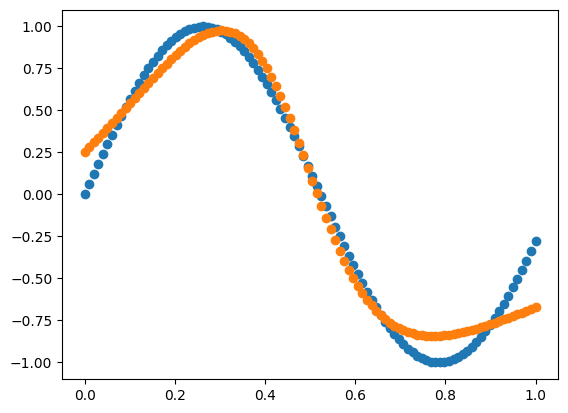

Epoch 1301 of 10000 (13.01%), Loss was 0.3758803404021537
Epoch 1302 of 10000 (13.02%), Loss was 0.3304682947316042
Epoch 1303 of 10000 (13.03%), Loss was 0.4736270469282908
Epoch 1304 of 10000 (13.04%), Loss was 0.3134881441258082
Epoch 1305 of 10000 (13.05%), Loss was 0.17807228189576949
Epoch 1306 of 10000 (13.06%), Loss was 0.6110747697812284
Epoch 1307 of 10000 (13.07%), Loss was 0.21005433578747554
Epoch 1308 of 10000 (13.08%), Loss was 0.34056777200406707
Epoch 1309 of 10000 (13.09%), Loss was 0.6730392610262999
Epoch 1310 of 10000 (13.1%), Loss was 0.23955590994160383
Epoch 1311 of 10000 (13.11%), Loss was 0.3138162584020011
Epoch 1312 of 10000 (13.12%), Loss was 0.5679556352179423
Epoch 1313 of 10000 (13.13%), Loss was 0.2680946283956495
Epoch 1314 of 10000 (13.14%), Loss was 0.2886568578771347
Epoch 1315 of 10000 (13.15%), Loss was 0.35876254934904755
Epoch 1316 of 10000 (13.16%), Loss was 0.2606608860687103
Epoch 1317 of 10000 (13.17%), Loss was 0.3775573757427599
Epoch 1318

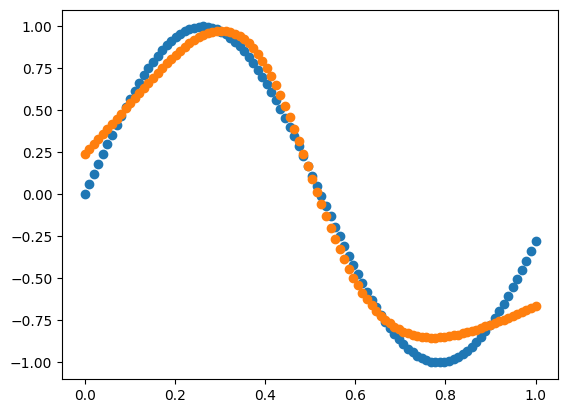

Epoch 1401 of 10000 (14.01%), Loss was 0.2881760486714749
Epoch 1402 of 10000 (14.02%), Loss was 0.21046272758276266
Epoch 1403 of 10000 (14.03%), Loss was 0.3666808451155478
Epoch 1404 of 10000 (14.04%), Loss was 0.3854699900923552
Epoch 1405 of 10000 (14.05%), Loss was 0.2910816878928122
Epoch 1406 of 10000 (14.06%), Loss was 0.2117745283801535
Epoch 1407 of 10000 (14.07%), Loss was 0.5023796540597656
Epoch 1408 of 10000 (14.08%), Loss was 0.44651301992848724
Epoch 1409 of 10000 (14.09%), Loss was 0.2998625350830101
Epoch 1410 of 10000 (14.1%), Loss was 0.5575670432041633
Epoch 1411 of 10000 (14.11%), Loss was 0.2971237196959018
Epoch 1412 of 10000 (14.12%), Loss was 0.40751904283514157
Epoch 1413 of 10000 (14.13%), Loss was 0.41858758345239544
Epoch 1414 of 10000 (14.14%), Loss was 0.6569990488834337
Epoch 1415 of 10000 (14.15%), Loss was 0.33768914002385253
Epoch 1416 of 10000 (14.16%), Loss was 0.3794182543315784
Epoch 1417 of 10000 (14.17%), Loss was 0.30573836448731656
Epoch 141

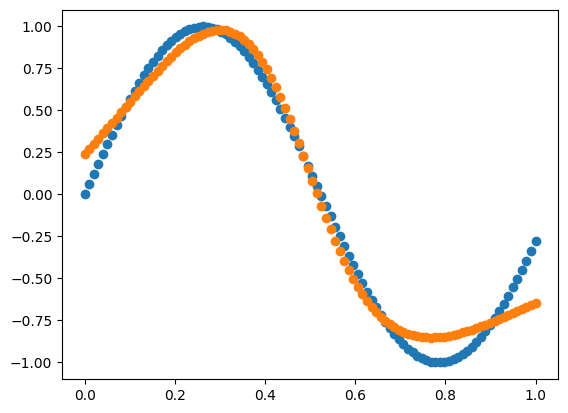

Epoch 1501 of 10000 (15.01%), Loss was 0.4420904541725255
Epoch 1502 of 10000 (15.02%), Loss was 0.340547184184142
Epoch 1503 of 10000 (15.03%), Loss was 0.32180978049254866
Epoch 1504 of 10000 (15.04%), Loss was 0.2819308082105385
Epoch 1505 of 10000 (15.05%), Loss was 0.2773638268804892
Epoch 1506 of 10000 (15.06%), Loss was 0.5583579737569628
Epoch 1507 of 10000 (15.07%), Loss was 0.2644409214859194
Epoch 1508 of 10000 (15.08%), Loss was 0.2810190855232863
Epoch 1509 of 10000 (15.09%), Loss was 0.5123210856989786
Epoch 1510 of 10000 (15.1%), Loss was 0.24410471060414338
Epoch 1511 of 10000 (15.11%), Loss was 0.26362008087634364
Epoch 1512 of 10000 (15.12%), Loss was 0.24877243599196439
Epoch 1513 of 10000 (15.13%), Loss was 0.32718867914646577
Epoch 1514 of 10000 (15.14%), Loss was 0.37776352017171694
Epoch 1515 of 10000 (15.15%), Loss was 0.33860337477843044
Epoch 1516 of 10000 (15.16%), Loss was 0.26408992578764806
Epoch 1517 of 10000 (15.17%), Loss was 0.20903504778907075
Epoch 1

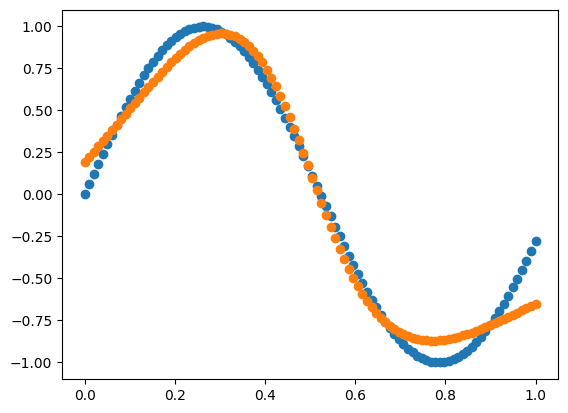

Epoch 1601 of 10000 (16.01%), Loss was 0.47198157176681743
Epoch 1602 of 10000 (16.02%), Loss was 0.28492837189491105
Epoch 1603 of 10000 (16.03%), Loss was 0.1752762481147786
Epoch 1604 of 10000 (16.04%), Loss was 0.4470216671761623
Epoch 1605 of 10000 (16.05%), Loss was 0.2728522650073712
Epoch 1606 of 10000 (16.06%), Loss was 0.2159383162027058
Epoch 1607 of 10000 (16.07%), Loss was 0.4008116230987137
Epoch 1608 of 10000 (16.08%), Loss was 0.3065584248655293
Epoch 1609 of 10000 (16.09%), Loss was 0.3465792429877249
Epoch 1610 of 10000 (16.1%), Loss was 0.23811792449614633
Epoch 1611 of 10000 (16.11%), Loss was 0.39912977866799887
Epoch 1612 of 10000 (16.12%), Loss was 0.38980615534122004
Epoch 1613 of 10000 (16.13%), Loss was 0.2802134685666071
Epoch 1614 of 10000 (16.14%), Loss was 0.2693849638633348
Epoch 1615 of 10000 (16.15%), Loss was 0.20476860598115373
Epoch 1616 of 10000 (16.16%), Loss was 0.3033963754937457
Epoch 1617 of 10000 (16.17%), Loss was 0.3503105046905237
Epoch 161

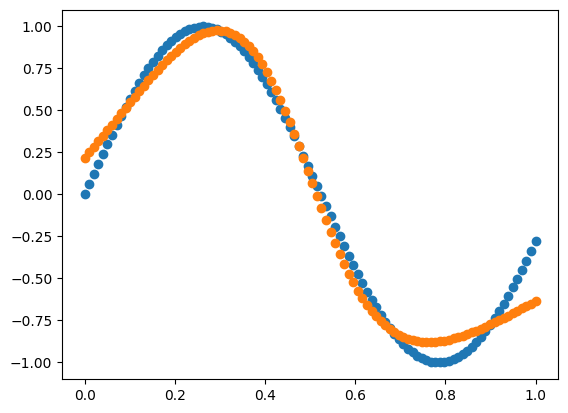

Epoch 1701 of 10000 (17.01%), Loss was 0.4145239582966786
Epoch 1702 of 10000 (17.02%), Loss was 0.235416691775601
Epoch 1703 of 10000 (17.03%), Loss was 0.25182943149102666
Epoch 1704 of 10000 (17.04%), Loss was 0.3910831138044423
Epoch 1705 of 10000 (17.05%), Loss was 0.21374649926573058
Epoch 1706 of 10000 (17.06%), Loss was 0.3331085842031348
Epoch 1707 of 10000 (17.07%), Loss was 0.20994021537879598
Epoch 1708 of 10000 (17.08%), Loss was 0.320558998675515
Epoch 1709 of 10000 (17.09%), Loss was 0.39135121577951376
Epoch 1710 of 10000 (17.1%), Loss was 0.29656322451417416
Epoch 1711 of 10000 (17.11%), Loss was 0.2283581151508285
Epoch 1712 of 10000 (17.12%), Loss was 0.5019476191430724
Epoch 1713 of 10000 (17.13%), Loss was 0.3150402768901325
Epoch 1714 of 10000 (17.14%), Loss was 0.2833925750303888
Epoch 1715 of 10000 (17.15%), Loss was 0.2223813147538576
Epoch 1716 of 10000 (17.16%), Loss was 0.28003138932621696
Epoch 1717 of 10000 (17.17%), Loss was 0.2092203062179782
Epoch 1718 

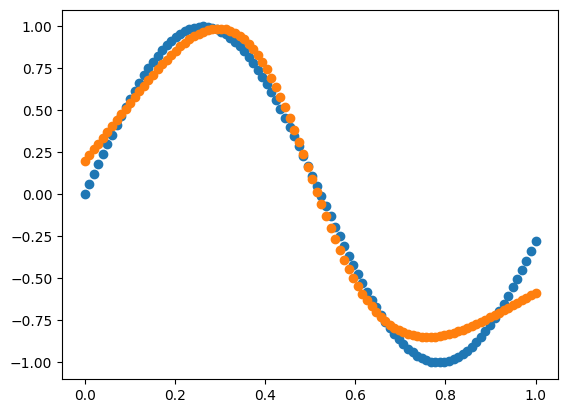

Epoch 1801 of 10000 (18.01%), Loss was 0.20741580978764534
Epoch 1802 of 10000 (18.02%), Loss was 0.34584946903252906
Epoch 1803 of 10000 (18.03%), Loss was 0.3083204979751408
Epoch 1804 of 10000 (18.04%), Loss was 0.3384243672319552
Epoch 1805 of 10000 (18.05%), Loss was 0.18968504950351972
Epoch 1806 of 10000 (18.06%), Loss was 0.18117917600660183
Epoch 1807 of 10000 (18.07%), Loss was 0.16917483661853527
Epoch 1808 of 10000 (18.08%), Loss was 0.32982367324771583
Epoch 1809 of 10000 (18.09%), Loss was 0.17622720764730987
Epoch 1810 of 10000 (18.1%), Loss was 0.2202220073901317
Epoch 1811 of 10000 (18.11%), Loss was 0.19967647168749764
Epoch 1812 of 10000 (18.12%), Loss was 0.194888620896677
Epoch 1813 of 10000 (18.13%), Loss was 0.3086099368588107
Epoch 1814 of 10000 (18.14%), Loss was 0.25009995029444915
Epoch 1815 of 10000 (18.15%), Loss was 0.21530462463939676
Epoch 1816 of 10000 (18.16%), Loss was 0.316789940784117
Epoch 1817 of 10000 (18.17%), Loss was 0.3548701025459422
Epoch 1

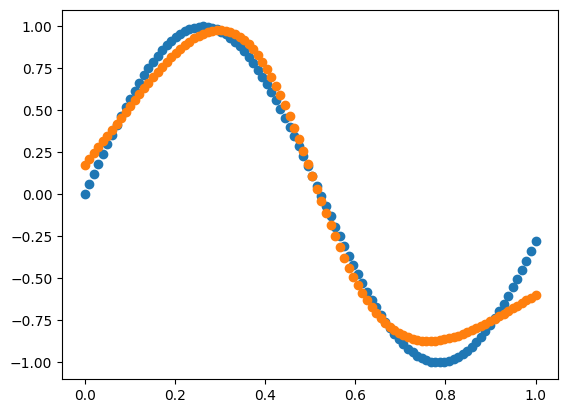

Epoch 1901 of 10000 (19.01%), Loss was 0.2675539006028969
Epoch 1902 of 10000 (19.02%), Loss was 0.29590566741050006
Epoch 1903 of 10000 (19.03%), Loss was 0.18011871817669156
Epoch 1904 of 10000 (19.04%), Loss was 0.15820751552662932
Epoch 1905 of 10000 (19.05%), Loss was 0.14784192753881653
Epoch 1906 of 10000 (19.06%), Loss was 0.25239926171502436
Epoch 1907 of 10000 (19.07%), Loss was 0.155465745262752
Epoch 1908 of 10000 (19.08%), Loss was 0.18490273848919822
Epoch 1909 of 10000 (19.09%), Loss was 0.26323174190716436
Epoch 1910 of 10000 (19.1%), Loss was 0.31523797279893645
Epoch 1911 of 10000 (19.11%), Loss was 0.2921113236002338
Epoch 1912 of 10000 (19.12%), Loss was 0.22217559348337584
Epoch 1913 of 10000 (19.13%), Loss was 0.36306598943963153
Epoch 1914 of 10000 (19.14%), Loss was 0.2897346848384995
Epoch 1915 of 10000 (19.15%), Loss was 0.21694056122314354
Epoch 1916 of 10000 (19.16%), Loss was 0.31868105622769255
Epoch 1917 of 10000 (19.17%), Loss was 0.19354302517983796
Epo

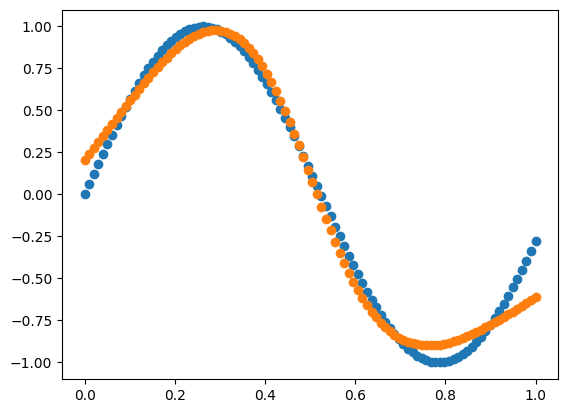

Epoch 2001 of 10000 (20.01%), Loss was 0.18702248200969865
Epoch 2002 of 10000 (20.02%), Loss was 0.19369666576884723
Epoch 2003 of 10000 (20.03%), Loss was 0.1801133935520332
Epoch 2004 of 10000 (20.04%), Loss was 0.1543006416209451
Epoch 2005 of 10000 (20.05%), Loss was 0.34953584286743666
Epoch 2006 of 10000 (20.06%), Loss was 0.21454864967398898
Epoch 2007 of 10000 (20.07%), Loss was 0.18285257402904218
Epoch 2008 of 10000 (20.08%), Loss was 0.2677947150752141
Epoch 2009 of 10000 (20.09%), Loss was 0.29403147036613964
Epoch 2010 of 10000 (20.1%), Loss was 0.21710009282572568
Epoch 2011 of 10000 (20.11%), Loss was 0.20338194155719674
Epoch 2012 of 10000 (20.12%), Loss was 0.16555872137101837
Epoch 2013 of 10000 (20.13%), Loss was 0.09701884960543393
Epoch 2014 of 10000 (20.14%), Loss was 0.3259483285858882
Epoch 2015 of 10000 (20.15%), Loss was 0.2132534449096157
Epoch 2016 of 10000 (20.16%), Loss was 0.15945117141037782
Epoch 2017 of 10000 (20.17%), Loss was 0.15842549631737424
Epo

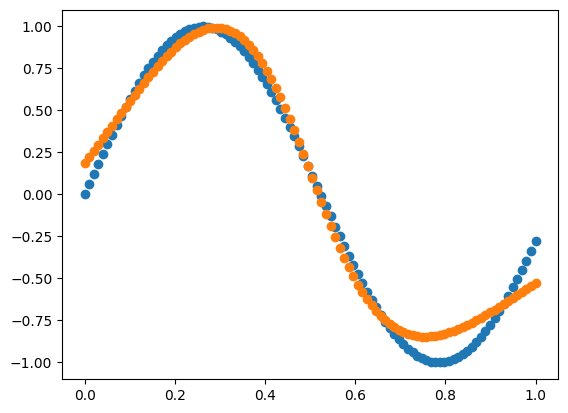

Epoch 2101 of 10000 (21.01%), Loss was 0.22228962483841813
Epoch 2102 of 10000 (21.02%), Loss was 0.2009766560601614
Epoch 2103 of 10000 (21.03%), Loss was 0.22847802521901492
Epoch 2104 of 10000 (21.04%), Loss was 0.25014618006242156
Epoch 2105 of 10000 (21.05%), Loss was 0.15381951468901822
Epoch 2106 of 10000 (21.06%), Loss was 0.168653257229326
Epoch 2107 of 10000 (21.07%), Loss was 0.22136816201892856
Epoch 2108 of 10000 (21.08%), Loss was 0.3047758282817128
Epoch 2109 of 10000 (21.09%), Loss was 0.18213802824134492
Epoch 2110 of 10000 (21.1%), Loss was 0.17057298908620913
Epoch 2111 of 10000 (21.11%), Loss was 0.24090439129537594
Epoch 2112 of 10000 (21.12%), Loss was 0.13848019925175456
Epoch 2113 of 10000 (21.13%), Loss was 0.24663913266238235
Epoch 2114 of 10000 (21.14%), Loss was 0.35352560618859524
Epoch 2115 of 10000 (21.15%), Loss was 0.16174353081331844
Epoch 2116 of 10000 (21.16%), Loss was 0.2579674260968059
Epoch 2117 of 10000 (21.17%), Loss was 0.2519743953957314
Epoc

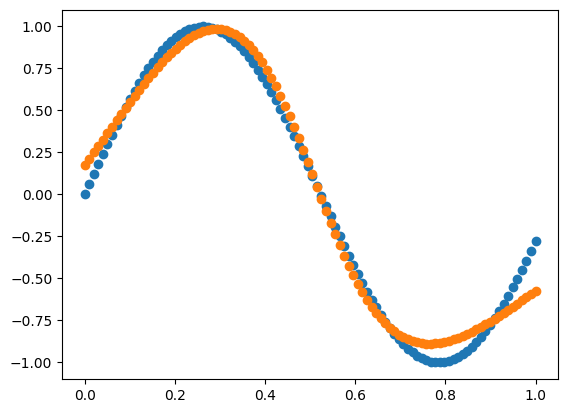

Epoch 2201 of 10000 (22.01%), Loss was 0.20706461592016323
Epoch 2202 of 10000 (22.02%), Loss was 0.190721761659041
Epoch 2203 of 10000 (22.03%), Loss was 0.2629462750863791
Epoch 2204 of 10000 (22.04%), Loss was 0.16161869750723956
Epoch 2205 of 10000 (22.05%), Loss was 0.3027483560213251
Epoch 2206 of 10000 (22.06%), Loss was 0.16700243461041792
Epoch 2207 of 10000 (22.07%), Loss was 0.18836555536717278
Epoch 2208 of 10000 (22.08%), Loss was 0.09511836043454916
Epoch 2209 of 10000 (22.09%), Loss was 0.17201371680493505
Epoch 2210 of 10000 (22.1%), Loss was 0.11819069701554254
Epoch 2211 of 10000 (22.11%), Loss was 0.16664886343251906
Epoch 2212 of 10000 (22.12%), Loss was 0.15785323972595922
Epoch 2213 of 10000 (22.13%), Loss was 0.15134268091339584
Epoch 2214 of 10000 (22.14%), Loss was 0.17968688578497088
Epoch 2215 of 10000 (22.15%), Loss was 0.15104088127051385
Epoch 2216 of 10000 (22.16%), Loss was 0.4627368644951027
Epoch 2217 of 10000 (22.17%), Loss was 0.13955625942763028
Epo

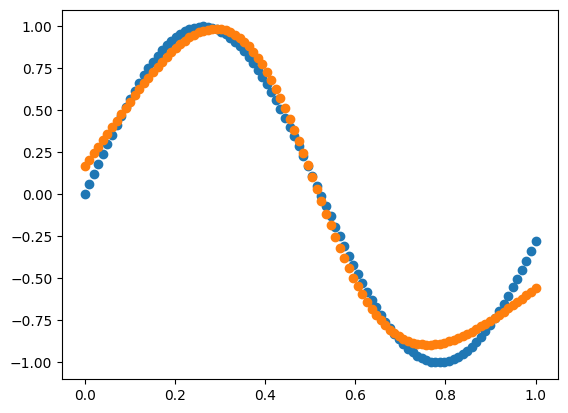

Epoch 2301 of 10000 (23.01%), Loss was 0.1579669872597423
Epoch 2302 of 10000 (23.02%), Loss was 0.3562278019340664
Epoch 2303 of 10000 (23.03%), Loss was 0.2590157909572078
Epoch 2304 of 10000 (23.04%), Loss was 0.11754571818720194
Epoch 2305 of 10000 (23.05%), Loss was 0.20138031545177856
Epoch 2306 of 10000 (23.06%), Loss was 0.3053311582593577
Epoch 2307 of 10000 (23.07%), Loss was 0.15531237158765177
Epoch 2308 of 10000 (23.08%), Loss was 0.2027860383796543
Epoch 2309 of 10000 (23.09%), Loss was 0.16943370858804324
Epoch 2310 of 10000 (23.1%), Loss was 0.20684027364793137
Epoch 2311 of 10000 (23.11%), Loss was 0.19436814387017382
Epoch 2312 of 10000 (23.12%), Loss was 0.15202753054524384
Epoch 2313 of 10000 (23.13%), Loss was 0.20275837383566092
Epoch 2314 of 10000 (23.14%), Loss was 0.18131294299639025
Epoch 2315 of 10000 (23.15%), Loss was 0.16443204277533885
Epoch 2316 of 10000 (23.16%), Loss was 0.15994621691281474
Epoch 2317 of 10000 (23.17%), Loss was 0.1440661274122785
Epoc

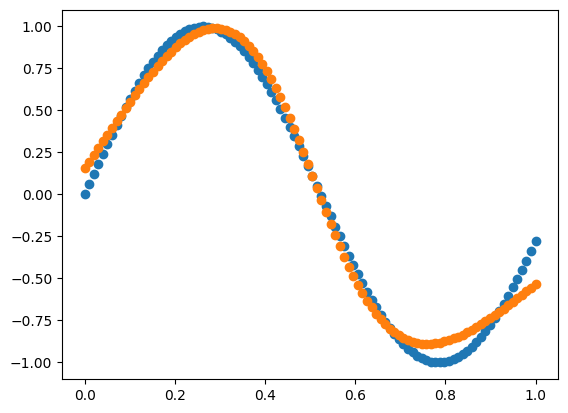

Epoch 2401 of 10000 (24.01%), Loss was 0.12435417335100193
Epoch 2402 of 10000 (24.02%), Loss was 0.12009214542602839
Epoch 2403 of 10000 (24.03%), Loss was 0.17930934243671018
Epoch 2404 of 10000 (24.04%), Loss was 0.19129747238729103
Epoch 2405 of 10000 (24.05%), Loss was 0.16668189510828627
Epoch 2406 of 10000 (24.06%), Loss was 0.1635015763788866
Epoch 2407 of 10000 (24.07%), Loss was 0.14539366738897078
Epoch 2408 of 10000 (24.08%), Loss was 0.11270716895559603
Epoch 2409 of 10000 (24.09%), Loss was 0.2562413940151957
Epoch 2410 of 10000 (24.1%), Loss was 0.1411729291069485
Epoch 2411 of 10000 (24.11%), Loss was 0.22323779646111094
Epoch 2412 of 10000 (24.12%), Loss was 0.23687362240277332
Epoch 2413 of 10000 (24.13%), Loss was 0.16576235050976396
Epoch 2414 of 10000 (24.14%), Loss was 0.12488101839082413
Epoch 2415 of 10000 (24.15%), Loss was 0.1279382523165317
Epoch 2416 of 10000 (24.16%), Loss was 0.21415536855428952
Epoch 2417 of 10000 (24.17%), Loss was 0.14109658989284665
Ep

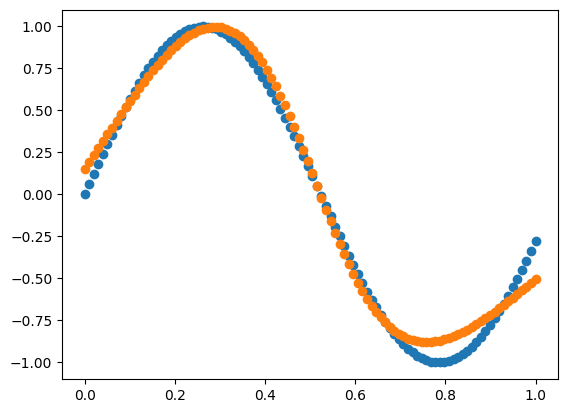

Epoch 2501 of 10000 (25.01%), Loss was 0.11853070682209071
Epoch 2502 of 10000 (25.02%), Loss was 0.21669652628059569
Epoch 2503 of 10000 (25.03%), Loss was 0.11268440717788566
Epoch 2504 of 10000 (25.04%), Loss was 0.1485306357300845
Epoch 2505 of 10000 (25.05%), Loss was 0.20927560913798568
Epoch 2506 of 10000 (25.06%), Loss was 0.09878781975486768
Epoch 2507 of 10000 (25.07%), Loss was 0.15216785508147634
Epoch 2508 of 10000 (25.08%), Loss was 0.07421589477376317
Epoch 2509 of 10000 (25.09%), Loss was 0.23973081240365832
Epoch 2510 of 10000 (25.1%), Loss was 0.1483626638657699
Epoch 2511 of 10000 (25.11%), Loss was 0.21313696004884175
Epoch 2512 of 10000 (25.12%), Loss was 0.15226012172247208
Epoch 2513 of 10000 (25.13%), Loss was 0.16826898618177208
Epoch 2514 of 10000 (25.14%), Loss was 0.16840036164208746
Epoch 2515 of 10000 (25.15%), Loss was 0.0956845586818859
Epoch 2516 of 10000 (25.16%), Loss was 0.18229115944657007
Epoch 2517 of 10000 (25.17%), Loss was 0.11263115162780826
E

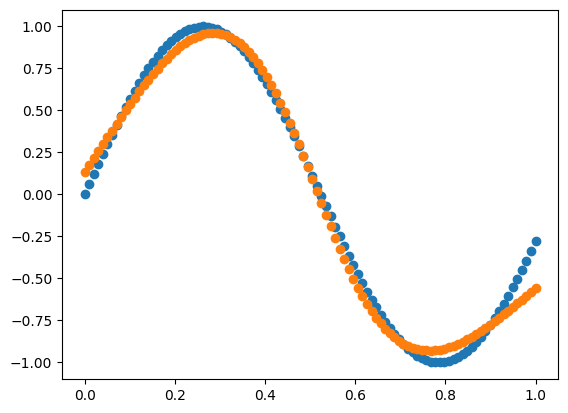

Epoch 2601 of 10000 (26.01%), Loss was 0.2622416606322634
Epoch 2602 of 10000 (26.02%), Loss was 0.08656920258593769
Epoch 2603 of 10000 (26.03%), Loss was 0.0856943910079266
Epoch 2604 of 10000 (26.04%), Loss was 0.17827839370712678
Epoch 2605 of 10000 (26.05%), Loss was 0.19341584908906062
Epoch 2606 of 10000 (26.06%), Loss was 0.1123403149403368
Epoch 2607 of 10000 (26.07%), Loss was 0.20550818369100493
Epoch 2608 of 10000 (26.08%), Loss was 0.11634946862921106
Epoch 2609 of 10000 (26.09%), Loss was 0.09985922340037856
Epoch 2610 of 10000 (26.1%), Loss was 0.0979416976722283
Epoch 2611 of 10000 (26.11%), Loss was 0.07590026667654713
Epoch 2612 of 10000 (26.12%), Loss was 0.12452269241866694
Epoch 2613 of 10000 (26.13%), Loss was 0.13985598032764432
Epoch 2614 of 10000 (26.14%), Loss was 0.19506893904341693
Epoch 2615 of 10000 (26.15%), Loss was 0.14183516649534655
Epoch 2616 of 10000 (26.16%), Loss was 0.14400429241686136
Epoch 2617 of 10000 (26.17%), Loss was 0.13166204513326685
Ep

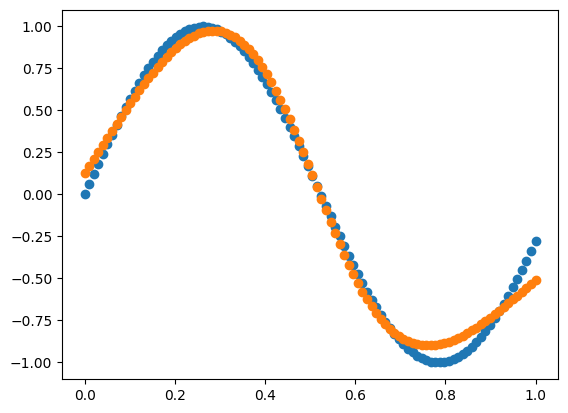

Epoch 2701 of 10000 (27.01%), Loss was 0.13940686329487953
Epoch 2702 of 10000 (27.02%), Loss was 0.13003461875540556
Epoch 2703 of 10000 (27.03%), Loss was 0.12097939823589984
Epoch 2704 of 10000 (27.04%), Loss was 0.11424748377928101
Epoch 2705 of 10000 (27.05%), Loss was 0.19767940724749478
Epoch 2706 of 10000 (27.06%), Loss was 0.12988124575815319
Epoch 2707 of 10000 (27.07%), Loss was 0.09777352345101266
Epoch 2708 of 10000 (27.08%), Loss was 0.1876074248575642
Epoch 2709 of 10000 (27.09%), Loss was 0.17456323492697964
Epoch 2710 of 10000 (27.1%), Loss was 0.0924322519356154
Epoch 2711 of 10000 (27.11%), Loss was 0.12538408887383573
Epoch 2712 of 10000 (27.12%), Loss was 0.16840861531005455
Epoch 2713 of 10000 (27.13%), Loss was 0.23815255938900953
Epoch 2714 of 10000 (27.14%), Loss was 0.08743202812240156
Epoch 2715 of 10000 (27.15%), Loss was 0.1415204233849973
Epoch 2716 of 10000 (27.16%), Loss was 0.06168179514767676
Epoch 2717 of 10000 (27.17%), Loss was 0.16685250766613535
E

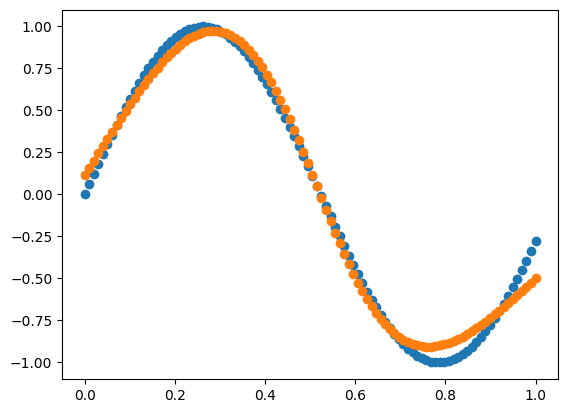

Epoch 2801 of 10000 (28.01%), Loss was 0.09361473656117401
Epoch 2802 of 10000 (28.02%), Loss was 0.17161621696009763
Epoch 2803 of 10000 (28.03%), Loss was 0.08796628764121261
Epoch 2804 of 10000 (28.04%), Loss was 0.1253034975605256
Epoch 2805 of 10000 (28.05%), Loss was 0.10742187362155348
Epoch 2806 of 10000 (28.06%), Loss was 0.23729802655874435
Epoch 2807 of 10000 (28.07%), Loss was 0.07980844723353032
Epoch 2808 of 10000 (28.08%), Loss was 0.15849426317679138
Epoch 2809 of 10000 (28.09%), Loss was 0.14738142592591297
Epoch 2810 of 10000 (28.1%), Loss was 0.09834285943948871
Epoch 2811 of 10000 (28.11%), Loss was 0.11302975033706343
Epoch 2812 of 10000 (28.12%), Loss was 0.11398448708420214
Epoch 2813 of 10000 (28.13%), Loss was 0.21051928055338395
Epoch 2814 of 10000 (28.14%), Loss was 0.07672759371804702
Epoch 2815 of 10000 (28.15%), Loss was 0.14235229678593686
Epoch 2816 of 10000 (28.16%), Loss was 0.10988285770102064
Epoch 2817 of 10000 (28.17%), Loss was 0.1747984644073647


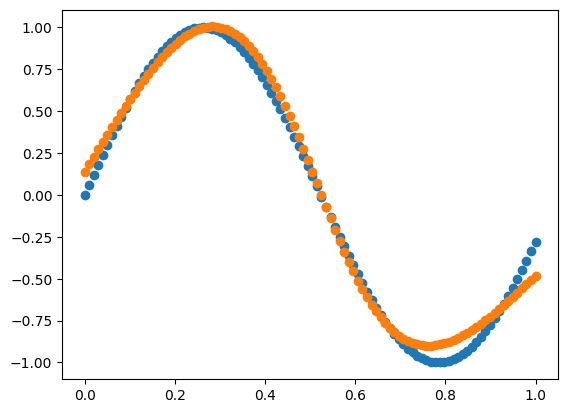

Epoch 2901 of 10000 (29.01%), Loss was 0.11215698027460065
Epoch 2902 of 10000 (29.02%), Loss was 0.19278093558540116
Epoch 2903 of 10000 (29.03%), Loss was 0.14979369729290987
Epoch 2904 of 10000 (29.04%), Loss was 0.06433928638579806
Epoch 2905 of 10000 (29.05%), Loss was 0.109450791819614
Epoch 2906 of 10000 (29.06%), Loss was 0.172854489273589
Epoch 2907 of 10000 (29.07%), Loss was 0.12037437594254191
Epoch 2908 of 10000 (29.08%), Loss was 0.121509332837856
Epoch 2909 of 10000 (29.09%), Loss was 0.07496079983996451
Epoch 2910 of 10000 (29.1%), Loss was 0.11417232904908428
Epoch 2911 of 10000 (29.11%), Loss was 0.06747932417465105
Epoch 2912 of 10000 (29.12%), Loss was 0.0954448941703834
Epoch 2913 of 10000 (29.13%), Loss was 0.12186792935578745
Epoch 2914 of 10000 (29.14%), Loss was 0.1129320265642507
Epoch 2915 of 10000 (29.15%), Loss was 0.08294874522855147
Epoch 2916 of 10000 (29.16%), Loss was 0.14431130001172202
Epoch 2917 of 10000 (29.17%), Loss was 0.1875962878411368
Epoch 2

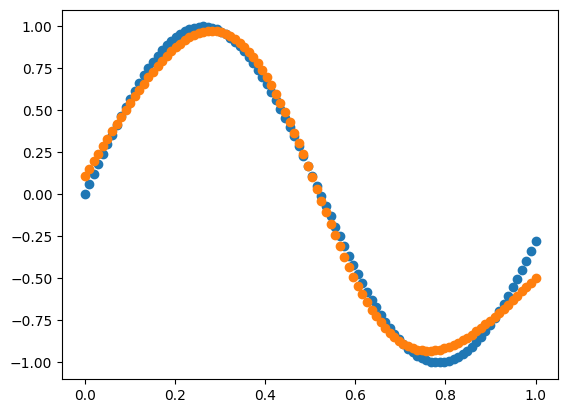

Epoch 3001 of 10000 (30.01%), Loss was 0.1302431255959063
Epoch 3002 of 10000 (30.02%), Loss was 0.12691566049979774
Epoch 3003 of 10000 (30.03%), Loss was 0.18167192824542913
Epoch 3004 of 10000 (30.04%), Loss was 0.09169856955014112
Epoch 3005 of 10000 (30.05%), Loss was 0.07341946876774771
Epoch 3006 of 10000 (30.06%), Loss was 0.09235606376055576
Epoch 3007 of 10000 (30.07%), Loss was 0.07250992379399132
Epoch 3008 of 10000 (30.08%), Loss was 0.07471363900981279
Epoch 3009 of 10000 (30.09%), Loss was 0.08470095920835632
Epoch 3010 of 10000 (30.1%), Loss was 0.08026644144488766
Epoch 3011 of 10000 (30.11%), Loss was 0.14942825160569703
Epoch 3012 of 10000 (30.12%), Loss was 0.14496803704968145
Epoch 3013 of 10000 (30.13%), Loss was 0.14901554403163883
Epoch 3014 of 10000 (30.14%), Loss was 0.08927742551012288
Epoch 3015 of 10000 (30.15%), Loss was 0.1040117808524813
Epoch 3016 of 10000 (30.16%), Loss was 0.14445458775563322
Epoch 3017 of 10000 (30.17%), Loss was 0.06039184600879103


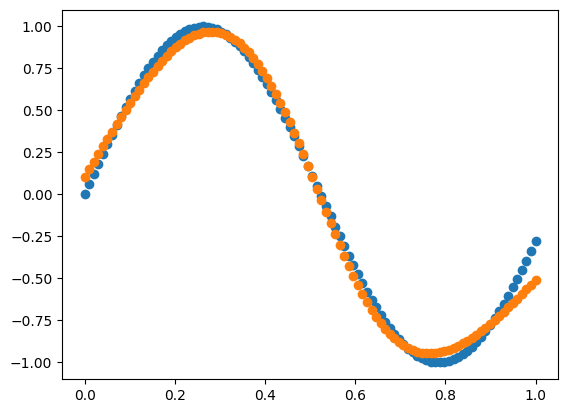

Epoch 3101 of 10000 (31.01%), Loss was 0.0894411987796965
Epoch 3102 of 10000 (31.02%), Loss was 0.10654843922802312
Epoch 3103 of 10000 (31.03%), Loss was 0.05698605431304108
Epoch 3104 of 10000 (31.04%), Loss was 0.11856029173769131
Epoch 3105 of 10000 (31.05%), Loss was 0.08807597629394713
Epoch 3106 of 10000 (31.06%), Loss was 0.08772869342089576
Epoch 3107 of 10000 (31.07%), Loss was 0.09098632917583196
Epoch 3108 of 10000 (31.08%), Loss was 0.1116680374178877
Epoch 3109 of 10000 (31.09%), Loss was 0.05925455416996553
Epoch 3110 of 10000 (31.1%), Loss was 0.13703178691887477
Epoch 3111 of 10000 (31.11%), Loss was 0.14010525880438485
Epoch 3112 of 10000 (31.12%), Loss was 0.08232255638886382
Epoch 3113 of 10000 (31.13%), Loss was 0.07432101045051051
Epoch 3114 of 10000 (31.14%), Loss was 0.08096842622445326
Epoch 3115 of 10000 (31.15%), Loss was 0.05488136197048976
Epoch 3116 of 10000 (31.16%), Loss was 0.17044531245030675
Epoch 3117 of 10000 (31.17%), Loss was 0.10315635792953524


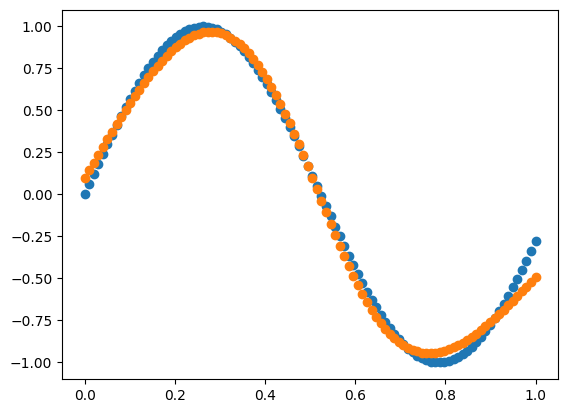

Epoch 3201 of 10000 (32.01%), Loss was 0.03769879901743223
Epoch 3202 of 10000 (32.02%), Loss was 0.07666045715361694
Epoch 3203 of 10000 (32.03%), Loss was 0.187636018211505
Epoch 3204 of 10000 (32.04%), Loss was 0.08796958245158194
Epoch 3205 of 10000 (32.05%), Loss was 0.08173640823085215
Epoch 3206 of 10000 (32.06%), Loss was 0.06695980179732151
Epoch 3207 of 10000 (32.07%), Loss was 0.08609538765626779
Epoch 3208 of 10000 (32.08%), Loss was 0.09652061584121205
Epoch 3209 of 10000 (32.09%), Loss was 0.09008129993169094
Epoch 3210 of 10000 (32.1%), Loss was 0.10486321797685898
Epoch 3211 of 10000 (32.11%), Loss was 0.08036073030580797
Epoch 3212 of 10000 (32.12%), Loss was 0.06316544226040674
Epoch 3213 of 10000 (32.13%), Loss was 0.06036564448785449
Epoch 3214 of 10000 (32.14%), Loss was 0.07719269814985906
Epoch 3215 of 10000 (32.15%), Loss was 0.06489189118496255
Epoch 3216 of 10000 (32.16%), Loss was 0.11160230979265473
Epoch 3217 of 10000 (32.17%), Loss was 0.08927494913681525


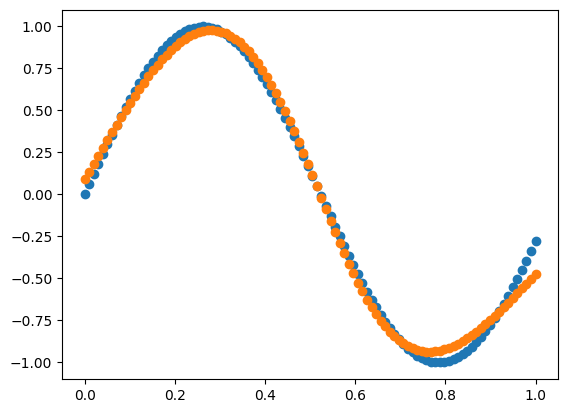

Epoch 3301 of 10000 (33.01%), Loss was 0.06974908711081569
Epoch 3302 of 10000 (33.02%), Loss was 0.11493533077876704
Epoch 3303 of 10000 (33.03%), Loss was 0.08203425945279717
Epoch 3304 of 10000 (33.04%), Loss was 0.08359364224176659
Epoch 3305 of 10000 (33.05%), Loss was 0.051488837162386454
Epoch 3306 of 10000 (33.06%), Loss was 0.11635728705774902
Epoch 3307 of 10000 (33.07%), Loss was 0.1407554506314341
Epoch 3308 of 10000 (33.08%), Loss was 0.056308193842558876
Epoch 3309 of 10000 (33.09%), Loss was 0.08331453574943865
Epoch 3310 of 10000 (33.1%), Loss was 0.11486667432675117
Epoch 3311 of 10000 (33.11%), Loss was 0.06614022220287742
Epoch 3312 of 10000 (33.12%), Loss was 0.0498976380051233
Epoch 3313 of 10000 (33.13%), Loss was 0.09803228195218651
Epoch 3314 of 10000 (33.14%), Loss was 0.06698410738655546
Epoch 3315 of 10000 (33.15%), Loss was 0.05054986008431111
Epoch 3316 of 10000 (33.16%), Loss was 0.053394032374390055
Epoch 3317 of 10000 (33.17%), Loss was 0.086251955350188

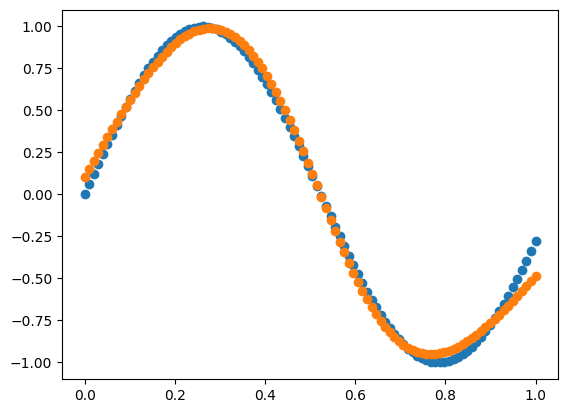

Epoch 3401 of 10000 (34.01%), Loss was 0.04235330015392315
Epoch 3402 of 10000 (34.02%), Loss was 0.060913557166323094
Epoch 3403 of 10000 (34.03%), Loss was 0.05821878560961167
Epoch 3404 of 10000 (34.04%), Loss was 0.10932720783087285
Epoch 3405 of 10000 (34.05%), Loss was 0.04929417976493863
Epoch 3406 of 10000 (34.06%), Loss was 0.06702915089577638
Epoch 3407 of 10000 (34.07%), Loss was 0.06281822669809335
Epoch 3408 of 10000 (34.08%), Loss was 0.05873641829742759
Epoch 3409 of 10000 (34.09%), Loss was 0.10126325755242617
Epoch 3410 of 10000 (34.1%), Loss was 0.06396824590735113
Epoch 3411 of 10000 (34.11%), Loss was 0.07246116598228729
Epoch 3412 of 10000 (34.12%), Loss was 0.07923439045066054
Epoch 3413 of 10000 (34.13%), Loss was 0.06796368960432887
Epoch 3414 of 10000 (34.14%), Loss was 0.06473788855734208
Epoch 3415 of 10000 (34.15%), Loss was 0.04505663676053948
Epoch 3416 of 10000 (34.16%), Loss was 0.08683341354009498
Epoch 3417 of 10000 (34.17%), Loss was 0.079277691628189

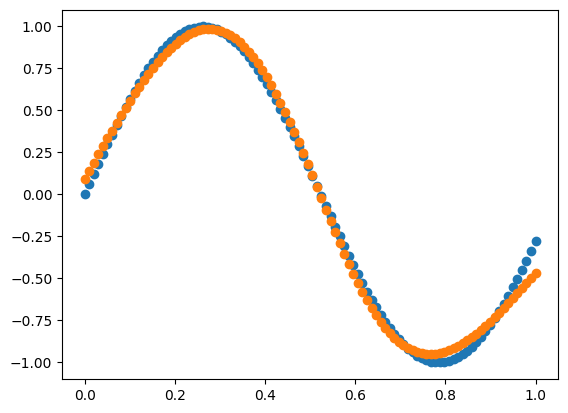

Epoch 3501 of 10000 (35.01%), Loss was 0.13132055566168815
Epoch 3502 of 10000 (35.02%), Loss was 0.07225078414924738
Epoch 3503 of 10000 (35.03%), Loss was 0.05525332468841447
Epoch 3504 of 10000 (35.04%), Loss was 0.03417959654588051
Epoch 3505 of 10000 (35.05%), Loss was 0.0785584466083829
Epoch 3506 of 10000 (35.06%), Loss was 0.056720164808340426
Epoch 3507 of 10000 (35.07%), Loss was 0.07975675075116918
Epoch 3508 of 10000 (35.08%), Loss was 0.058502580623883194
Epoch 3509 of 10000 (35.09%), Loss was 0.07447985388714447
Epoch 3510 of 10000 (35.1%), Loss was 0.05596609208376202
Epoch 3511 of 10000 (35.11%), Loss was 0.10870299110789798
Epoch 3512 of 10000 (35.12%), Loss was 0.04855004011004737
Epoch 3513 of 10000 (35.13%), Loss was 0.043071742150140466
Epoch 3514 of 10000 (35.14%), Loss was 0.051722082488868365
Epoch 3515 of 10000 (35.15%), Loss was 0.05153983659136256
Epoch 3516 of 10000 (35.16%), Loss was 0.06569884968888155
Epoch 3517 of 10000 (35.17%), Loss was 0.0901404972794

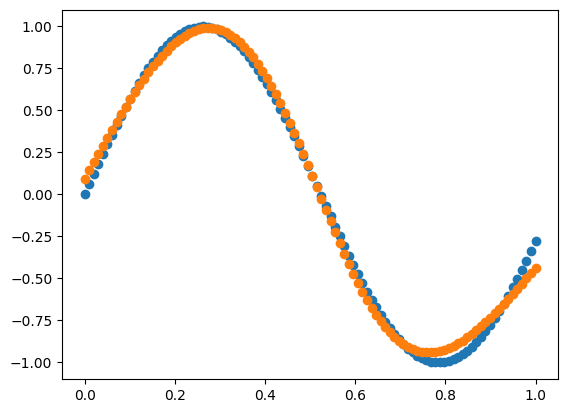

Epoch 3601 of 10000 (36.01%), Loss was 0.037390333193729156
Epoch 3602 of 10000 (36.02%), Loss was 0.044975441016558065
Epoch 3603 of 10000 (36.03%), Loss was 0.08614506181801188
Epoch 3604 of 10000 (36.04%), Loss was 0.06864453946523896
Epoch 3605 of 10000 (36.05%), Loss was 0.046953439247240825
Epoch 3606 of 10000 (36.06%), Loss was 0.09918763526571618
Epoch 3607 of 10000 (36.07%), Loss was 0.07813285335141316
Epoch 3608 of 10000 (36.08%), Loss was 0.042729281146283674
Epoch 3609 of 10000 (36.09%), Loss was 0.04287851140645944
Epoch 3610 of 10000 (36.1%), Loss was 0.05074563880291113
Epoch 3611 of 10000 (36.11%), Loss was 0.11100445623279119
Epoch 3612 of 10000 (36.12%), Loss was 0.03370412475689051
Epoch 3613 of 10000 (36.13%), Loss was 0.07532588454433016
Epoch 3614 of 10000 (36.14%), Loss was 0.06707056663915222
Epoch 3615 of 10000 (36.15%), Loss was 0.058830135924129896
Epoch 3616 of 10000 (36.16%), Loss was 0.05993415201498533
Epoch 3617 of 10000 (36.17%), Loss was 0.05188280732

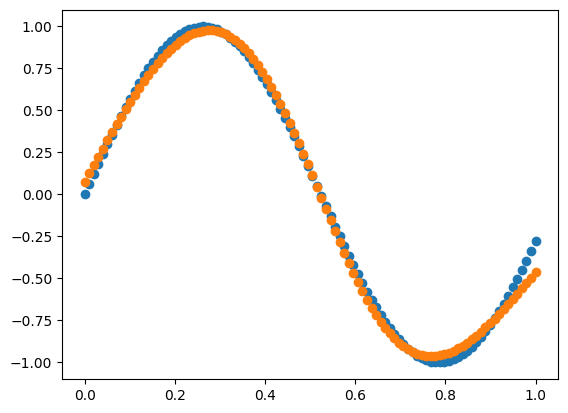

Epoch 3701 of 10000 (37.01%), Loss was 0.059235025475890817
Epoch 3702 of 10000 (37.02%), Loss was 0.04203822721937184
Epoch 3703 of 10000 (37.03%), Loss was 0.08765863781201573
Epoch 3704 of 10000 (37.04%), Loss was 0.03290107987711729
Epoch 3705 of 10000 (37.05%), Loss was 0.03427699457991017
Epoch 3706 of 10000 (37.06%), Loss was 0.06069787126433055
Epoch 3707 of 10000 (37.07%), Loss was 0.04055713606987337
Epoch 3708 of 10000 (37.08%), Loss was 0.06793059978802325
Epoch 3709 of 10000 (37.09%), Loss was 0.054352867717908884
Epoch 3710 of 10000 (37.1%), Loss was 0.07954443392831297
Epoch 3711 of 10000 (37.11%), Loss was 0.04743498357868027
Epoch 3712 of 10000 (37.12%), Loss was 0.07820619727730994
Epoch 3713 of 10000 (37.13%), Loss was 0.0674425375808668
Epoch 3714 of 10000 (37.14%), Loss was 0.04359386830085961
Epoch 3715 of 10000 (37.15%), Loss was 0.07742116165916839
Epoch 3716 of 10000 (37.16%), Loss was 0.041794528412718676
Epoch 3717 of 10000 (37.17%), Loss was 0.05199941236176

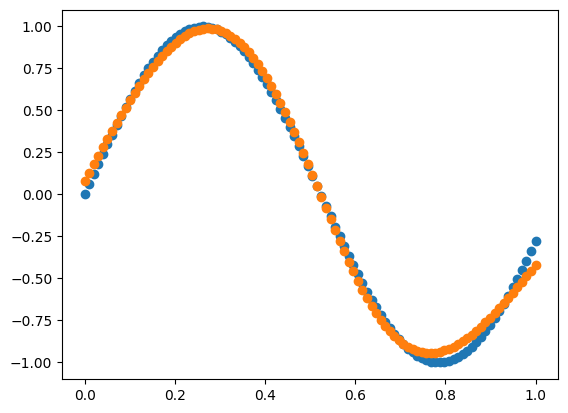

Epoch 3801 of 10000 (38.01%), Loss was 0.056595178549409174
Epoch 3802 of 10000 (38.02%), Loss was 0.030216151828355676
Epoch 3803 of 10000 (38.03%), Loss was 0.04099395315687899
Epoch 3804 of 10000 (38.04%), Loss was 0.054887800278498905
Epoch 3805 of 10000 (38.05%), Loss was 0.03076493282906833
Epoch 3806 of 10000 (38.06%), Loss was 0.04584337698915594
Epoch 3807 of 10000 (38.07%), Loss was 0.07070595456920345
Epoch 3808 of 10000 (38.08%), Loss was 0.05020061727663594
Epoch 3809 of 10000 (38.09%), Loss was 0.040308580660703246
Epoch 3810 of 10000 (38.1%), Loss was 0.05326249884528839
Epoch 3811 of 10000 (38.11%), Loss was 0.03619978003044959
Epoch 3812 of 10000 (38.12%), Loss was 0.05083764156032636
Epoch 3813 of 10000 (38.13%), Loss was 0.04732746299184731
Epoch 3814 of 10000 (38.14%), Loss was 0.048650313133567026
Epoch 3815 of 10000 (38.15%), Loss was 0.07266835286814202
Epoch 3816 of 10000 (38.16%), Loss was 0.05137066606573348
Epoch 3817 of 10000 (38.17%), Loss was 0.03725337427

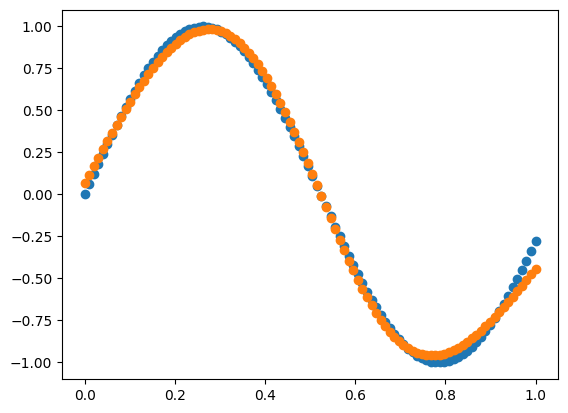

Epoch 3901 of 10000 (39.01%), Loss was 0.05367433157810324
Epoch 3902 of 10000 (39.02%), Loss was 0.03159535654209727
Epoch 3903 of 10000 (39.03%), Loss was 0.023180852735859493
Epoch 3904 of 10000 (39.04%), Loss was 0.031725049223344494
Epoch 3905 of 10000 (39.05%), Loss was 0.053974157538559
Epoch 3906 of 10000 (39.06%), Loss was 0.03949946985752349
Epoch 3907 of 10000 (39.07%), Loss was 0.04000650875711655
Epoch 3908 of 10000 (39.08%), Loss was 0.0682306461390778
Epoch 3909 of 10000 (39.09%), Loss was 0.03759422434621238
Epoch 3910 of 10000 (39.1%), Loss was 0.0359290712741147
Epoch 3911 of 10000 (39.11%), Loss was 0.04630742065444312
Epoch 3912 of 10000 (39.12%), Loss was 0.034579754922167076
Epoch 3913 of 10000 (39.13%), Loss was 0.0839715252477142
Epoch 3914 of 10000 (39.14%), Loss was 0.025695783134837634
Epoch 3915 of 10000 (39.15%), Loss was 0.05350655900085821
Epoch 3916 of 10000 (39.16%), Loss was 0.051064782580516825
Epoch 3917 of 10000 (39.17%), Loss was 0.0439227772791097

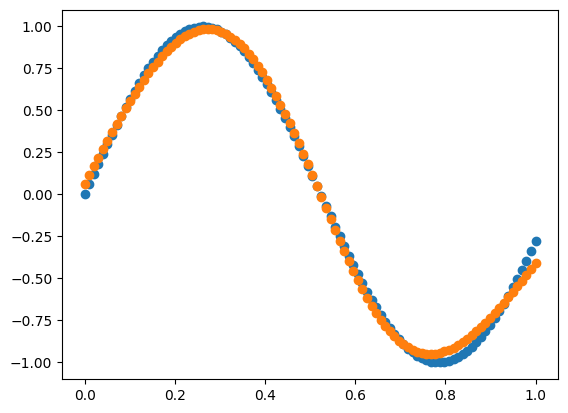

Epoch 4001 of 10000 (40.01%), Loss was 0.04964062039412075
Epoch 4002 of 10000 (40.02%), Loss was 0.03470225013220789
Epoch 4003 of 10000 (40.03%), Loss was 0.04155732791683818
Epoch 4004 of 10000 (40.04%), Loss was 0.052213862846576475
Epoch 4005 of 10000 (40.05%), Loss was 0.029604143575495376
Epoch 4006 of 10000 (40.06%), Loss was 0.052583495773861996
Epoch 4007 of 10000 (40.07%), Loss was 0.043137525001612
Epoch 4008 of 10000 (40.08%), Loss was 0.029163653371963045
Epoch 4009 of 10000 (40.09%), Loss was 0.057935720439574755
Epoch 4010 of 10000 (40.1%), Loss was 0.044536918523004725
Epoch 4011 of 10000 (40.11%), Loss was 0.025570830481864194
Epoch 4012 of 10000 (40.12%), Loss was 0.03148042913254539
Epoch 4013 of 10000 (40.13%), Loss was 0.024898717659074764
Epoch 4014 of 10000 (40.14%), Loss was 0.048711090157854305
Epoch 4015 of 10000 (40.15%), Loss was 0.031296616471234
Epoch 4016 of 10000 (40.16%), Loss was 0.06777496778572895
Epoch 4017 of 10000 (40.17%), Loss was 0.02203496488

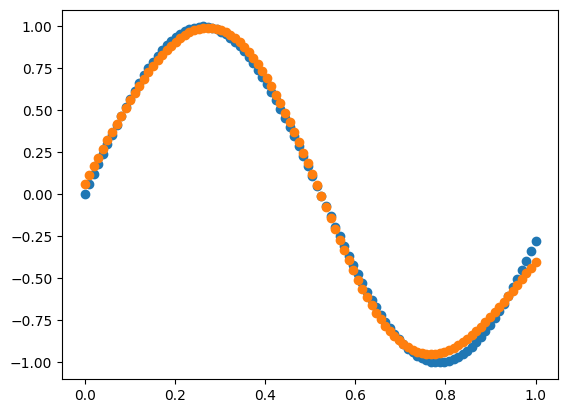

Epoch 4101 of 10000 (41.01%), Loss was 0.03630895514813431
Epoch 4102 of 10000 (41.02%), Loss was 0.03071545435580864
Epoch 4103 of 10000 (41.03%), Loss was 0.033481260634650546
Epoch 4104 of 10000 (41.04%), Loss was 0.04358374554680298
Epoch 4105 of 10000 (41.05%), Loss was 0.024688157941451783
Epoch 4106 of 10000 (41.06%), Loss was 0.044526084879020725
Epoch 4107 of 10000 (41.07%), Loss was 0.0360433729459945
Epoch 4108 of 10000 (41.08%), Loss was 0.0388376382068399
Epoch 4109 of 10000 (41.09%), Loss was 0.04143058882698132
Epoch 4110 of 10000 (41.1%), Loss was 0.03779899402495023
Epoch 4111 of 10000 (41.11%), Loss was 0.02679803083107501
Epoch 4112 of 10000 (41.12%), Loss was 0.036034486803142876
Epoch 4113 of 10000 (41.13%), Loss was 0.030952822028625777
Epoch 4114 of 10000 (41.14%), Loss was 0.032533184589842876
Epoch 4115 of 10000 (41.15%), Loss was 0.04045113769281644
Epoch 4116 of 10000 (41.16%), Loss was 0.024230588405837947
Epoch 4117 of 10000 (41.17%), Loss was 0.03963112380

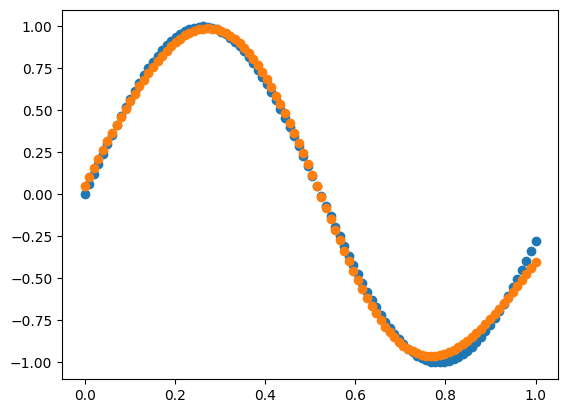

Epoch 4201 of 10000 (42.01%), Loss was 0.021387914080323426
Epoch 4202 of 10000 (42.02%), Loss was 0.03347002091610316
Epoch 4203 of 10000 (42.03%), Loss was 0.05843671028880963
Epoch 4204 of 10000 (42.04%), Loss was 0.03948960927126135
Epoch 4205 of 10000 (42.05%), Loss was 0.040281974390552436
Epoch 4206 of 10000 (42.06%), Loss was 0.04501735829720254
Epoch 4207 of 10000 (42.07%), Loss was 0.03877943632716344
Epoch 4208 of 10000 (42.08%), Loss was 0.03177381586448372
Epoch 4209 of 10000 (42.09%), Loss was 0.031826975095731645
Epoch 4210 of 10000 (42.1%), Loss was 0.029131279691883727
Epoch 4211 of 10000 (42.11%), Loss was 0.027027007855204534
Epoch 4212 of 10000 (42.12%), Loss was 0.04334928779992557
Epoch 4213 of 10000 (42.13%), Loss was 0.02687444910620091
Epoch 4214 of 10000 (42.14%), Loss was 0.028808711836113547
Epoch 4215 of 10000 (42.15%), Loss was 0.029535116243799495
Epoch 4216 of 10000 (42.16%), Loss was 0.01893198960208699
Epoch 4217 of 10000 (42.17%), Loss was 0.046509639

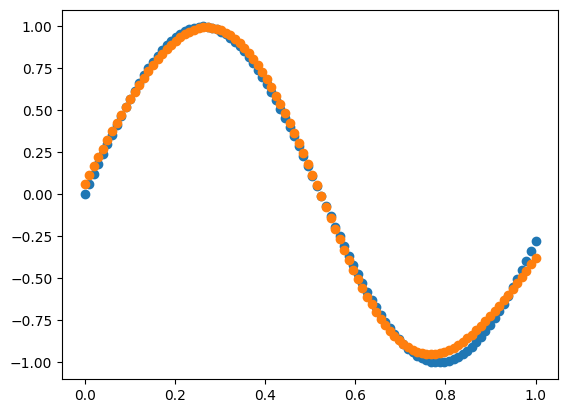

Epoch 4301 of 10000 (43.01%), Loss was 0.03190172412812925
Epoch 4302 of 10000 (43.02%), Loss was 0.03875302835546449
Epoch 4303 of 10000 (43.03%), Loss was 0.021973902696264386
Epoch 4304 of 10000 (43.04%), Loss was 0.025066828121783465
Epoch 4305 of 10000 (43.05%), Loss was 0.032622893683654376
Epoch 4306 of 10000 (43.06%), Loss was 0.03608392059944172
Epoch 4307 of 10000 (43.07%), Loss was 0.022914340226326897
Epoch 4308 of 10000 (43.08%), Loss was 0.052580750363175055
Epoch 4309 of 10000 (43.09%), Loss was 0.024376619177876126
Epoch 4310 of 10000 (43.1%), Loss was 0.026552082799316385
Epoch 4311 of 10000 (43.11%), Loss was 0.030014751210327414
Epoch 4312 of 10000 (43.12%), Loss was 0.020903668985984045
Epoch 4313 of 10000 (43.13%), Loss was 0.018182603770095576
Epoch 4314 of 10000 (43.14%), Loss was 0.02107009044231458
Epoch 4315 of 10000 (43.15%), Loss was 0.041621887303777444
Epoch 4316 of 10000 (43.16%), Loss was 0.03426814655703522
Epoch 4317 of 10000 (43.17%), Loss was 0.02696

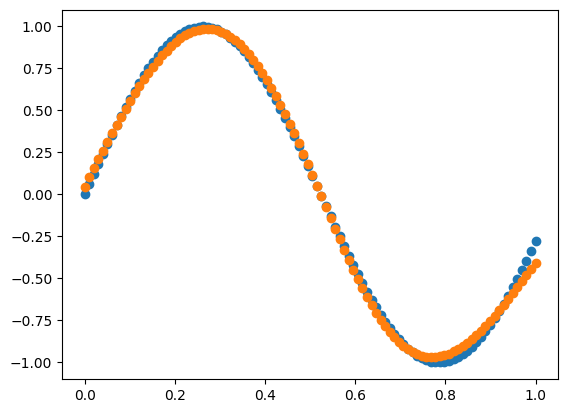

Epoch 4401 of 10000 (44.01%), Loss was 0.023830214719925944
Epoch 4402 of 10000 (44.02%), Loss was 0.020698423654895052
Epoch 4403 of 10000 (44.03%), Loss was 0.03545144664955742
Epoch 4404 of 10000 (44.04%), Loss was 0.01859649168975442
Epoch 4405 of 10000 (44.05%), Loss was 0.022768279979625557
Epoch 4406 of 10000 (44.06%), Loss was 0.03757914183274215
Epoch 4407 of 10000 (44.07%), Loss was 0.0323590585905402
Epoch 4408 of 10000 (44.08%), Loss was 0.026492938117959303
Epoch 4409 of 10000 (44.09%), Loss was 0.03725874799250623
Epoch 4410 of 10000 (44.1%), Loss was 0.02059850373626721
Epoch 4411 of 10000 (44.11%), Loss was 0.04802688274144766
Epoch 4412 of 10000 (44.12%), Loss was 0.018865065480837374
Epoch 4413 of 10000 (44.13%), Loss was 0.0400363086760048
Epoch 4414 of 10000 (44.14%), Loss was 0.01667113061110998
Epoch 4415 of 10000 (44.15%), Loss was 0.025910367970327745
Epoch 4416 of 10000 (44.16%), Loss was 0.027477151130693264
Epoch 4417 of 10000 (44.17%), Loss was 0.03842254384

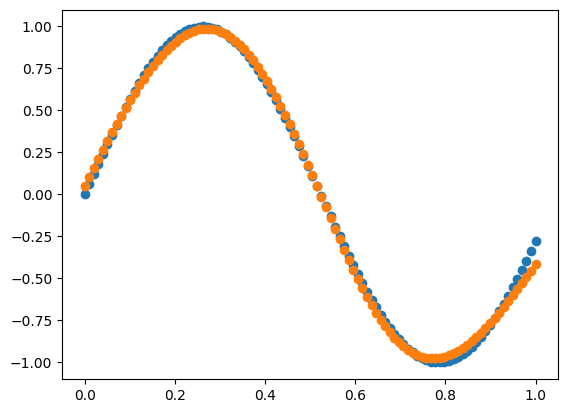

Epoch 4501 of 10000 (45.01%), Loss was 0.05257950083658894
Epoch 4502 of 10000 (45.02%), Loss was 0.028950379446656536
Epoch 4503 of 10000 (45.03%), Loss was 0.023993257591332334
Epoch 4504 of 10000 (45.04%), Loss was 0.03538743898497353
Epoch 4505 of 10000 (45.05%), Loss was 0.025457756679538354
Epoch 4506 of 10000 (45.06%), Loss was 0.01826293933111629
Epoch 4507 of 10000 (45.07%), Loss was 0.0357935989102363
Epoch 4508 of 10000 (45.08%), Loss was 0.03215931886749897
Epoch 4509 of 10000 (45.09%), Loss was 0.038493619389918604
Epoch 4510 of 10000 (45.1%), Loss was 0.02486958169504791
Epoch 4511 of 10000 (45.11%), Loss was 0.031959140213071315
Epoch 4512 of 10000 (45.12%), Loss was 0.01868592039415777
Epoch 4513 of 10000 (45.13%), Loss was 0.016142966987875172
Epoch 4514 of 10000 (45.14%), Loss was 0.02059630491039799
Epoch 4515 of 10000 (45.15%), Loss was 0.015193891635498877
Epoch 4516 of 10000 (45.16%), Loss was 0.014500861841987895
Epoch 4517 of 10000 (45.17%), Loss was 0.030303595

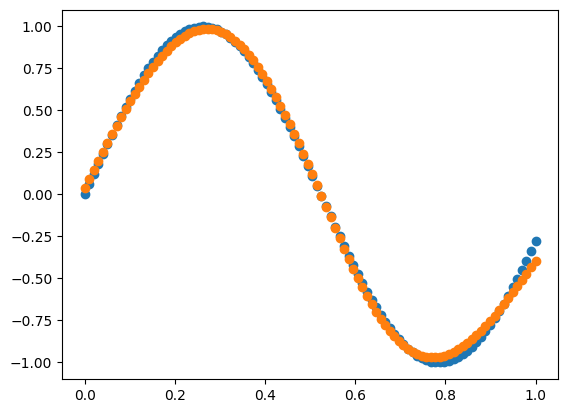

Epoch 4601 of 10000 (46.01%), Loss was 0.01488294688269506
Epoch 4602 of 10000 (46.02%), Loss was 0.012112097249375876
Epoch 4603 of 10000 (46.03%), Loss was 0.010613868795746472
Epoch 4604 of 10000 (46.04%), Loss was 0.012172896825562225
Epoch 4605 of 10000 (46.05%), Loss was 0.03128051315410735
Epoch 4606 of 10000 (46.06%), Loss was 0.01228541918189999
Epoch 4607 of 10000 (46.07%), Loss was 0.012471200630551285
Epoch 4608 of 10000 (46.08%), Loss was 0.01661450813064459
Epoch 4609 of 10000 (46.09%), Loss was 0.03002889293715635
Epoch 4610 of 10000 (46.1%), Loss was 0.027392675917977637
Epoch 4611 of 10000 (46.11%), Loss was 0.019971872169564645
Epoch 4612 of 10000 (46.12%), Loss was 0.01306240726656593
Epoch 4613 of 10000 (46.13%), Loss was 0.02323194510997936
Epoch 4614 of 10000 (46.14%), Loss was 0.017360965814854717
Epoch 4615 of 10000 (46.15%), Loss was 0.017411546882492693
Epoch 4616 of 10000 (46.16%), Loss was 0.028432961978212698
Epoch 4617 of 10000 (46.17%), Loss was 0.0137827

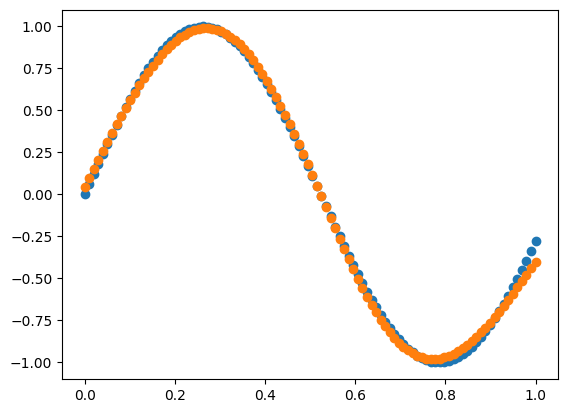

Epoch 4701 of 10000 (47.01%), Loss was 0.01366083189297293
Epoch 4702 of 10000 (47.02%), Loss was 0.02198987494926471
Epoch 4703 of 10000 (47.03%), Loss was 0.01435723733017429
Epoch 4704 of 10000 (47.04%), Loss was 0.02842725506148473
Epoch 4705 of 10000 (47.05%), Loss was 0.021285175689810705
Epoch 4706 of 10000 (47.06%), Loss was 0.015544236315823861
Epoch 4707 of 10000 (47.07%), Loss was 0.01380616783318785
Epoch 4708 of 10000 (47.08%), Loss was 0.0219311054165418
Epoch 4709 of 10000 (47.09%), Loss was 0.024134758226017666
Epoch 4710 of 10000 (47.1%), Loss was 0.019038081366164465
Epoch 4711 of 10000 (47.11%), Loss was 0.027782493940535485
Epoch 4712 of 10000 (47.12%), Loss was 0.02033230861078137
Epoch 4713 of 10000 (47.13%), Loss was 0.008433828348617545
Epoch 4714 of 10000 (47.14%), Loss was 0.026652345857075332
Epoch 4715 of 10000 (47.15%), Loss was 0.019924206821204337
Epoch 4716 of 10000 (47.16%), Loss was 0.01568630370414993
Epoch 4717 of 10000 (47.17%), Loss was 0.035581860

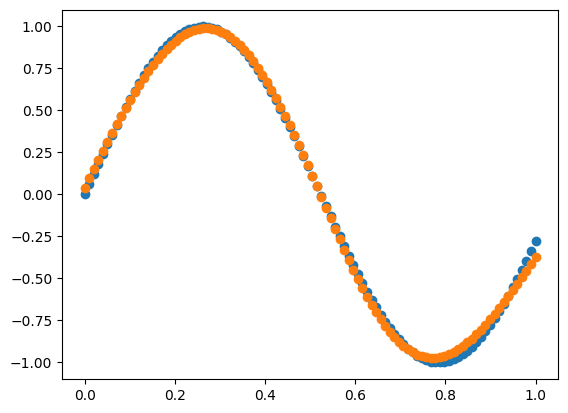

Epoch 4801 of 10000 (48.01%), Loss was 0.016320307765680334
Epoch 4802 of 10000 (48.02%), Loss was 0.02766438429430137
Epoch 4803 of 10000 (48.03%), Loss was 0.01716527713986982
Epoch 4804 of 10000 (48.04%), Loss was 0.015919715202672248
Epoch 4805 of 10000 (48.05%), Loss was 0.01421297054134205
Epoch 4806 of 10000 (48.06%), Loss was 0.01131881925240537
Epoch 4807 of 10000 (48.07%), Loss was 0.018187034542688937
Epoch 4808 of 10000 (48.08%), Loss was 0.012832118890405848
Epoch 4809 of 10000 (48.09%), Loss was 0.01601571014896481
Epoch 4810 of 10000 (48.1%), Loss was 0.02981774746198348
Epoch 4811 of 10000 (48.11%), Loss was 0.04111981769306973
Epoch 4812 of 10000 (48.12%), Loss was 0.04104658914466495
Epoch 4813 of 10000 (48.13%), Loss was 0.01938121978559666
Epoch 4814 of 10000 (48.14%), Loss was 0.01601001989214611
Epoch 4815 of 10000 (48.15%), Loss was 0.020820893174318785
Epoch 4816 of 10000 (48.16%), Loss was 0.02374351509631153
Epoch 4817 of 10000 (48.17%), Loss was 0.01446072744

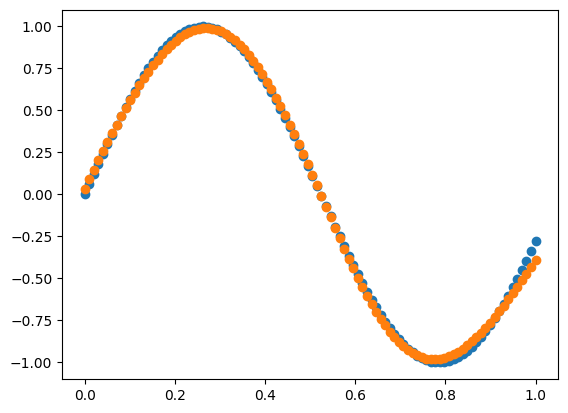

Epoch 4901 of 10000 (49.01%), Loss was 0.011324175126163648
Epoch 4902 of 10000 (49.02%), Loss was 0.010628011919761253
Epoch 4903 of 10000 (49.03%), Loss was 0.011062471634838603
Epoch 4904 of 10000 (49.04%), Loss was 0.011566653551253102
Epoch 4905 of 10000 (49.05%), Loss was 0.010265553997446636
Epoch 4906 of 10000 (49.06%), Loss was 0.021081667319174047
Epoch 4907 of 10000 (49.07%), Loss was 0.01317926763903583
Epoch 4908 of 10000 (49.08%), Loss was 0.024607841167687494
Epoch 4909 of 10000 (49.09%), Loss was 0.006443271181340014
Epoch 4910 of 10000 (49.1%), Loss was 0.021415863434223126
Epoch 4911 of 10000 (49.11%), Loss was 0.012836700936728063
Epoch 4912 of 10000 (49.12%), Loss was 0.01625794315206115
Epoch 4913 of 10000 (49.13%), Loss was 0.025770506463943365
Epoch 4914 of 10000 (49.14%), Loss was 0.01940293510839355
Epoch 4915 of 10000 (49.15%), Loss was 0.009552634949598446
Epoch 4916 of 10000 (49.16%), Loss was 0.012651572595902534
Epoch 4917 of 10000 (49.17%), Loss was 0.015

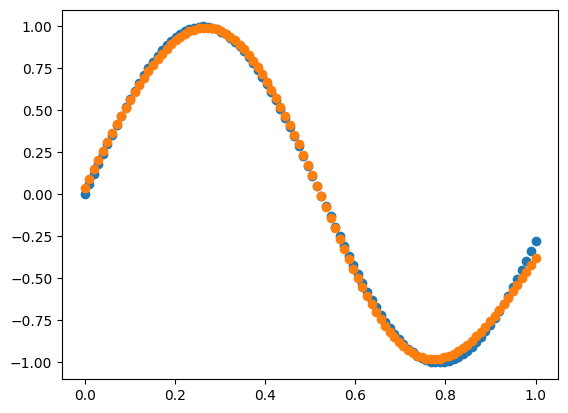

Epoch 5001 of 10000 (50.01%), Loss was 0.014677890351096576
Epoch 5002 of 10000 (50.02%), Loss was 0.007862852424229776
Epoch 5003 of 10000 (50.03%), Loss was 0.012641031168804941
Epoch 5004 of 10000 (50.04%), Loss was 0.009329384078752542
Epoch 5005 of 10000 (50.05%), Loss was 0.01600779383272886
Epoch 5006 of 10000 (50.06%), Loss was 0.005955395686676493
Epoch 5007 of 10000 (50.07%), Loss was 0.009813711526585576
Epoch 5008 of 10000 (50.08%), Loss was 0.0270177454937816
Epoch 5009 of 10000 (50.09%), Loss was 0.022432949260125654
Epoch 5010 of 10000 (50.1%), Loss was 0.014653720397536664
Epoch 5011 of 10000 (50.11%), Loss was 0.010583664683240885
Epoch 5012 of 10000 (50.12%), Loss was 0.013842064852091796
Epoch 5013 of 10000 (50.13%), Loss was 0.018632289826784023
Epoch 5014 of 10000 (50.14%), Loss was 0.013818163583235885
Epoch 5015 of 10000 (50.15%), Loss was 0.017128814964500395
Epoch 5016 of 10000 (50.16%), Loss was 0.015135020862290825
Epoch 5017 of 10000 (50.17%), Loss was 0.022

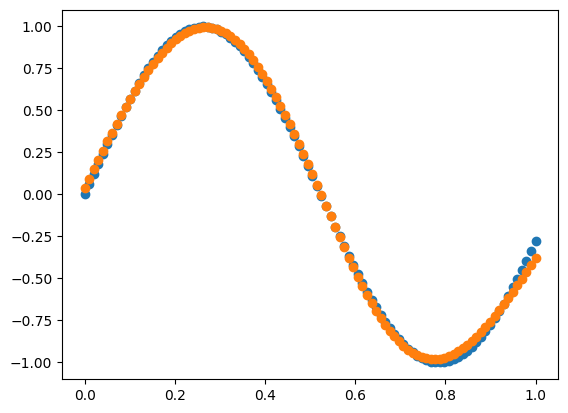

Epoch 5101 of 10000 (51.01%), Loss was 0.022387117570440197
Epoch 5102 of 10000 (51.02%), Loss was 0.028502429090467504
Epoch 5103 of 10000 (51.03%), Loss was 0.014693997871973126
Epoch 5104 of 10000 (51.04%), Loss was 0.014568647990778612
Epoch 5105 of 10000 (51.05%), Loss was 0.013568030637854304
Epoch 5106 of 10000 (51.06%), Loss was 0.023392339690365752
Epoch 5107 of 10000 (51.07%), Loss was 0.015213858288298836
Epoch 5108 of 10000 (51.08%), Loss was 0.008046935816006535
Epoch 5109 of 10000 (51.09%), Loss was 0.013500852862032692
Epoch 5110 of 10000 (51.1%), Loss was 0.017259271618790074
Epoch 5111 of 10000 (51.11%), Loss was 0.011545789566579862
Epoch 5112 of 10000 (51.12%), Loss was 0.024817009553623842
Epoch 5113 of 10000 (51.13%), Loss was 0.004846439627351339
Epoch 5114 of 10000 (51.14%), Loss was 0.012035839774851584
Epoch 5115 of 10000 (51.15%), Loss was 0.012983875855435313
Epoch 5116 of 10000 (51.16%), Loss was 0.014479716931405682
Epoch 5117 of 10000 (51.17%), Loss was 0.

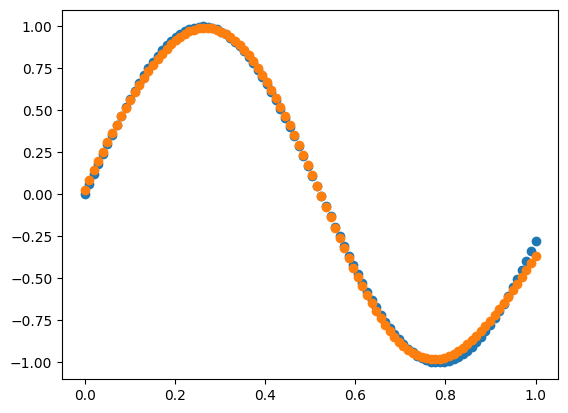

Epoch 5201 of 10000 (52.01%), Loss was 0.014359121785847735
Epoch 5202 of 10000 (52.02%), Loss was 0.01811904605371284
Epoch 5203 of 10000 (52.03%), Loss was 0.015874696309942923
Epoch 5204 of 10000 (52.04%), Loss was 0.012736688893771374
Epoch 5205 of 10000 (52.05%), Loss was 0.01732825181119909
Epoch 5206 of 10000 (52.06%), Loss was 0.010617173402767249
Epoch 5207 of 10000 (52.07%), Loss was 0.015320177968873621
Epoch 5208 of 10000 (52.08%), Loss was 0.015833400602835654
Epoch 5209 of 10000 (52.09%), Loss was 0.008806790652422918
Epoch 5210 of 10000 (52.1%), Loss was 0.0075340189648995005
Epoch 5211 of 10000 (52.11%), Loss was 0.007272021228460257
Epoch 5212 of 10000 (52.12%), Loss was 0.013048841341118621
Epoch 5213 of 10000 (52.13%), Loss was 0.013997782757155594
Epoch 5214 of 10000 (52.14%), Loss was 0.014823196036258863
Epoch 5215 of 10000 (52.15%), Loss was 0.009408494510906003
Epoch 5216 of 10000 (52.16%), Loss was 0.012025224446087869
Epoch 5217 of 10000 (52.17%), Loss was 0.0

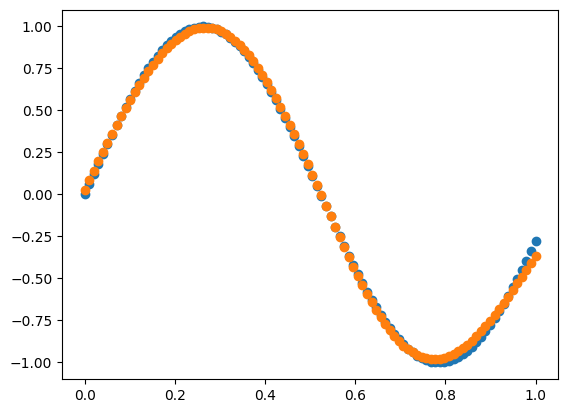

Epoch 5301 of 10000 (53.01%), Loss was 0.016447619243478182
Epoch 5302 of 10000 (53.02%), Loss was 0.007903064336416203
Epoch 5303 of 10000 (53.03%), Loss was 0.009448400542628597
Epoch 5304 of 10000 (53.04%), Loss was 0.016322966353315267
Epoch 5305 of 10000 (53.05%), Loss was 0.0074434597005737495
Epoch 5306 of 10000 (53.06%), Loss was 0.026570000262347425
Epoch 5307 of 10000 (53.07%), Loss was 0.012283208027513181
Epoch 5308 of 10000 (53.08%), Loss was 0.005481018608352251
Epoch 5309 of 10000 (53.09%), Loss was 0.016686314412431392
Epoch 5310 of 10000 (53.1%), Loss was 0.011642439389712815
Epoch 5311 of 10000 (53.11%), Loss was 0.01340786914630192
Epoch 5312 of 10000 (53.12%), Loss was 0.011720966468043126
Epoch 5313 of 10000 (53.13%), Loss was 0.016470409006725632
Epoch 5314 of 10000 (53.14%), Loss was 0.012415064752274645
Epoch 5315 of 10000 (53.15%), Loss was 0.016853902350902433
Epoch 5316 of 10000 (53.16%), Loss was 0.01253303438891483
Epoch 5317 of 10000 (53.17%), Loss was 0.0

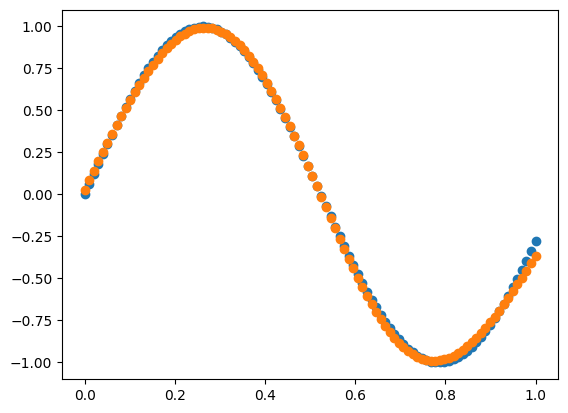

Epoch 5401 of 10000 (54.01%), Loss was 0.009228634459815572
Epoch 5402 of 10000 (54.02%), Loss was 0.007913962039551034
Epoch 5403 of 10000 (54.03%), Loss was 0.014179719659987655
Epoch 5404 of 10000 (54.04%), Loss was 0.010763273741392503
Epoch 5405 of 10000 (54.05%), Loss was 0.016125189569059888
Epoch 5406 of 10000 (54.06%), Loss was 0.010419758191308626
Epoch 5407 of 10000 (54.07%), Loss was 0.016660439074614633
Epoch 5408 of 10000 (54.08%), Loss was 0.008900934556810531
Epoch 5409 of 10000 (54.09%), Loss was 0.00657342947089039
Epoch 5410 of 10000 (54.1%), Loss was 0.009859517227407471
Epoch 5411 of 10000 (54.11%), Loss was 0.008204842580968253
Epoch 5412 of 10000 (54.12%), Loss was 0.009859387430067106
Epoch 5413 of 10000 (54.13%), Loss was 0.006372041626678855
Epoch 5414 of 10000 (54.14%), Loss was 0.006397395092933853
Epoch 5415 of 10000 (54.15%), Loss was 0.006340539315948892
Epoch 5416 of 10000 (54.16%), Loss was 0.004517424226672508
Epoch 5417 of 10000 (54.17%), Loss was 0.0

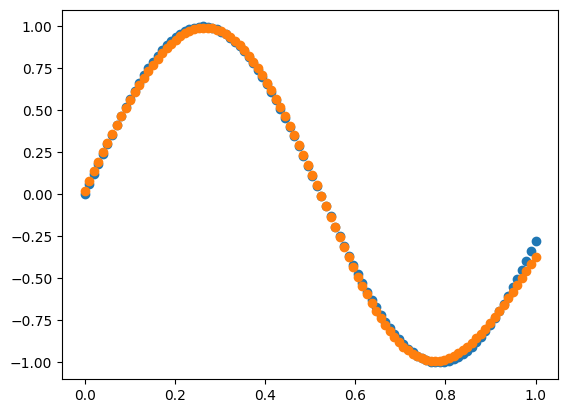

Epoch 5501 of 10000 (55.01%), Loss was 0.008097333875085006
Epoch 5502 of 10000 (55.02%), Loss was 0.006017103481117642
Epoch 5503 of 10000 (55.03%), Loss was 0.005904854053605371
Epoch 5504 of 10000 (55.04%), Loss was 0.0036790118320946252
Epoch 5505 of 10000 (55.05%), Loss was 0.00776702784821336
Epoch 5506 of 10000 (55.06%), Loss was 0.00967663215422331
Epoch 5507 of 10000 (55.07%), Loss was 0.006211737843101273
Epoch 5508 of 10000 (55.08%), Loss was 0.021661722136412792
Epoch 5509 of 10000 (55.09%), Loss was 0.008966414123753694
Epoch 5510 of 10000 (55.1%), Loss was 0.005500971162594758
Epoch 5511 of 10000 (55.11%), Loss was 0.0058884816774308945
Epoch 5512 of 10000 (55.12%), Loss was 0.006154791082046815
Epoch 5513 of 10000 (55.13%), Loss was 0.005929025105497319
Epoch 5514 of 10000 (55.14%), Loss was 0.015541710184244538
Epoch 5515 of 10000 (55.15%), Loss was 0.0033634952496960566
Epoch 5516 of 10000 (55.16%), Loss was 0.0030808064260642127
Epoch 5517 of 10000 (55.17%), Loss was 

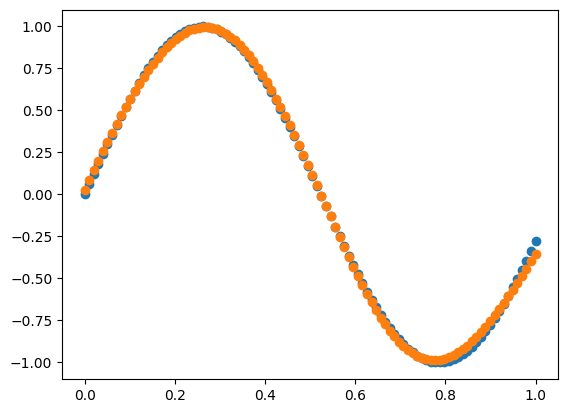

Epoch 5601 of 10000 (56.01%), Loss was 0.0037945304069919696
Epoch 5602 of 10000 (56.02%), Loss was 0.005427222145511237
Epoch 5603 of 10000 (56.03%), Loss was 0.00756650015280232
Epoch 5604 of 10000 (56.04%), Loss was 0.011586120282978583
Epoch 5605 of 10000 (56.05%), Loss was 0.012851691777547553
Epoch 5606 of 10000 (56.06%), Loss was 0.004964765195445294
Epoch 5607 of 10000 (56.07%), Loss was 0.009556450098669317
Epoch 5608 of 10000 (56.08%), Loss was 0.010235598110662983
Epoch 5609 of 10000 (56.09%), Loss was 0.006057857498812519
Epoch 5610 of 10000 (56.1%), Loss was 0.007851024633497605
Epoch 5611 of 10000 (56.11%), Loss was 0.007125596791492501
Epoch 5612 of 10000 (56.12%), Loss was 0.0101197894793373
Epoch 5613 of 10000 (56.13%), Loss was 0.006443346209331573
Epoch 5614 of 10000 (56.14%), Loss was 0.007752593540821681
Epoch 5615 of 10000 (56.15%), Loss was 0.0073879897761997965
Epoch 5616 of 10000 (56.16%), Loss was 0.003752738314986523
Epoch 5617 of 10000 (56.17%), Loss was 0.0

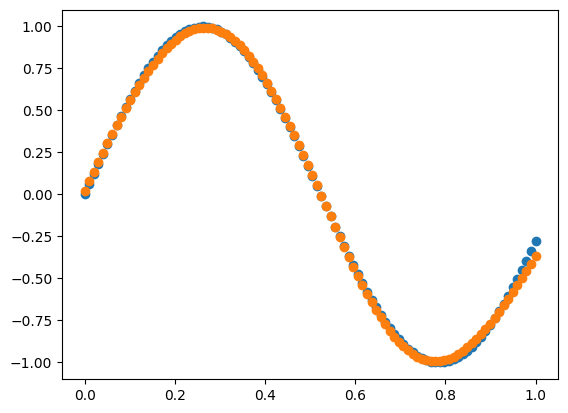

Epoch 5701 of 10000 (57.01%), Loss was 0.006864469962621122
Epoch 5702 of 10000 (57.02%), Loss was 0.003040665056248937
Epoch 5703 of 10000 (57.03%), Loss was 0.015165853784251136
Epoch 5704 of 10000 (57.04%), Loss was 0.006518630318695693
Epoch 5705 of 10000 (57.05%), Loss was 0.004232471973034917
Epoch 5706 of 10000 (57.06%), Loss was 0.007849698500588994
Epoch 5707 of 10000 (57.07%), Loss was 0.0072185000220908735
Epoch 5708 of 10000 (57.08%), Loss was 0.007403210425671865
Epoch 5709 of 10000 (57.09%), Loss was 0.01041736065164531
Epoch 5710 of 10000 (57.1%), Loss was 0.003380713626265651
Epoch 5711 of 10000 (57.11%), Loss was 0.005809260711375233
Epoch 5712 of 10000 (57.12%), Loss was 0.0026423140082020083
Epoch 5713 of 10000 (57.13%), Loss was 0.00593332979613693
Epoch 5714 of 10000 (57.14%), Loss was 0.0038095964087489754
Epoch 5715 of 10000 (57.15%), Loss was 0.007197515098531904
Epoch 5716 of 10000 (57.16%), Loss was 0.003004496792279726
Epoch 5717 of 10000 (57.17%), Loss was 0

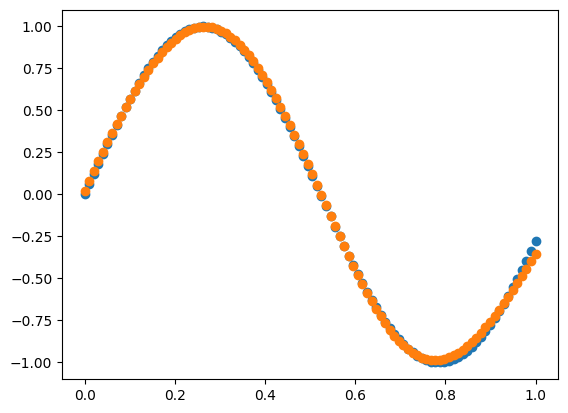

Epoch 5801 of 10000 (58.01%), Loss was 0.010909163883584304
Epoch 5802 of 10000 (58.02%), Loss was 0.004528747721926462
Epoch 5803 of 10000 (58.03%), Loss was 0.008749103282694608
Epoch 5804 of 10000 (58.04%), Loss was 0.007965598031944486
Epoch 5805 of 10000 (58.05%), Loss was 0.006124126807386968
Epoch 5806 of 10000 (58.06%), Loss was 0.007236765821125237
Epoch 5807 of 10000 (58.07%), Loss was 0.006211851204885023
Epoch 5808 of 10000 (58.08%), Loss was 0.009886224112329657
Epoch 5809 of 10000 (58.09%), Loss was 0.010949272191049287
Epoch 5810 of 10000 (58.1%), Loss was 0.006857052412741416
Epoch 5811 of 10000 (58.11%), Loss was 0.010889748896857045
Epoch 5812 of 10000 (58.12%), Loss was 0.004228276925955414
Epoch 5813 of 10000 (58.13%), Loss was 0.015637744661244655
Epoch 5814 of 10000 (58.14%), Loss was 0.012338992950075664
Epoch 5815 of 10000 (58.15%), Loss was 0.003468538387051879
Epoch 5816 of 10000 (58.16%), Loss was 0.003139150388696792
Epoch 5817 of 10000 (58.17%), Loss was 0.

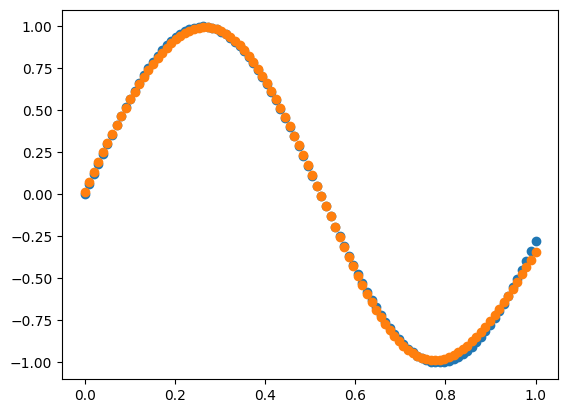

Epoch 5901 of 10000 (59.01%), Loss was 0.0029438602118566225
Epoch 5902 of 10000 (59.02%), Loss was 0.009069979690471288
Epoch 5903 of 10000 (59.03%), Loss was 0.005639403919467027
Epoch 5904 of 10000 (59.04%), Loss was 0.004607110981076579
Epoch 5905 of 10000 (59.05%), Loss was 0.003419041287267434
Epoch 5906 of 10000 (59.06%), Loss was 0.003118182666829484
Epoch 5907 of 10000 (59.07%), Loss was 0.003902266538095429
Epoch 5908 of 10000 (59.08%), Loss was 0.00844231174905045
Epoch 5909 of 10000 (59.09%), Loss was 0.00468751787267924
Epoch 5910 of 10000 (59.1%), Loss was 0.010897973900022886
Epoch 5911 of 10000 (59.11%), Loss was 0.005472289405750917
Epoch 5912 of 10000 (59.12%), Loss was 0.008655825613825326
Epoch 5913 of 10000 (59.13%), Loss was 0.0031783783785708556
Epoch 5914 of 10000 (59.14%), Loss was 0.005295455068747295
Epoch 5915 of 10000 (59.15%), Loss was 0.006942375117130805
Epoch 5916 of 10000 (59.16%), Loss was 0.006280554313006271
Epoch 5917 of 10000 (59.17%), Loss was 0.

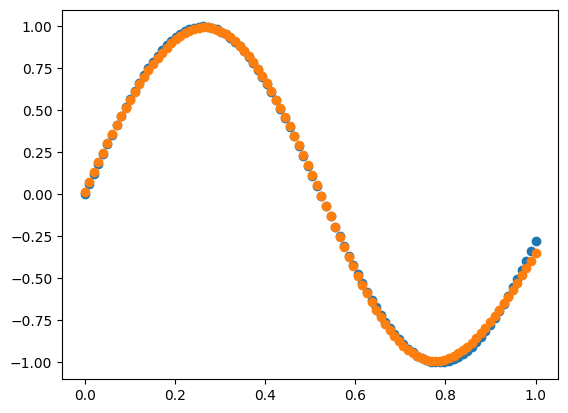

Epoch 6001 of 10000 (60.01%), Loss was 0.004298990863840605
Epoch 6002 of 10000 (60.02%), Loss was 0.010021919782037113
Epoch 6003 of 10000 (60.03%), Loss was 0.00669911400538495
Epoch 6004 of 10000 (60.04%), Loss was 0.0039194250483727535
Epoch 6005 of 10000 (60.05%), Loss was 0.004337034423944401
Epoch 6006 of 10000 (60.06%), Loss was 0.008254266722526042
Epoch 6007 of 10000 (60.07%), Loss was 0.001816337661420889
Epoch 6008 of 10000 (60.08%), Loss was 0.006278202729285558
Epoch 6009 of 10000 (60.09%), Loss was 0.013632179031168189
Epoch 6010 of 10000 (60.1%), Loss was 0.004365597874888999
Epoch 6011 of 10000 (60.11%), Loss was 0.009607546258757552
Epoch 6012 of 10000 (60.12%), Loss was 0.004688421660868594
Epoch 6013 of 10000 (60.13%), Loss was 0.013504305168053751
Epoch 6014 of 10000 (60.14%), Loss was 0.00824699537561594
Epoch 6015 of 10000 (60.15%), Loss was 0.004320729054037476
Epoch 6016 of 10000 (60.16%), Loss was 0.0069026694215929526
Epoch 6017 of 10000 (60.17%), Loss was 0.

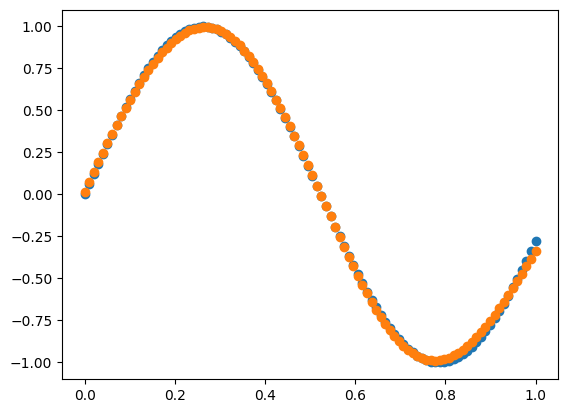

Epoch 6101 of 10000 (61.01%), Loss was 0.005755603042084685
Epoch 6102 of 10000 (61.02%), Loss was 0.004989615924869419
Epoch 6103 of 10000 (61.03%), Loss was 0.003432151483035861
Epoch 6104 of 10000 (61.04%), Loss was 0.007993451413880673
Epoch 6105 of 10000 (61.05%), Loss was 0.007880683787087691
Epoch 6106 of 10000 (61.06%), Loss was 0.002783469922470795
Epoch 6107 of 10000 (61.07%), Loss was 0.0029758878393708727
Epoch 6108 of 10000 (61.08%), Loss was 0.005306702940675705
Epoch 6109 of 10000 (61.09%), Loss was 0.001747913145094494
Epoch 6110 of 10000 (61.1%), Loss was 0.0034871054728470127
Epoch 6111 of 10000 (61.11%), Loss was 0.004028366554497888
Epoch 6112 of 10000 (61.12%), Loss was 0.008307323796557872
Epoch 6113 of 10000 (61.13%), Loss was 0.004548928771079663
Epoch 6114 of 10000 (61.14%), Loss was 0.008266429172450683
Epoch 6115 of 10000 (61.15%), Loss was 0.0042898525000030175
Epoch 6116 of 10000 (61.16%), Loss was 0.0025254105144848294
Epoch 6117 of 10000 (61.17%), Loss wa

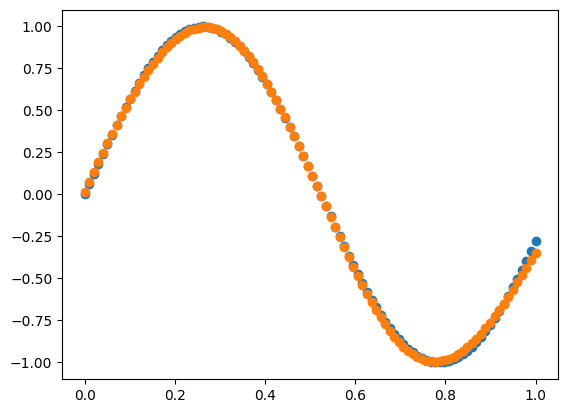

Epoch 6201 of 10000 (62.01%), Loss was 0.003320382421959933
Epoch 6202 of 10000 (62.02%), Loss was 0.0029312396492868174
Epoch 6203 of 10000 (62.03%), Loss was 0.004354842410780322
Epoch 6204 of 10000 (62.04%), Loss was 0.0018793933204986244
Epoch 6205 of 10000 (62.05%), Loss was 0.007324107118166472
Epoch 6206 of 10000 (62.06%), Loss was 0.0031531855160145178
Epoch 6207 of 10000 (62.07%), Loss was 0.002496360626934732
Epoch 6208 of 10000 (62.08%), Loss was 0.002877611543684454
Epoch 6209 of 10000 (62.09%), Loss was 0.003181078622818737
Epoch 6210 of 10000 (62.1%), Loss was 0.004017749622378248
Epoch 6211 of 10000 (62.11%), Loss was 0.007939429826735215
Epoch 6212 of 10000 (62.12%), Loss was 0.0023358272135339986
Epoch 6213 of 10000 (62.13%), Loss was 0.003351022692007255
Epoch 6214 of 10000 (62.14%), Loss was 0.005192900402929891
Epoch 6215 of 10000 (62.15%), Loss was 0.00491119309619856
Epoch 6216 of 10000 (62.16%), Loss was 0.0026819153192390475
Epoch 6217 of 10000 (62.17%), Loss wa

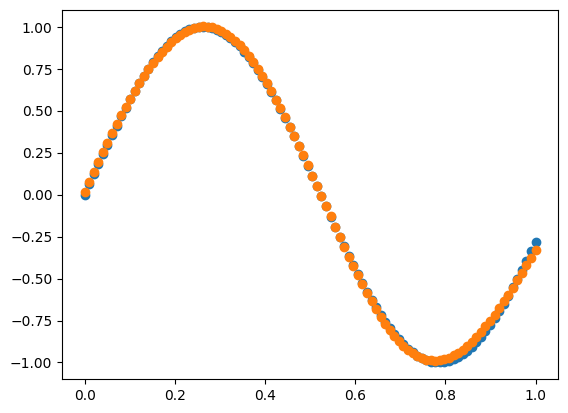

Epoch 6301 of 10000 (63.01%), Loss was 0.003217792456359629
Epoch 6302 of 10000 (63.02%), Loss was 0.008819607961774063
Epoch 6303 of 10000 (63.03%), Loss was 0.007348111512981223
Epoch 6304 of 10000 (63.04%), Loss was 0.003996124725296933
Epoch 6305 of 10000 (63.05%), Loss was 0.0031453495672358178
Epoch 6306 of 10000 (63.06%), Loss was 0.0062232204334853195
Epoch 6307 of 10000 (63.07%), Loss was 0.005484914143904556
Epoch 6308 of 10000 (63.08%), Loss was 0.0032889885980882834
Epoch 6309 of 10000 (63.09%), Loss was 0.0020876388469092074
Epoch 6310 of 10000 (63.1%), Loss was 0.0050467095329392924
Epoch 6311 of 10000 (63.11%), Loss was 0.008407039777814252
Epoch 6312 of 10000 (63.12%), Loss was 0.0020974311142857253
Epoch 6313 of 10000 (63.13%), Loss was 0.001567611668089483
Epoch 6314 of 10000 (63.14%), Loss was 0.0037919621863113564
Epoch 6315 of 10000 (63.15%), Loss was 0.004437626331266753
Epoch 6316 of 10000 (63.16%), Loss was 0.005647334890828949
Epoch 6317 of 10000 (63.17%), Loss

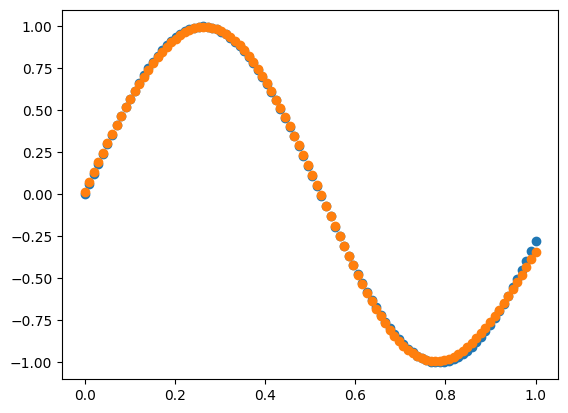

Epoch 6401 of 10000 (64.01%), Loss was 0.004024851603943308
Epoch 6402 of 10000 (64.02%), Loss was 0.0019745196034802195
Epoch 6403 of 10000 (64.03%), Loss was 0.0027125370834341863
Epoch 6404 of 10000 (64.04%), Loss was 0.006431047969012695
Epoch 6405 of 10000 (64.05%), Loss was 0.002649184243686477
Epoch 6406 of 10000 (64.06%), Loss was 0.002292021866414352
Epoch 6407 of 10000 (64.07%), Loss was 0.00386164746201376
Epoch 6408 of 10000 (64.08%), Loss was 0.0025796966724920887
Epoch 6409 of 10000 (64.09%), Loss was 0.004566269648899817
Epoch 6410 of 10000 (64.1%), Loss was 0.0054125813232966035
Epoch 6411 of 10000 (64.11%), Loss was 0.002895142594306966
Epoch 6412 of 10000 (64.12%), Loss was 0.00416458925898641
Epoch 6413 of 10000 (64.13%), Loss was 0.002549629267558696
Epoch 6414 of 10000 (64.14%), Loss was 0.005696497834309587
Epoch 6415 of 10000 (64.15%), Loss was 0.002211319033758274
Epoch 6416 of 10000 (64.16%), Loss was 0.005359153854986049
Epoch 6417 of 10000 (64.17%), Loss was 

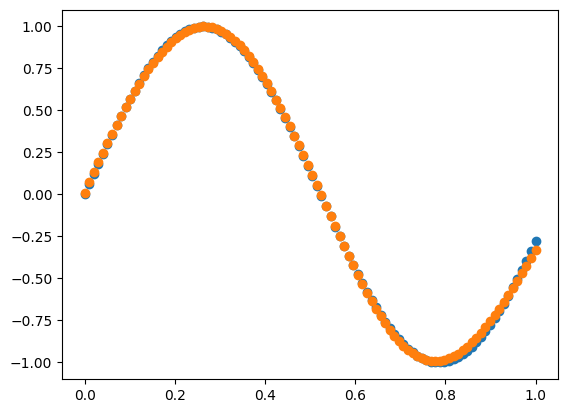

Epoch 6501 of 10000 (65.01%), Loss was 0.004200363635209649
Epoch 6502 of 10000 (65.02%), Loss was 0.0030496825743107966
Epoch 6503 of 10000 (65.03%), Loss was 0.006570737611434302
Epoch 6504 of 10000 (65.04%), Loss was 0.002521355258117885
Epoch 6505 of 10000 (65.05%), Loss was 0.0046271964576691076
Epoch 6506 of 10000 (65.06%), Loss was 0.003946896257126361
Epoch 6507 of 10000 (65.07%), Loss was 0.007294503026239662
Epoch 6508 of 10000 (65.08%), Loss was 0.006666574586065343
Epoch 6509 of 10000 (65.09%), Loss was 0.004687476516615602
Epoch 6510 of 10000 (65.1%), Loss was 0.0034505674366636834
Epoch 6511 of 10000 (65.11%), Loss was 0.0017293975710778733
Epoch 6512 of 10000 (65.12%), Loss was 0.0033075169985046005
Epoch 6513 of 10000 (65.13%), Loss was 0.002353124371525495
Epoch 6514 of 10000 (65.14%), Loss was 0.002149114441404439
Epoch 6515 of 10000 (65.15%), Loss was 0.005286935196268873
Epoch 6516 of 10000 (65.16%), Loss was 0.0029523318855802843
Epoch 6517 of 10000 (65.17%), Loss 

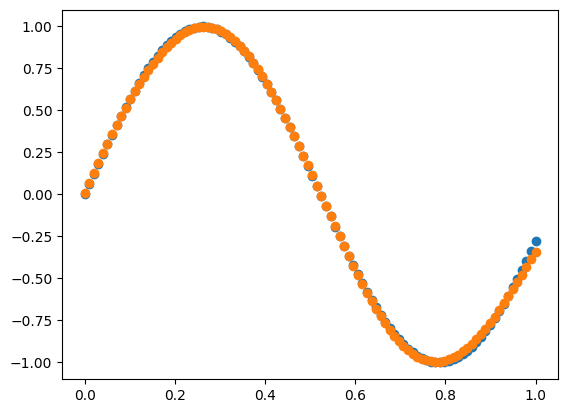

Epoch 6601 of 10000 (66.01%), Loss was 0.0031992546578270076
Epoch 6602 of 10000 (66.02%), Loss was 0.0013643473610504186
Epoch 6603 of 10000 (66.03%), Loss was 0.0026794785105496675
Epoch 6604 of 10000 (66.04%), Loss was 0.010437273152131997
Epoch 6605 of 10000 (66.05%), Loss was 0.004708226253287548
Epoch 6606 of 10000 (66.06%), Loss was 0.004244274381405524
Epoch 6607 of 10000 (66.07%), Loss was 0.0019442462230593372
Epoch 6608 of 10000 (66.08%), Loss was 0.0026544243591085544
Epoch 6609 of 10000 (66.09%), Loss was 0.002683598719866017
Epoch 6610 of 10000 (66.1%), Loss was 0.004392169837425086
Epoch 6611 of 10000 (66.11%), Loss was 0.002313976789888542
Epoch 6612 of 10000 (66.12%), Loss was 0.0030975187427008262
Epoch 6613 of 10000 (66.13%), Loss was 0.0019433630873790994
Epoch 6614 of 10000 (66.14%), Loss was 0.0019092662776833036
Epoch 6615 of 10000 (66.15%), Loss was 0.00271977063549737
Epoch 6616 of 10000 (66.16%), Loss was 0.004063811855742879
Epoch 6617 of 10000 (66.17%), Loss

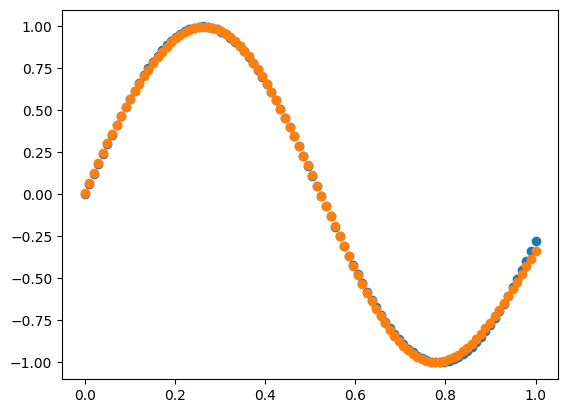

Epoch 6701 of 10000 (67.01%), Loss was 0.001405826039568632
Epoch 6702 of 10000 (67.02%), Loss was 0.0017328506196355531
Epoch 6703 of 10000 (67.03%), Loss was 0.004068647842846935
Epoch 6704 of 10000 (67.04%), Loss was 0.001339900637680366
Epoch 6705 of 10000 (67.05%), Loss was 0.00500762551674777
Epoch 6706 of 10000 (67.06%), Loss was 0.002878528113092633
Epoch 6707 of 10000 (67.07%), Loss was 0.004574814130272388
Epoch 6708 of 10000 (67.08%), Loss was 0.008706873934170557
Epoch 6709 of 10000 (67.09%), Loss was 0.003132986998250868
Epoch 6710 of 10000 (67.1%), Loss was 0.004144556996394765
Epoch 6711 of 10000 (67.11%), Loss was 0.004242771325267086
Epoch 6712 of 10000 (67.12%), Loss was 0.0038680441402949564
Epoch 6713 of 10000 (67.13%), Loss was 0.00234844323893251
Epoch 6714 of 10000 (67.14%), Loss was 0.0033409946604824057
Epoch 6715 of 10000 (67.15%), Loss was 0.002025982521910785
Epoch 6716 of 10000 (67.16%), Loss was 0.006323649511668575
Epoch 6717 of 10000 (67.17%), Loss was 0

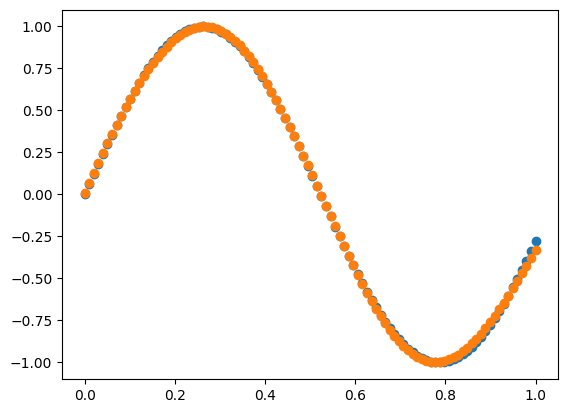

Epoch 6801 of 10000 (68.01%), Loss was 0.004313917332508248
Epoch 6802 of 10000 (68.02%), Loss was 0.0013595171364851322
Epoch 6803 of 10000 (68.03%), Loss was 0.005063230078293272
Epoch 6804 of 10000 (68.04%), Loss was 0.0024959341361767903
Epoch 6805 of 10000 (68.05%), Loss was 0.0016594691431255732
Epoch 6806 of 10000 (68.06%), Loss was 0.004572518825045463
Epoch 6807 of 10000 (68.07%), Loss was 0.003083222617502368
Epoch 6808 of 10000 (68.08%), Loss was 0.001308555391739719
Epoch 6809 of 10000 (68.09%), Loss was 0.0029547867510759033
Epoch 6810 of 10000 (68.1%), Loss was 0.0034455117741841886
Epoch 6811 of 10000 (68.11%), Loss was 0.0016727462282727754
Epoch 6812 of 10000 (68.12%), Loss was 0.0025388901193971304
Epoch 6813 of 10000 (68.13%), Loss was 0.005401900431313992
Epoch 6814 of 10000 (68.14%), Loss was 0.004700552986098466
Epoch 6815 of 10000 (68.15%), Loss was 0.0018828786524864828
Epoch 6816 of 10000 (68.16%), Loss was 0.0024342328287114707
Epoch 6817 of 10000 (68.17%), Lo

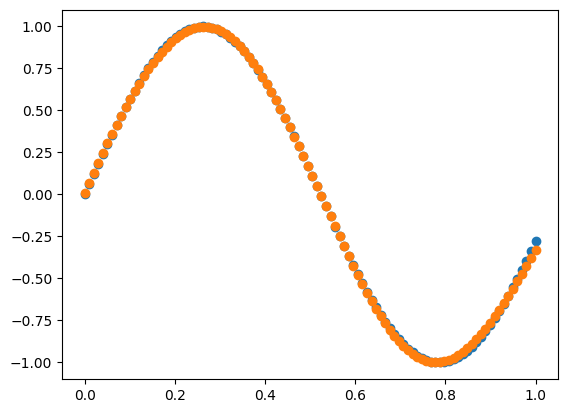

Epoch 6901 of 10000 (69.01%), Loss was 0.0018189454380756274
Epoch 6902 of 10000 (69.02%), Loss was 0.004412377613661546
Epoch 6903 of 10000 (69.03%), Loss was 0.0020516780153993133
Epoch 6904 of 10000 (69.04%), Loss was 0.0023398572559551888
Epoch 6905 of 10000 (69.05%), Loss was 0.0021485911277223262
Epoch 6906 of 10000 (69.06%), Loss was 0.0011424727520747398
Epoch 6907 of 10000 (69.07%), Loss was 0.0033022243000975305
Epoch 6908 of 10000 (69.08%), Loss was 0.0027726420324238827
Epoch 6909 of 10000 (69.09%), Loss was 0.0007783851367013514
Epoch 6910 of 10000 (69.1%), Loss was 0.0014225858074717608
Epoch 6911 of 10000 (69.11%), Loss was 0.004870269090567972
Epoch 6912 of 10000 (69.12%), Loss was 0.0025287960663916264
Epoch 6913 of 10000 (69.13%), Loss was 0.003536852946369593
Epoch 6914 of 10000 (69.14%), Loss was 0.00416520151922789
Epoch 6915 of 10000 (69.15%), Loss was 0.002794688658839801
Epoch 6916 of 10000 (69.16%), Loss was 0.0014045106058478579
Epoch 6917 of 10000 (69.17%), L

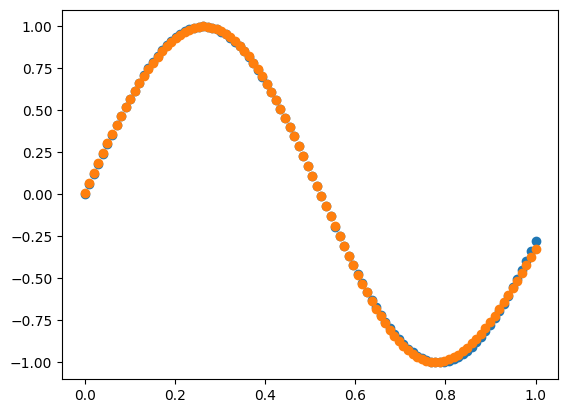

Epoch 7001 of 10000 (70.01%), Loss was 0.001575923905158891
Epoch 7002 of 10000 (70.02%), Loss was 0.001059025169866504
Epoch 7003 of 10000 (70.03%), Loss was 0.0009910683252629653
Epoch 7004 of 10000 (70.04%), Loss was 0.003372952039399442
Epoch 7005 of 10000 (70.05%), Loss was 0.00562055461493479
Epoch 7006 of 10000 (70.06%), Loss was 0.002488576829077756
Epoch 7007 of 10000 (70.07%), Loss was 0.0030144127239909555
Epoch 7008 of 10000 (70.08%), Loss was 0.002045885621127103
Epoch 7009 of 10000 (70.09%), Loss was 0.0016184327778649217
Epoch 7010 of 10000 (70.1%), Loss was 0.004057380918756551
Epoch 7011 of 10000 (70.11%), Loss was 0.001579116460658188
Epoch 7012 of 10000 (70.12%), Loss was 0.00272746842477442
Epoch 7013 of 10000 (70.13%), Loss was 0.0014928485878362215
Epoch 7014 of 10000 (70.14%), Loss was 0.0012484967991885797
Epoch 7015 of 10000 (70.15%), Loss was 0.003109259550278776
Epoch 7016 of 10000 (70.16%), Loss was 0.004974063046455518
Epoch 7017 of 10000 (70.17%), Loss was

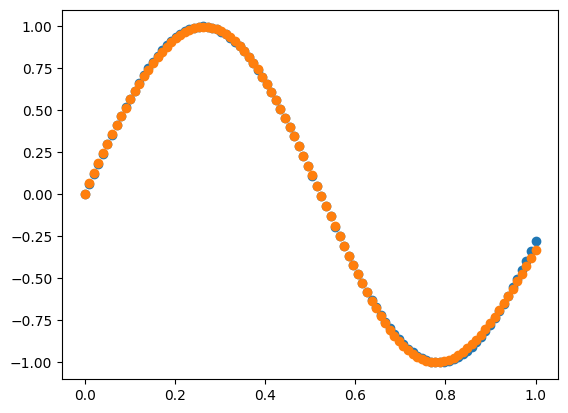

Epoch 7101 of 10000 (71.01%), Loss was 0.002125604205409344
Epoch 7102 of 10000 (71.02%), Loss was 0.0011544341967805736
Epoch 7103 of 10000 (71.03%), Loss was 0.0023173488685635977
Epoch 7104 of 10000 (71.04%), Loss was 0.0022359447590535662
Epoch 7105 of 10000 (71.05%), Loss was 0.0023975749195977625
Epoch 7106 of 10000 (71.06%), Loss was 0.0013652658809075653
Epoch 7107 of 10000 (71.07%), Loss was 0.004172268062942892
Epoch 7108 of 10000 (71.08%), Loss was 0.0013887489578964262
Epoch 7109 of 10000 (71.09%), Loss was 0.001151956741677913
Epoch 7110 of 10000 (71.1%), Loss was 0.005835777009951595
Epoch 7111 of 10000 (71.11%), Loss was 0.0018760647404556367
Epoch 7112 of 10000 (71.12%), Loss was 0.0036993091934854326
Epoch 7113 of 10000 (71.13%), Loss was 0.0017351956822960824
Epoch 7114 of 10000 (71.14%), Loss was 0.002283442361210991
Epoch 7115 of 10000 (71.15%), Loss was 0.0021214180477967183
Epoch 7116 of 10000 (71.16%), Loss was 0.0024945543618171083
Epoch 7117 of 10000 (71.17%), 

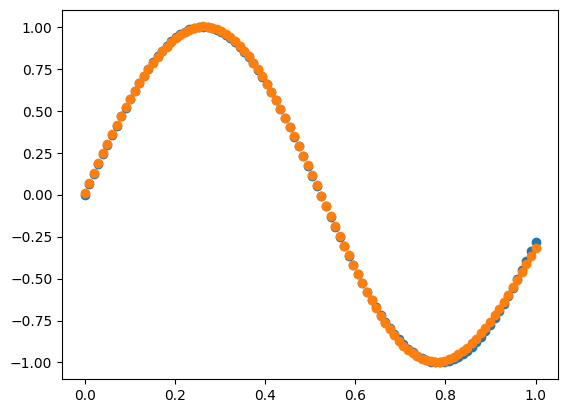

Epoch 7201 of 10000 (72.01%), Loss was 0.002323434614630624
Epoch 7202 of 10000 (72.02%), Loss was 0.003288179179699237
Epoch 7203 of 10000 (72.03%), Loss was 0.0020217544519447383
Epoch 7204 of 10000 (72.04%), Loss was 0.0013298214575412123
Epoch 7205 of 10000 (72.05%), Loss was 0.0013488307724897845
Epoch 7206 of 10000 (72.06%), Loss was 0.002439352400189741
Epoch 7207 of 10000 (72.07%), Loss was 0.002038601855093332
Epoch 7208 of 10000 (72.08%), Loss was 0.0013911509930719745
Epoch 7209 of 10000 (72.09%), Loss was 0.001674425737243157
Epoch 7210 of 10000 (72.1%), Loss was 0.002608065476770472
Epoch 7211 of 10000 (72.11%), Loss was 0.0019324289146527382
Epoch 7212 of 10000 (72.12%), Loss was 0.00301209132146467
Epoch 7213 of 10000 (72.13%), Loss was 0.001600377415964996
Epoch 7214 of 10000 (72.14%), Loss was 0.001736550811572558
Epoch 7215 of 10000 (72.15%), Loss was 0.0014386055160646863
Epoch 7216 of 10000 (72.16%), Loss was 0.0026005708981879333
Epoch 7217 of 10000 (72.17%), Loss 

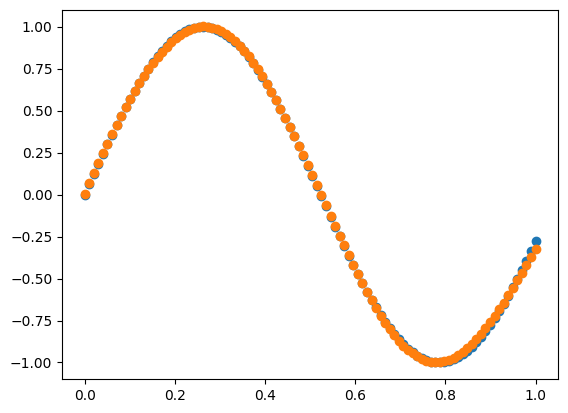

Epoch 7301 of 10000 (73.01%), Loss was 0.0021666430448492534
Epoch 7302 of 10000 (73.02%), Loss was 0.0010082353180441415
Epoch 7303 of 10000 (73.03%), Loss was 0.001442876525108134
Epoch 7304 of 10000 (73.04%), Loss was 0.0026471035634244916
Epoch 7305 of 10000 (73.05%), Loss was 0.0010587965951962398
Epoch 7306 of 10000 (73.06%), Loss was 0.002159279012851506
Epoch 7307 of 10000 (73.07%), Loss was 0.0007732972748839799
Epoch 7308 of 10000 (73.08%), Loss was 0.0028682750239115585
Epoch 7309 of 10000 (73.09%), Loss was 0.0011463507527740104
Epoch 7310 of 10000 (73.1%), Loss was 0.000984860452693993
Epoch 7311 of 10000 (73.11%), Loss was 0.000813148653050498
Epoch 7312 of 10000 (73.12%), Loss was 0.006786143264702181
Epoch 7313 of 10000 (73.13%), Loss was 0.002379755438613867
Epoch 7314 of 10000 (73.14%), Loss was 0.0041805630772366415
Epoch 7315 of 10000 (73.15%), Loss was 0.003070896138343914
Epoch 7316 of 10000 (73.16%), Loss was 0.003566073413740696
Epoch 7317 of 10000 (73.17%), Los

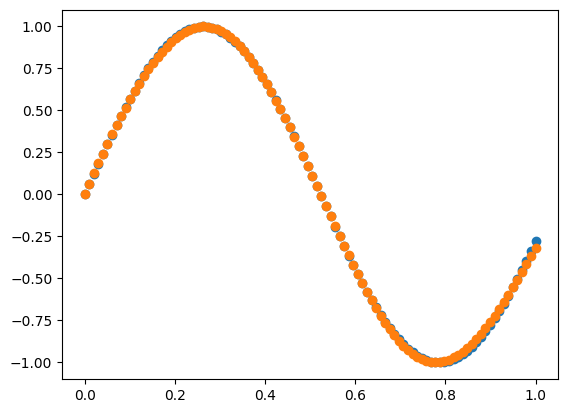

Epoch 7401 of 10000 (74.01%), Loss was 0.002020140180570089
Epoch 7402 of 10000 (74.02%), Loss was 0.0026135578491184044
Epoch 7403 of 10000 (74.03%), Loss was 0.0020751525035688665
Epoch 7404 of 10000 (74.04%), Loss was 0.0013772129301656915
Epoch 7405 of 10000 (74.05%), Loss was 0.0008791399785508901
Epoch 7406 of 10000 (74.06%), Loss was 0.001441288090934239
Epoch 7407 of 10000 (74.07%), Loss was 0.003978218993550839
Epoch 7408 of 10000 (74.08%), Loss was 0.0034260017614617445
Epoch 7409 of 10000 (74.09%), Loss was 0.0012062803102721575
Epoch 7410 of 10000 (74.1%), Loss was 0.002934501599893809
Epoch 7411 of 10000 (74.11%), Loss was 0.002788664036604071
Epoch 7412 of 10000 (74.12%), Loss was 0.0025951953402473856
Epoch 7413 of 10000 (74.13%), Loss was 0.0016691759441533269
Epoch 7414 of 10000 (74.14%), Loss was 0.0010948353755284457
Epoch 7415 of 10000 (74.15%), Loss was 0.0007028855656870568
Epoch 7416 of 10000 (74.16%), Loss was 0.005602024572506128
Epoch 7417 of 10000 (74.17%), L

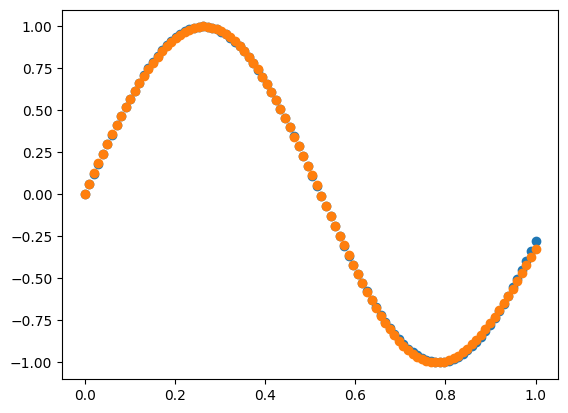

Epoch 7501 of 10000 (75.01%), Loss was 0.0028412250959354932
Epoch 7502 of 10000 (75.02%), Loss was 0.001055322971360981
Epoch 7503 of 10000 (75.03%), Loss was 0.00103177286630003
Epoch 7504 of 10000 (75.04%), Loss was 0.005683613697641685
Epoch 7505 of 10000 (75.05%), Loss was 0.0018392057013190317
Epoch 7506 of 10000 (75.06%), Loss was 0.0012269218442928853
Epoch 7507 of 10000 (75.07%), Loss was 0.001291199202396313
Epoch 7508 of 10000 (75.08%), Loss was 0.0011946481585857368
Epoch 7509 of 10000 (75.09%), Loss was 0.0021962864086308
Epoch 7510 of 10000 (75.1%), Loss was 0.0009493511118580358
Epoch 7511 of 10000 (75.11%), Loss was 0.003736858296827695
Epoch 7512 of 10000 (75.12%), Loss was 0.0007714701426901902
Epoch 7513 of 10000 (75.13%), Loss was 0.0030429846134009085
Epoch 7514 of 10000 (75.14%), Loss was 0.0017911553902649937
Epoch 7515 of 10000 (75.15%), Loss was 0.0021258718896266923
Epoch 7516 of 10000 (75.16%), Loss was 0.0018717885404065681
Epoch 7517 of 10000 (75.17%), Loss

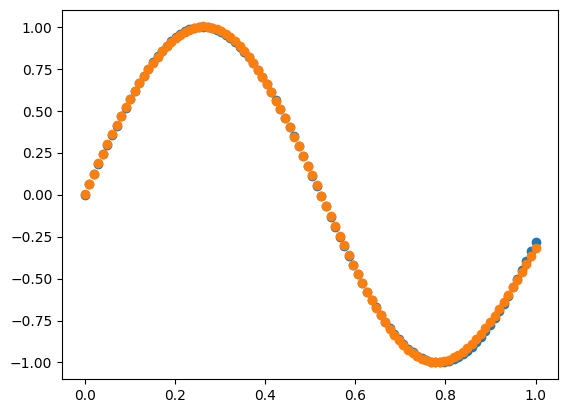

Epoch 7601 of 10000 (76.01%), Loss was 0.001299343059775018
Epoch 7602 of 10000 (76.02%), Loss was 0.000613637352170938
Epoch 7603 of 10000 (76.03%), Loss was 0.0033292570755274076
Epoch 7604 of 10000 (76.04%), Loss was 0.0036123660642143874
Epoch 7605 of 10000 (76.05%), Loss was 0.000892861737544798
Epoch 7606 of 10000 (76.06%), Loss was 0.001063701868045732
Epoch 7607 of 10000 (76.07%), Loss was 0.0018902050844313318
Epoch 7608 of 10000 (76.08%), Loss was 0.003293636941280006
Epoch 7609 of 10000 (76.09%), Loss was 0.0013451544038029302
Epoch 7610 of 10000 (76.1%), Loss was 0.001351119843231082
Epoch 7611 of 10000 (76.11%), Loss was 0.0009253164777479257
Epoch 7612 of 10000 (76.12%), Loss was 0.0012939430052817155
Epoch 7613 of 10000 (76.13%), Loss was 0.0012526571365054418
Epoch 7614 of 10000 (76.14%), Loss was 0.0009740640886941226
Epoch 7615 of 10000 (76.15%), Loss was 0.0009448089925616352
Epoch 7616 of 10000 (76.16%), Loss was 0.0018287179934735186
Epoch 7617 of 10000 (76.17%), L

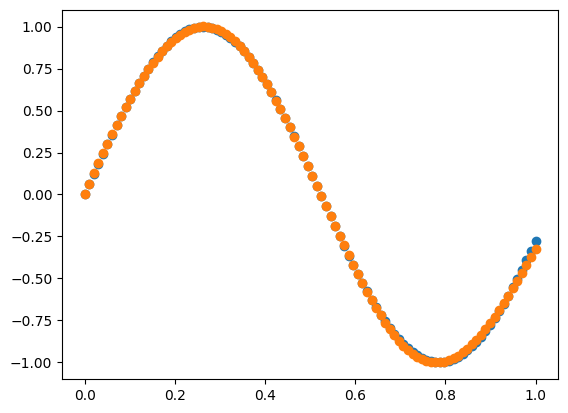

Epoch 7701 of 10000 (77.01%), Loss was 0.0011790973887599043
Epoch 7702 of 10000 (77.02%), Loss was 0.0008706290311102427
Epoch 7703 of 10000 (77.03%), Loss was 0.0015609327300858814
Epoch 7704 of 10000 (77.04%), Loss was 0.003861847626292835
Epoch 7705 of 10000 (77.05%), Loss was 0.001666863936144704
Epoch 7706 of 10000 (77.06%), Loss was 0.0018054448382983062
Epoch 7707 of 10000 (77.07%), Loss was 0.0016180997768464702
Epoch 7708 of 10000 (77.08%), Loss was 0.0018948512372468378
Epoch 7709 of 10000 (77.09%), Loss was 0.0005863300367728629
Epoch 7710 of 10000 (77.1%), Loss was 0.0008243929503050119
Epoch 7711 of 10000 (77.11%), Loss was 0.0014010581635776431
Epoch 7712 of 10000 (77.12%), Loss was 0.0010767271589569773
Epoch 7713 of 10000 (77.13%), Loss was 0.004926865922589182
Epoch 7714 of 10000 (77.14%), Loss was 0.0035703410706104132
Epoch 7715 of 10000 (77.15%), Loss was 0.001427569305030875
Epoch 7716 of 10000 (77.16%), Loss was 0.0008347331862276766
Epoch 7717 of 10000 (77.17%),

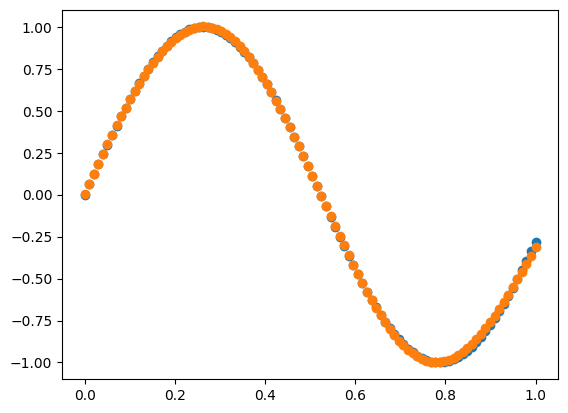

Epoch 7801 of 10000 (78.01%), Loss was 0.0018716500009676872
Epoch 7802 of 10000 (78.02%), Loss was 0.0007813640763113766
Epoch 7803 of 10000 (78.03%), Loss was 0.0015874084478248545
Epoch 7804 of 10000 (78.04%), Loss was 0.001388028481934142
Epoch 7805 of 10000 (78.05%), Loss was 0.0009365682675980392
Epoch 7806 of 10000 (78.06%), Loss was 0.0009044842518634463
Epoch 7807 of 10000 (78.07%), Loss was 0.0037757707132806575
Epoch 7808 of 10000 (78.08%), Loss was 0.002699297775629119
Epoch 7809 of 10000 (78.09%), Loss was 0.0024027343049984004
Epoch 7810 of 10000 (78.1%), Loss was 0.0009142876228846947
Epoch 7811 of 10000 (78.11%), Loss was 0.0019254925963612948
Epoch 7812 of 10000 (78.12%), Loss was 0.0026090220409515333
Epoch 7813 of 10000 (78.13%), Loss was 0.0010972100552888314
Epoch 7814 of 10000 (78.14%), Loss was 0.0015326081696675287
Epoch 7815 of 10000 (78.15%), Loss was 0.0025921009729911572
Epoch 7816 of 10000 (78.16%), Loss was 0.00046653136720680946
Epoch 7817 of 10000 (78.17

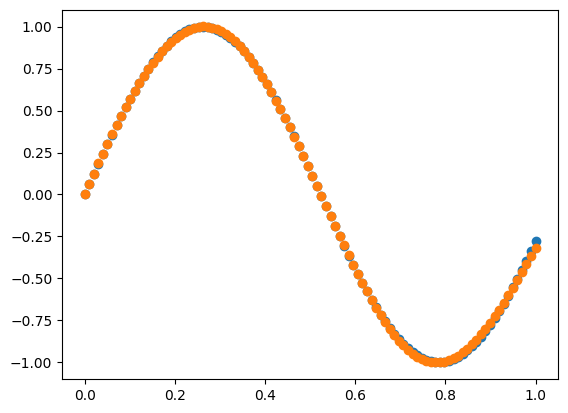

Epoch 7901 of 10000 (79.01%), Loss was 0.0012574375935054901
Epoch 7902 of 10000 (79.02%), Loss was 0.0011103769895388716
Epoch 7903 of 10000 (79.03%), Loss was 0.0011299852720559759
Epoch 7904 of 10000 (79.04%), Loss was 0.00053676903717457
Epoch 7905 of 10000 (79.05%), Loss was 0.001717237857506207
Epoch 7906 of 10000 (79.06%), Loss was 0.00098960319201897
Epoch 7907 of 10000 (79.07%), Loss was 0.0042296828178174095
Epoch 7908 of 10000 (79.08%), Loss was 0.001514467280001693
Epoch 7909 of 10000 (79.09%), Loss was 0.0006134995402909188
Epoch 7910 of 10000 (79.1%), Loss was 0.001479569698144803
Epoch 7911 of 10000 (79.11%), Loss was 0.001356278528268934
Epoch 7912 of 10000 (79.12%), Loss was 0.001475008499812979
Epoch 7913 of 10000 (79.13%), Loss was 0.002205496577510704
Epoch 7914 of 10000 (79.14%), Loss was 0.0010526575947138502
Epoch 7915 of 10000 (79.15%), Loss was 0.0024427630121820506
Epoch 7916 of 10000 (79.16%), Loss was 0.0016132417518999295
Epoch 7917 of 10000 (79.17%), Loss 

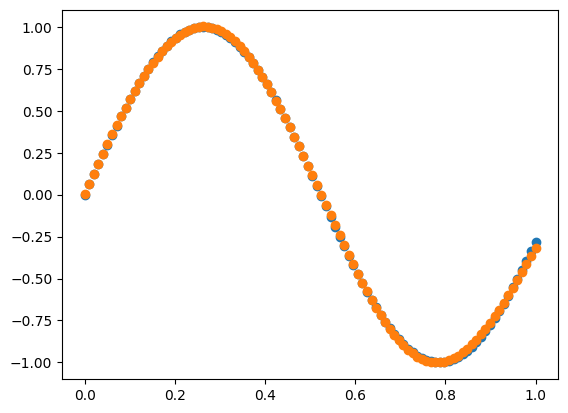

Epoch 8001 of 10000 (80.01%), Loss was 0.001354249914480759
Epoch 8002 of 10000 (80.02%), Loss was 0.000585995008466498
Epoch 8003 of 10000 (80.03%), Loss was 0.0018410454967287672
Epoch 8004 of 10000 (80.04%), Loss was 0.0007684783706057663
Epoch 8005 of 10000 (80.05%), Loss was 0.0018099817415126041
Epoch 8006 of 10000 (80.06%), Loss was 0.0010805012354001236
Epoch 8007 of 10000 (80.07%), Loss was 0.0015999445546794702
Epoch 8008 of 10000 (80.08%), Loss was 0.0015873476027030758
Epoch 8009 of 10000 (80.09%), Loss was 0.002473472022857552
Epoch 8010 of 10000 (80.1%), Loss was 0.000927720878570741
Epoch 8011 of 10000 (80.11%), Loss was 0.001988340623577691
Epoch 8012 of 10000 (80.12%), Loss was 0.0008650912818183515
Epoch 8013 of 10000 (80.13%), Loss was 0.00110082222805399
Epoch 8014 of 10000 (80.14%), Loss was 0.0019065566613244585
Epoch 8015 of 10000 (80.15%), Loss was 0.0010157258592648835
Epoch 8016 of 10000 (80.16%), Loss was 0.0024249452334287104
Epoch 8017 of 10000 (80.17%), Lo

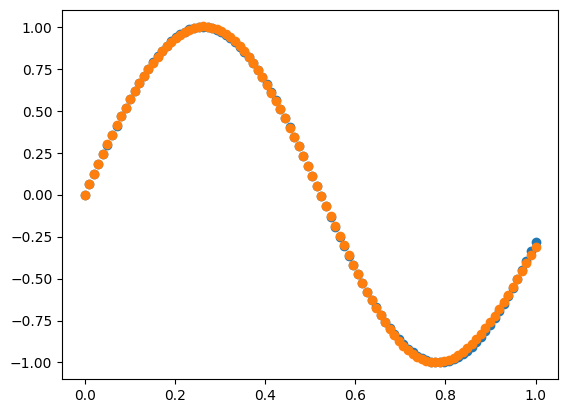

Epoch 8101 of 10000 (81.01%), Loss was 0.002296390830263217
Epoch 8102 of 10000 (81.02%), Loss was 0.0012128822430633275
Epoch 8103 of 10000 (81.03%), Loss was 0.0017394016991126636
Epoch 8104 of 10000 (81.04%), Loss was 0.0010852785670495784
Epoch 8105 of 10000 (81.05%), Loss was 0.00140360718123088
Epoch 8106 of 10000 (81.06%), Loss was 0.0009485372494024733
Epoch 8107 of 10000 (81.07%), Loss was 0.002440947140701584
Epoch 8108 of 10000 (81.08%), Loss was 0.0011975411308529455
Epoch 8109 of 10000 (81.09%), Loss was 0.0008297359118704899
Epoch 8110 of 10000 (81.1%), Loss was 0.000733376072215893
Epoch 8111 of 10000 (81.11%), Loss was 0.0006394735249923124
Epoch 8112 of 10000 (81.12%), Loss was 0.0013136890037996963
Epoch 8113 of 10000 (81.13%), Loss was 0.0020845115506750813
Epoch 8114 of 10000 (81.14%), Loss was 0.0012341268778449
Epoch 8115 of 10000 (81.15%), Loss was 0.0010083279855154148
Epoch 8116 of 10000 (81.16%), Loss was 0.0016301778663893912
Epoch 8117 of 10000 (81.17%), Los

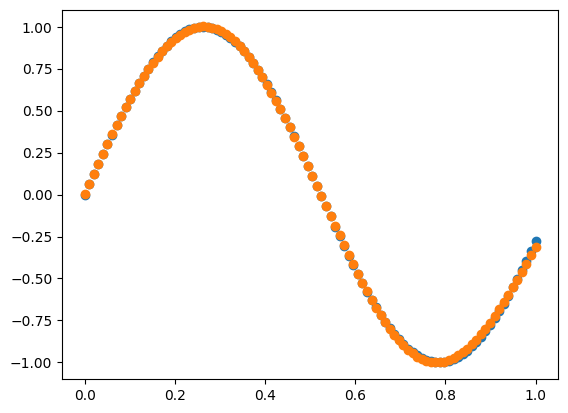

Epoch 8201 of 10000 (82.01%), Loss was 0.0019372681563427727
Epoch 8202 of 10000 (82.02%), Loss was 0.0006085130663607275
Epoch 8203 of 10000 (82.03%), Loss was 0.0008006179533048722
Epoch 8204 of 10000 (82.04%), Loss was 0.0005902963450809906
Epoch 8205 of 10000 (82.05%), Loss was 0.001898791129545396
Epoch 8206 of 10000 (82.06%), Loss was 0.001065318875833797
Epoch 8207 of 10000 (82.07%), Loss was 0.0008092728954432792
Epoch 8208 of 10000 (82.08%), Loss was 0.0013763249062854182
Epoch 8209 of 10000 (82.09%), Loss was 0.0018531531373594437
Epoch 8210 of 10000 (82.1%), Loss was 0.0011449414398211144
Epoch 8211 of 10000 (82.11%), Loss was 0.0021712716431907058
Epoch 8212 of 10000 (82.12%), Loss was 0.0008143238018106095
Epoch 8213 of 10000 (82.13%), Loss was 0.0007164540008301378
Epoch 8214 of 10000 (82.14%), Loss was 0.0009649911893706785
Epoch 8215 of 10000 (82.15%), Loss was 0.0012283618797893313
Epoch 8216 of 10000 (82.16%), Loss was 0.0017714102967153385
Epoch 8217 of 10000 (82.17%

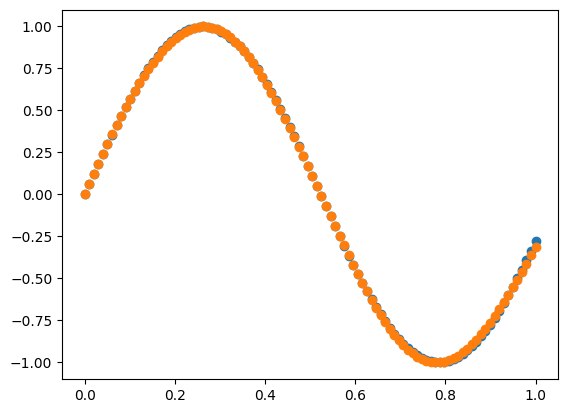

Epoch 8301 of 10000 (83.01%), Loss was 0.0009673188922415399
Epoch 8302 of 10000 (83.02%), Loss was 0.0017509760076199398
Epoch 8303 of 10000 (83.03%), Loss was 0.0005751033625083413
Epoch 8304 of 10000 (83.04%), Loss was 0.002806764509994071
Epoch 8305 of 10000 (83.05%), Loss was 0.0029099900735792003
Epoch 8306 of 10000 (83.06%), Loss was 0.0015504917373153834
Epoch 8307 of 10000 (83.07%), Loss was 0.002677656127929787
Epoch 8308 of 10000 (83.08%), Loss was 0.0014710135442599819
Epoch 8309 of 10000 (83.09%), Loss was 0.0012223702583696123
Epoch 8310 of 10000 (83.1%), Loss was 0.0009516344758699178
Epoch 8311 of 10000 (83.11%), Loss was 0.0006613446735154471
Epoch 8312 of 10000 (83.12%), Loss was 0.0010980632254664236
Epoch 8313 of 10000 (83.13%), Loss was 0.0008758332758698558
Epoch 8314 of 10000 (83.14%), Loss was 0.0005822056180014922
Epoch 8315 of 10000 (83.15%), Loss was 0.0022650217559678732
Epoch 8316 of 10000 (83.16%), Loss was 0.0014903942303073773
Epoch 8317 of 10000 (83.17%

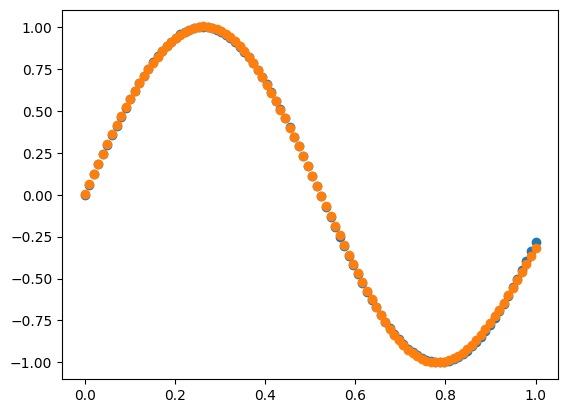

Epoch 8401 of 10000 (84.01%), Loss was 0.0010339104745327435
Epoch 8402 of 10000 (84.02%), Loss was 0.0007783103959007174
Epoch 8403 of 10000 (84.03%), Loss was 0.002166455776065931
Epoch 8404 of 10000 (84.04%), Loss was 0.0004911364445862996
Epoch 8405 of 10000 (84.05%), Loss was 0.00046916211912839423
Epoch 8406 of 10000 (84.06%), Loss was 0.0006591198475940219
Epoch 8407 of 10000 (84.07%), Loss was 0.000604987177391422
Epoch 8408 of 10000 (84.08%), Loss was 0.0008469440096289564
Epoch 8409 of 10000 (84.09%), Loss was 0.0012032043316524553
Epoch 8410 of 10000 (84.1%), Loss was 0.0014391502446795038
Epoch 8411 of 10000 (84.11%), Loss was 0.0016903674142338136
Epoch 8412 of 10000 (84.12%), Loss was 0.0009277453789278359
Epoch 8413 of 10000 (84.13%), Loss was 0.0020846977751981808
Epoch 8414 of 10000 (84.14%), Loss was 0.0011132425254096769
Epoch 8415 of 10000 (84.15%), Loss was 0.0019345511374824344
Epoch 8416 of 10000 (84.16%), Loss was 0.001315217044316153
Epoch 8417 of 10000 (84.17%

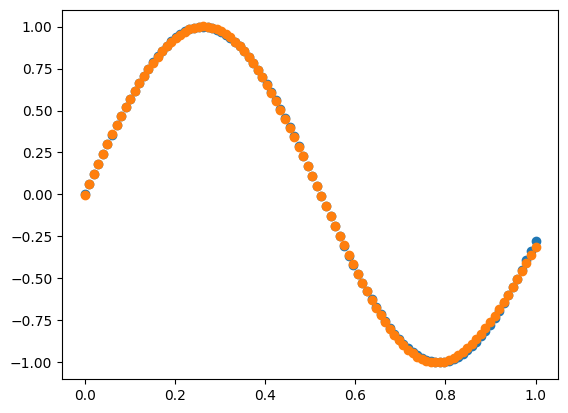

Epoch 8501 of 10000 (85.01%), Loss was 0.0010147081155928864
Epoch 8502 of 10000 (85.02%), Loss was 0.001469590368396677
Epoch 8503 of 10000 (85.03%), Loss was 0.0011736222083587283
Epoch 8504 of 10000 (85.04%), Loss was 0.000771192906077763
Epoch 8505 of 10000 (85.05%), Loss was 0.0020647589050622867
Epoch 8506 of 10000 (85.06%), Loss was 0.001123667483679658
Epoch 8507 of 10000 (85.07%), Loss was 0.0008388548781634291
Epoch 8508 of 10000 (85.08%), Loss was 0.0009395090985931874
Epoch 8509 of 10000 (85.09%), Loss was 0.00042282442652585644
Epoch 8510 of 10000 (85.1%), Loss was 0.000688011738173974
Epoch 8511 of 10000 (85.11%), Loss was 0.0007373227923466331
Epoch 8512 of 10000 (85.12%), Loss was 0.0018753570650766698
Epoch 8513 of 10000 (85.13%), Loss was 0.0014693328301802965
Epoch 8514 of 10000 (85.14%), Loss was 0.003328733442322189
Epoch 8515 of 10000 (85.15%), Loss was 0.0011053442758344764
Epoch 8516 of 10000 (85.16%), Loss was 0.0011181865550542445
Epoch 8517 of 10000 (85.17%),

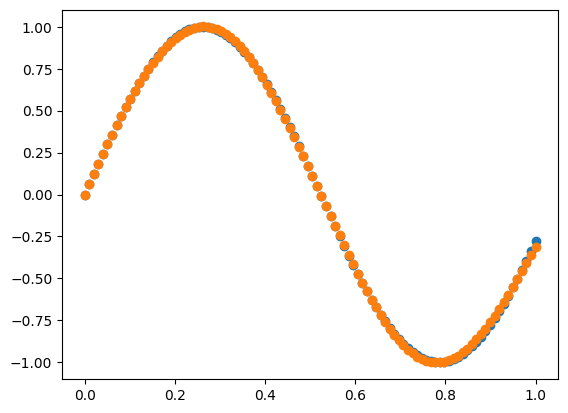

Epoch 8601 of 10000 (86.01%), Loss was 0.00205217597472641
Epoch 8602 of 10000 (86.02%), Loss was 0.0012385294192318347
Epoch 8603 of 10000 (86.03%), Loss was 0.0008862823965176118
Epoch 8604 of 10000 (86.04%), Loss was 0.0007236850895254985
Epoch 8605 of 10000 (86.05%), Loss was 0.000712410141497809
Epoch 8606 of 10000 (86.06%), Loss was 0.0020757690749668243
Epoch 8607 of 10000 (86.07%), Loss was 0.0009064100906505914
Epoch 8608 of 10000 (86.08%), Loss was 0.0006923494136536746
Epoch 8609 of 10000 (86.09%), Loss was 0.0019157472385190472
Epoch 8610 of 10000 (86.1%), Loss was 0.0012617909885199422
Epoch 8611 of 10000 (86.11%), Loss was 0.0012560234716820155
Epoch 8612 of 10000 (86.12%), Loss was 0.001066158514775488
Epoch 8613 of 10000 (86.13%), Loss was 0.001851151711278354
Epoch 8614 of 10000 (86.14%), Loss was 0.001758417923049651
Epoch 8615 of 10000 (86.15%), Loss was 0.0019409966976797637
Epoch 8616 of 10000 (86.16%), Loss was 0.0013804490526765994
Epoch 8617 of 10000 (86.17%), L

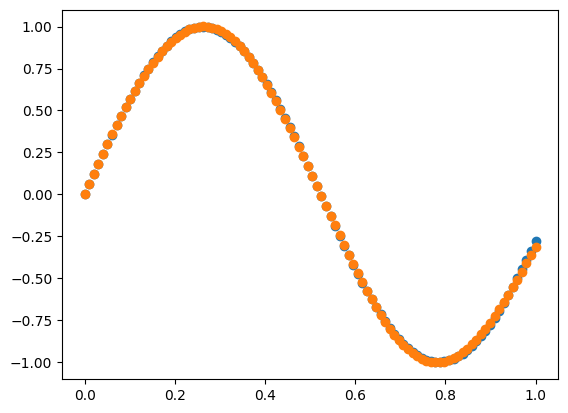

Epoch 8701 of 10000 (87.01%), Loss was 0.0008028951970882085
Epoch 8702 of 10000 (87.02%), Loss was 0.0004499084144072542
Epoch 8703 of 10000 (87.03%), Loss was 0.0004075720079235063
Epoch 8704 of 10000 (87.04%), Loss was 0.0006327095579588564
Epoch 8705 of 10000 (87.05%), Loss was 0.0004787957980594161
Epoch 8706 of 10000 (87.06%), Loss was 0.001740946078002596
Epoch 8707 of 10000 (87.07%), Loss was 0.000671632848874767
Epoch 8708 of 10000 (87.08%), Loss was 0.0007415542429205303
Epoch 8709 of 10000 (87.09%), Loss was 0.0024550262547503353
Epoch 8710 of 10000 (87.1%), Loss was 0.001598750645227316
Epoch 8711 of 10000 (87.11%), Loss was 0.0007093692378662115
Epoch 8712 of 10000 (87.12%), Loss was 0.0010708003495555492
Epoch 8713 of 10000 (87.13%), Loss was 0.0024021242666286717
Epoch 8714 of 10000 (87.14%), Loss was 0.0018194270102208612
Epoch 8715 of 10000 (87.15%), Loss was 0.0019163004809379745
Epoch 8716 of 10000 (87.16%), Loss was 0.0020269152210666075
Epoch 8717 of 10000 (87.17%)

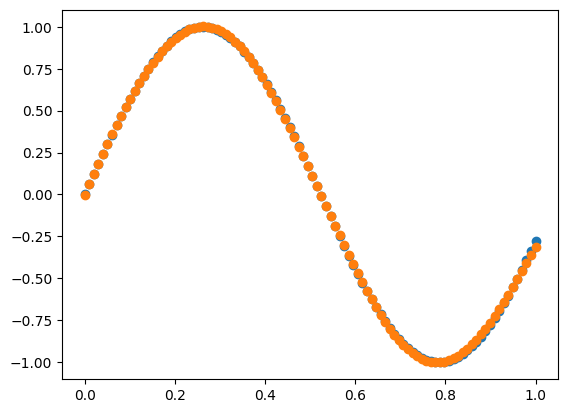

Epoch 8801 of 10000 (88.01%), Loss was 0.0008632402628478793
Epoch 8802 of 10000 (88.02%), Loss was 0.0012240403075367585
Epoch 8803 of 10000 (88.03%), Loss was 0.0019142252876895082
Epoch 8804 of 10000 (88.04%), Loss was 0.0008572667990043685
Epoch 8805 of 10000 (88.05%), Loss was 0.0006322171537471438
Epoch 8806 of 10000 (88.06%), Loss was 0.0013122076230995137
Epoch 8807 of 10000 (88.07%), Loss was 0.0015176594699584617
Epoch 8808 of 10000 (88.08%), Loss was 0.001126743098691714
Epoch 8809 of 10000 (88.09%), Loss was 0.0019246591558954643
Epoch 8810 of 10000 (88.1%), Loss was 0.0015366260689616603
Epoch 8811 of 10000 (88.11%), Loss was 0.0015770075037235573
Epoch 8812 of 10000 (88.12%), Loss was 0.0012699608776933391
Epoch 8813 of 10000 (88.13%), Loss was 0.0006540905726057698
Epoch 8814 of 10000 (88.14%), Loss was 0.0020261409485420896
Epoch 8815 of 10000 (88.15%), Loss was 0.0011627248918800097
Epoch 8816 of 10000 (88.16%), Loss was 0.0007332555021002933
Epoch 8817 of 10000 (88.17

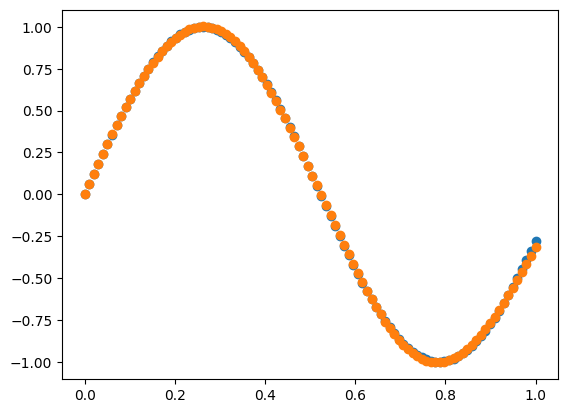

Epoch 8901 of 10000 (89.01%), Loss was 0.0005900492253969269
Epoch 8902 of 10000 (89.02%), Loss was 0.0008732595248018119
Epoch 8903 of 10000 (89.03%), Loss was 0.0017416757397888296
Epoch 8904 of 10000 (89.04%), Loss was 0.002796800181245345
Epoch 8905 of 10000 (89.05%), Loss was 0.0008503068198497264
Epoch 8906 of 10000 (89.06%), Loss was 0.0012108709714626978
Epoch 8907 of 10000 (89.07%), Loss was 0.00036150451102100894
Epoch 8908 of 10000 (89.08%), Loss was 0.00047306927733854016
Epoch 8909 of 10000 (89.09%), Loss was 0.001236946402343218
Epoch 8910 of 10000 (89.1%), Loss was 0.001362936268693387
Epoch 8911 of 10000 (89.11%), Loss was 0.00042966809680990576
Epoch 8912 of 10000 (89.12%), Loss was 0.0011984258088252153
Epoch 8913 of 10000 (89.13%), Loss was 0.0016645430327772131
Epoch 8914 of 10000 (89.14%), Loss was 0.001265463897526353
Epoch 8915 of 10000 (89.15%), Loss was 0.0007502274276229061
Epoch 8916 of 10000 (89.16%), Loss was 0.0017191391446587634
Epoch 8917 of 10000 (89.17

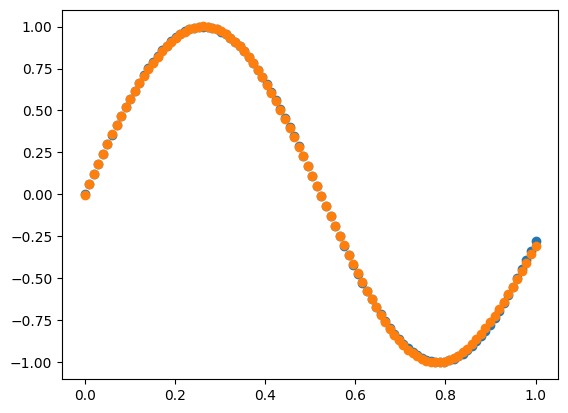

Epoch 9001 of 10000 (90.01%), Loss was 0.0015543369557165258
Epoch 9002 of 10000 (90.02%), Loss was 0.0007372095196002484
Epoch 9003 of 10000 (90.03%), Loss was 0.0010022707739928847
Epoch 9004 of 10000 (90.04%), Loss was 0.0011176442017643805
Epoch 9005 of 10000 (90.05%), Loss was 0.0011701485025154236
Epoch 9006 of 10000 (90.06%), Loss was 0.0012685307167891128
Epoch 9007 of 10000 (90.07%), Loss was 0.0008420055706659108
Epoch 9008 of 10000 (90.08%), Loss was 0.0007656007739409982
Epoch 9009 of 10000 (90.09%), Loss was 0.000740704369892626
Epoch 9010 of 10000 (90.1%), Loss was 0.0025286389428549627
Epoch 9011 of 10000 (90.11%), Loss was 0.0010049155951715079
Epoch 9012 of 10000 (90.12%), Loss was 0.0013063913364442761
Epoch 9013 of 10000 (90.13%), Loss was 0.0006541035601849679
Epoch 9014 of 10000 (90.14%), Loss was 0.0010693894682495878
Epoch 9015 of 10000 (90.15%), Loss was 0.0009548960304490328
Epoch 9016 of 10000 (90.16%), Loss was 0.0006480182825322711
Epoch 9017 of 10000 (90.17

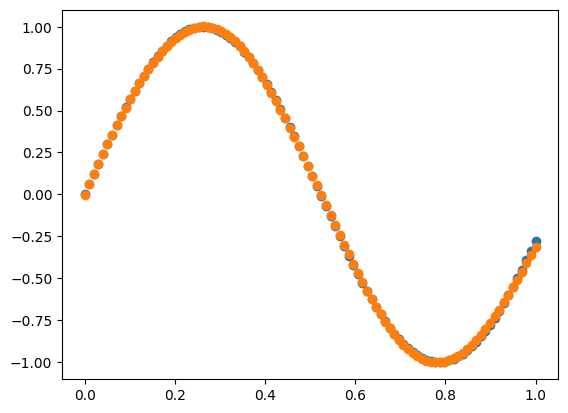

Epoch 9101 of 10000 (91.01%), Loss was 0.001277550867532501
Epoch 9102 of 10000 (91.02%), Loss was 0.0015244099416969927
Epoch 9103 of 10000 (91.03%), Loss was 0.001301654280058217
Epoch 9104 of 10000 (91.04%), Loss was 0.0006381914348826559
Epoch 9105 of 10000 (91.05%), Loss was 0.0007513254567340447
Epoch 9106 of 10000 (91.06%), Loss was 0.0007605615351509395
Epoch 9107 of 10000 (91.07%), Loss was 0.0009525902311483537
Epoch 9108 of 10000 (91.08%), Loss was 0.0005194289224151435
Epoch 9109 of 10000 (91.09%), Loss was 0.0019693734637481032
Epoch 9110 of 10000 (91.1%), Loss was 0.0008295373920600801
Epoch 9111 of 10000 (91.11%), Loss was 0.0005993052910807123
Epoch 9112 of 10000 (91.12%), Loss was 0.0004085814518579521
Epoch 9113 of 10000 (91.13%), Loss was 0.0011916155626277743
Epoch 9114 of 10000 (91.14%), Loss was 0.000965978101997884
Epoch 9115 of 10000 (91.15%), Loss was 0.002237162558608369
Epoch 9116 of 10000 (91.16%), Loss was 0.0010642363822988127
Epoch 9117 of 10000 (91.17%),

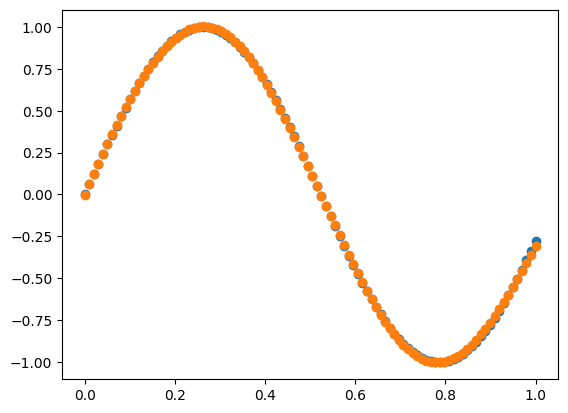

Epoch 9201 of 10000 (92.01%), Loss was 0.0006898099790703595
Epoch 9202 of 10000 (92.02%), Loss was 0.0010296000727502844
Epoch 9203 of 10000 (92.03%), Loss was 0.0020158778588522277
Epoch 9204 of 10000 (92.04%), Loss was 0.00048213880994465785
Epoch 9205 of 10000 (92.05%), Loss was 0.000701735934267032
Epoch 9206 of 10000 (92.06%), Loss was 0.002040753997222139
Epoch 9207 of 10000 (92.07%), Loss was 0.0009665463159904636
Epoch 9208 of 10000 (92.08%), Loss was 0.0005353158166655404
Epoch 9209 of 10000 (92.09%), Loss was 0.00202970210597311
Epoch 9210 of 10000 (92.1%), Loss was 0.0022158839659043713
Epoch 9211 of 10000 (92.11%), Loss was 0.0005370550116226352
Epoch 9212 of 10000 (92.12%), Loss was 0.0010949827452310307
Epoch 9213 of 10000 (92.13%), Loss was 0.0009180597377514382
Epoch 9214 of 10000 (92.14%), Loss was 0.0007902285332196383
Epoch 9215 of 10000 (92.15%), Loss was 0.0025217930408969816
Epoch 9216 of 10000 (92.16%), Loss was 0.0005356061128273118
Epoch 9217 of 10000 (92.17%)

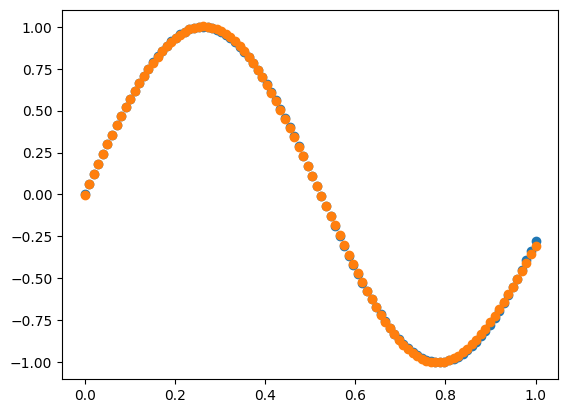

Epoch 9301 of 10000 (93.01%), Loss was 0.0011681588831114103
Epoch 9302 of 10000 (93.02%), Loss was 0.0013394341153360714
Epoch 9303 of 10000 (93.03%), Loss was 0.002605194459033561
Epoch 9304 of 10000 (93.04%), Loss was 0.0010279600396440533
Epoch 9305 of 10000 (93.05%), Loss was 0.0009381331044145729
Epoch 9306 of 10000 (93.06%), Loss was 0.0010495726375309169
Epoch 9307 of 10000 (93.07%), Loss was 0.0008640159927796727
Epoch 9308 of 10000 (93.08%), Loss was 0.000989532552100055
Epoch 9309 of 10000 (93.09%), Loss was 0.0016136912217456427
Epoch 9310 of 10000 (93.1%), Loss was 0.00143506449601844
Epoch 9311 of 10000 (93.11%), Loss was 0.0006539232594857141
Epoch 9312 of 10000 (93.12%), Loss was 0.0005651903151586789
Epoch 9313 of 10000 (93.13%), Loss was 0.0014563403829570196
Epoch 9314 of 10000 (93.14%), Loss was 0.000918773427276028
Epoch 9315 of 10000 (93.15%), Loss was 0.0025076094531768763
Epoch 9316 of 10000 (93.16%), Loss was 0.0014705847985541575
Epoch 9317 of 10000 (93.17%), 

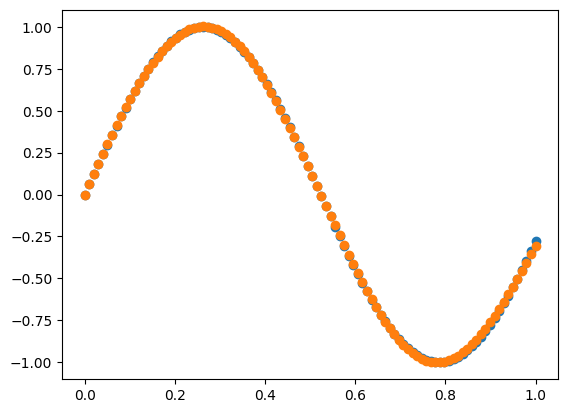

Epoch 9401 of 10000 (94.01%), Loss was 0.0009341411524494816
Epoch 9402 of 10000 (94.02%), Loss was 0.000800556762219614
Epoch 9403 of 10000 (94.03%), Loss was 0.0010708680846559637
Epoch 9404 of 10000 (94.04%), Loss was 0.0007831794847223425
Epoch 9405 of 10000 (94.05%), Loss was 0.0005931995748357158
Epoch 9406 of 10000 (94.06%), Loss was 0.0009574484835157493
Epoch 9407 of 10000 (94.07%), Loss was 0.0014014057254363075
Epoch 9408 of 10000 (94.08%), Loss was 0.0010284547211360463
Epoch 9409 of 10000 (94.09%), Loss was 0.0013203958352365679
Epoch 9410 of 10000 (94.1%), Loss was 0.0008174510722663922
Epoch 9411 of 10000 (94.11%), Loss was 0.0009474911931573334
Epoch 9412 of 10000 (94.12%), Loss was 0.0014097967301989211
Epoch 9413 of 10000 (94.13%), Loss was 0.0018037446833661101
Epoch 9414 of 10000 (94.14%), Loss was 0.0006611531931718376
Epoch 9415 of 10000 (94.15%), Loss was 0.0015892195711217233
Epoch 9416 of 10000 (94.16%), Loss was 0.0007221991928455987
Epoch 9417 of 10000 (94.17

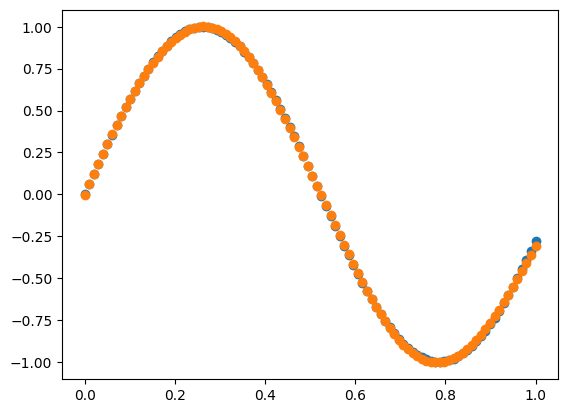

Epoch 9501 of 10000 (95.01%), Loss was 0.0012298445663065458
Epoch 9502 of 10000 (95.02%), Loss was 0.0015210795217933768
Epoch 9503 of 10000 (95.03%), Loss was 0.000577481654268131
Epoch 9504 of 10000 (95.04%), Loss was 0.0007946007190783804
Epoch 9505 of 10000 (95.05%), Loss was 0.000612837109049729
Epoch 9506 of 10000 (95.06%), Loss was 0.0009855301612903067
Epoch 9507 of 10000 (95.07%), Loss was 0.0007514919764418823
Epoch 9508 of 10000 (95.08%), Loss was 0.0008475212142833938
Epoch 9509 of 10000 (95.09%), Loss was 0.0017969771876694643
Epoch 9510 of 10000 (95.1%), Loss was 0.0007211149920424686
Epoch 9511 of 10000 (95.11%), Loss was 0.00041821682835500965
Epoch 9512 of 10000 (95.12%), Loss was 0.000628610868263231
Epoch 9513 of 10000 (95.13%), Loss was 0.0007437857881520623
Epoch 9514 of 10000 (95.14%), Loss was 0.00045395396085192927
Epoch 9515 of 10000 (95.15%), Loss was 0.0005984280924438064
Epoch 9516 of 10000 (95.16%), Loss was 0.000946129022404935
Epoch 9517 of 10000 (95.17%

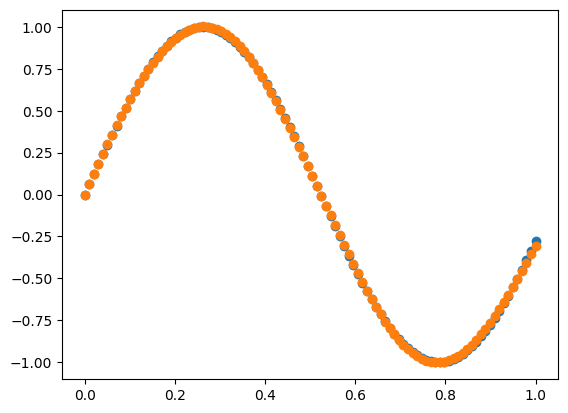

Epoch 9601 of 10000 (96.01%), Loss was 0.0010388939914096093
Epoch 9602 of 10000 (96.02%), Loss was 0.0009478534311671387
Epoch 9603 of 10000 (96.03%), Loss was 0.001129480973729238
Epoch 9604 of 10000 (96.04%), Loss was 0.0008693196734695633
Epoch 9605 of 10000 (96.05%), Loss was 0.0007284672862753469
Epoch 9606 of 10000 (96.06%), Loss was 0.0011093207929343684
Epoch 9607 of 10000 (96.07%), Loss was 0.0005880570398872233
Epoch 9608 of 10000 (96.08%), Loss was 0.0006147063687033665
Epoch 9609 of 10000 (96.09%), Loss was 0.0011063667213233022
Epoch 9610 of 10000 (96.1%), Loss was 0.0004803372893764376
Epoch 9611 of 10000 (96.11%), Loss was 0.001092246087830298
Epoch 9612 of 10000 (96.12%), Loss was 0.00046982455340882835
Epoch 9613 of 10000 (96.13%), Loss was 0.00037254195592544047
Epoch 9614 of 10000 (96.14%), Loss was 0.0016642387233196773
Epoch 9615 of 10000 (96.15%), Loss was 0.0009645856739869988
Epoch 9616 of 10000 (96.16%), Loss was 0.0012048901677009654
Epoch 9617 of 10000 (96.1

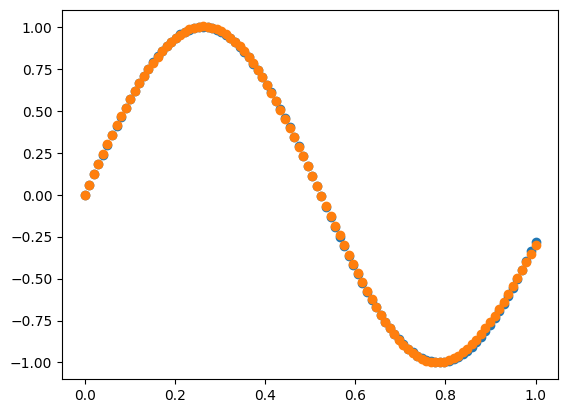

Epoch 9701 of 10000 (97.01%), Loss was 0.0012021284662236446
Epoch 9702 of 10000 (97.02%), Loss was 0.0007326342862867217
Epoch 9703 of 10000 (97.03%), Loss was 0.001127854915159633
Epoch 9704 of 10000 (97.04%), Loss was 0.0007080729450626769
Epoch 9705 of 10000 (97.05%), Loss was 0.0007439140446297448
Epoch 9706 of 10000 (97.06%), Loss was 0.00043039277530974407
Epoch 9707 of 10000 (97.07%), Loss was 0.0016820227998497665
Epoch 9708 of 10000 (97.08%), Loss was 0.0015773402371572073
Epoch 9709 of 10000 (97.09%), Loss was 0.0014604762372635032
Epoch 9710 of 10000 (97.1%), Loss was 0.0004003714892087271
Epoch 9711 of 10000 (97.11%), Loss was 0.002356118169028615
Epoch 9712 of 10000 (97.12%), Loss was 0.0011121562214215118
Epoch 9713 of 10000 (97.13%), Loss was 0.0007610206715083919
Epoch 9714 of 10000 (97.14%), Loss was 0.0010490136802531562
Epoch 9715 of 10000 (97.15%), Loss was 0.0007541877476435281
Epoch 9716 of 10000 (97.16%), Loss was 0.0008017169696575624
Epoch 9717 of 10000 (97.17

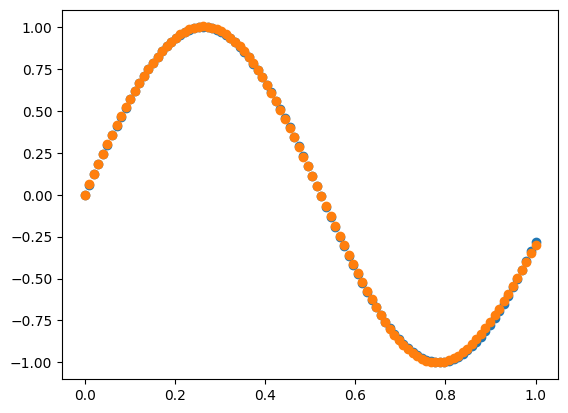

Epoch 9801 of 10000 (98.01%), Loss was 0.0017195957411428576
Epoch 9802 of 10000 (98.02%), Loss was 0.0007601592718960995
Epoch 9803 of 10000 (98.03%), Loss was 0.0010262935289272312
Epoch 9804 of 10000 (98.04%), Loss was 0.00044557438743313263
Epoch 9805 of 10000 (98.05%), Loss was 0.001174629807202296
Epoch 9806 of 10000 (98.06%), Loss was 0.0012390548082441223
Epoch 9807 of 10000 (98.07%), Loss was 0.0005811665332191031
Epoch 9808 of 10000 (98.08%), Loss was 0.0009392956899846793
Epoch 9809 of 10000 (98.09%), Loss was 0.00175421698262561
Epoch 9810 of 10000 (98.1%), Loss was 0.0007326641018243973
Epoch 9811 of 10000 (98.11%), Loss was 0.0009646669779422404
Epoch 9812 of 10000 (98.12%), Loss was 0.0008157422611147133
Epoch 9813 of 10000 (98.13%), Loss was 0.0009127268609561388
Epoch 9814 of 10000 (98.14%), Loss was 0.0010548009351470915
Epoch 9815 of 10000 (98.15%), Loss was 0.0008164563475024198
Epoch 9816 of 10000 (98.16%), Loss was 0.0015820177596234679
Epoch 9817 of 10000 (98.17%

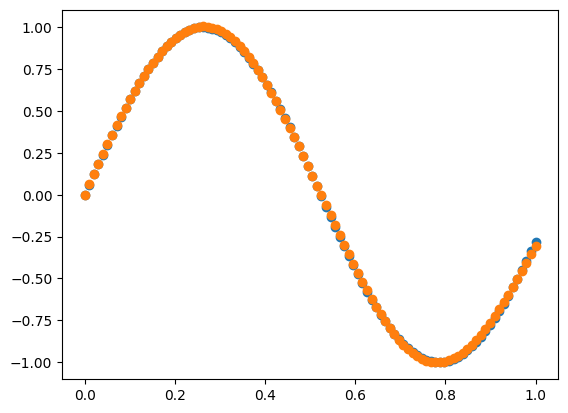

Epoch 9901 of 10000 (99.01%), Loss was 0.0007665545206177218
Epoch 9902 of 10000 (99.02%), Loss was 0.0010658118471102145
Epoch 9903 of 10000 (99.03%), Loss was 0.0011203496280568267
Epoch 9904 of 10000 (99.04%), Loss was 0.001099293301935211
Epoch 9905 of 10000 (99.05%), Loss was 0.0008282565104226611
Epoch 9906 of 10000 (99.06%), Loss was 0.0007302828549955701
Epoch 9907 of 10000 (99.07%), Loss was 0.0010127787513756683
Epoch 9908 of 10000 (99.08%), Loss was 0.0004271290103443941
Epoch 9909 of 10000 (99.09%), Loss was 0.0012973825268500297
Epoch 9910 of 10000 (99.1%), Loss was 0.0021246922350364674
Epoch 9911 of 10000 (99.11%), Loss was 0.001207206669140192
Epoch 9912 of 10000 (99.12%), Loss was 0.001108946032675203
Epoch 9913 of 10000 (99.13%), Loss was 0.001084346614250255
Epoch 9914 of 10000 (99.14%), Loss was 0.0009088741116800066
Epoch 9915 of 10000 (99.15%), Loss was 0.0006941734071676457
Epoch 9916 of 10000 (99.16%), Loss was 0.0007473545892953514
Epoch 9917 of 10000 (99.17%),

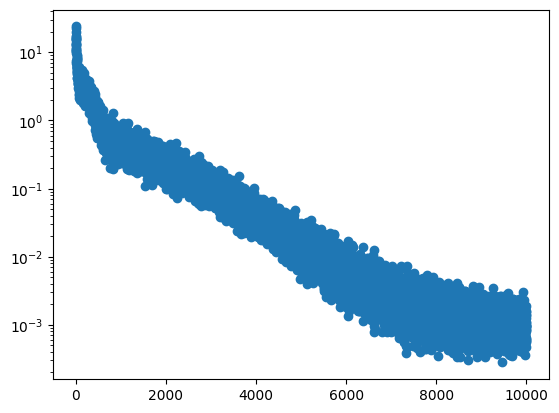

In [15]:
# We want to build a MLP to predict this funToPredict


def loss(batch_size: int) -> Value:

	batch_input = [random.uniform(0,1) for _ in range(batch_size)]
	# batch_input = np.linspace(0, 1, batch_size)
	true_outputs = [funToPredict(Value(sample_input)) for sample_input in batch_input]
	predicted_outputs = [mlp([Value(sample_input, op="INPUT")])[0] for sample_input in batch_input]

	loss = sum([(true_output-predicted_output) ** 2 for true_output, predicted_output in zip(true_outputs, predicted_outputs)], Value(0))
	return loss
	

epochs = 10000
batch_size = 30
# learning_rates = np.linspace(0.001, 0, epochs);
learning_rate = 0.001
losses = []
for epoch in range(epochs):
	l = loss(batch_size=batch_size)
	losses.append(l.data)
	mlp.zerograd()
	l.backwards()
	# graph_value(l)

	print(f"Epoch {epoch} of {epochs} ({epoch*100./epochs}%), Loss was {l.data}")
	# learning_rate = learning_rates[round];
	for p in mlp.parameters():
		p.data -= p.grad * learning_rate

	if epoch % 100 == 0:
		xs = np.linspace(0, 1, 100)
		predicted_ys=np.array([mlp([Value(x)])[0].data for x in xs])
		ys = np.array([funToPredict(Value(x)).data for x in xs])
		plt.scatter(xs, ys)
		plt.scatter(xs, predicted_ys)
		# plt.ylim(-5, 5)
		plt.show()




# xs = np.linspace(0, 1, 100)
# predicted_ys=np.array([mlp([Value(x)])[0].data for x in xs])
# ys = np.array([funToPredict(Value(x)).data for x in xs])
# plt.scatter(xs, ys)
# plt.scatter(xs, predicted_ys)
# plt.ylim(-5, 5)
# plt.show()

plt.scatter(np.linspace(1, epochs, epochs), losses)
plt.yscale('log')



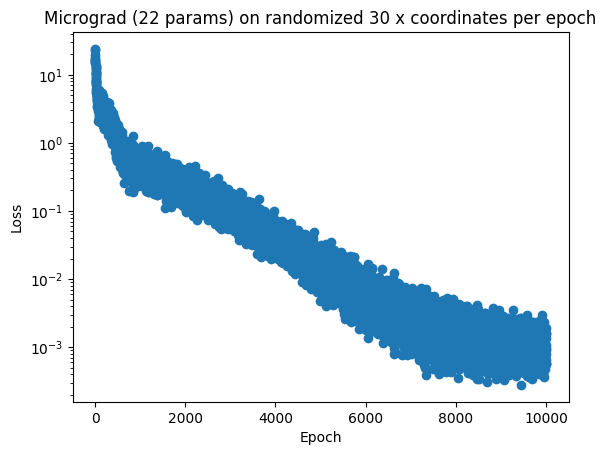

In [21]:
plt.scatter(np.linspace(1, epochs, epochs), losses)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Micrograd (22 params) on randomized 30 x coordinates per epoch')
plt.show()